# Import functions from library

In [1]:
import argparse
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import sys
import os
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from preprocessing import preprocess_signal
from lyapunov_code import get_foot_strike,get_average_stride_duration,average_mutual_information,optimal_lag,compute_fnn_percentage,optimal_embedding_dimension,compute_lyapunov_exponent

Make sure the cwd loaded

In [2]:
cwd = Path.cwd()
print("Current working directory:", cwd)

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation


In [3]:
results_df = pd.DataFrame(columns=['subject', 'axis','average stride duration', 'measuring time (s)','PBT', 'lag', 'embedding_dimension','fnn_threshold', 'lyapunov_exponent'])

# Quantifying stability with Short Term Lyapunov

## Lyapunov on patient 13

In [4]:
file_path_Y13 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_13" /"Pre.3"/ "markers.nc"
events_path_Y13 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_13" /"Pre"/ "events.nc"
markers_Y13= xr.open_dataarray(file_path_Y13)
com_Y13= markers_Y13.sel(channel="COM")
# %matplotlib widget


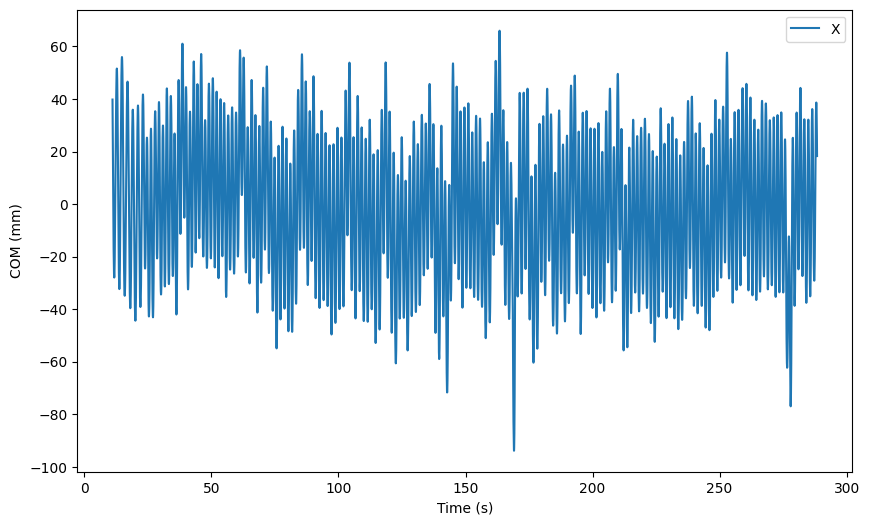

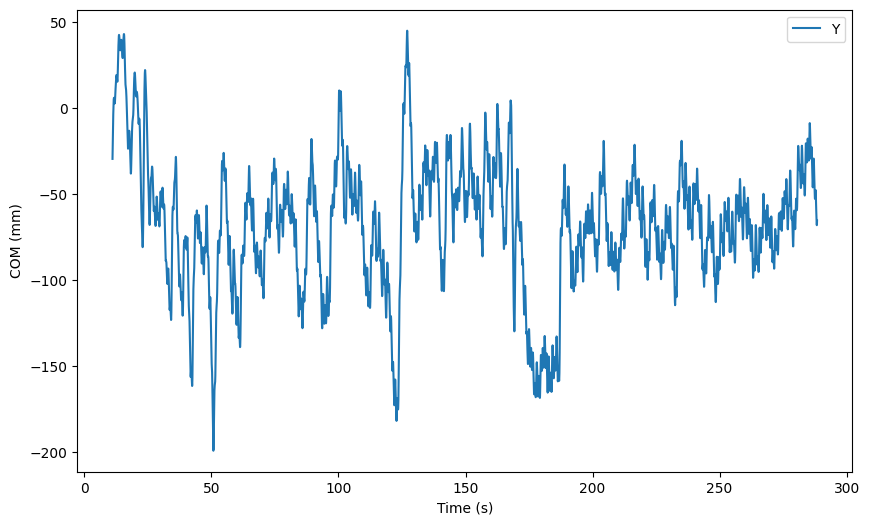

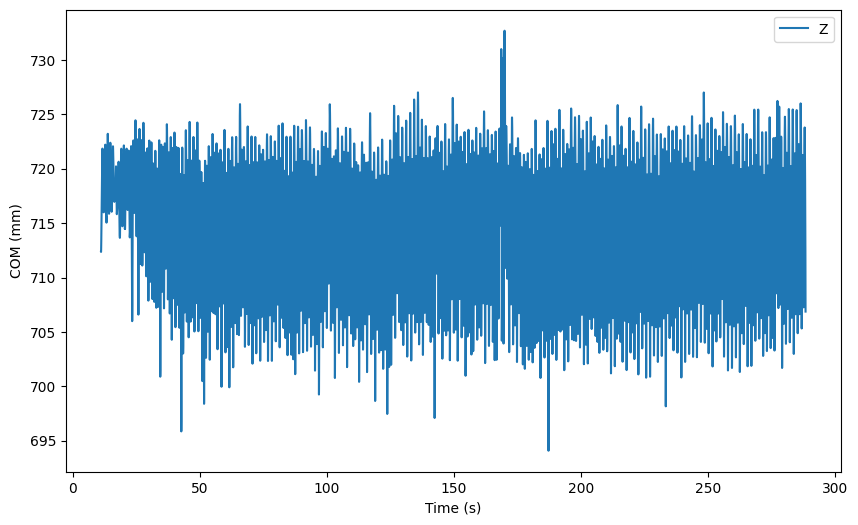

In [5]:
time = com_Y13.coords["time"].values      
x_Y13    = com_Y13.sel(axis="x").values       
y_Y13   = com_Y13.sel(axis="y").values
z_Y13    = com_Y13.sel(axis="z").values

fig = plt.figure(figsize=(10, 6))       
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x_Y13, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y_Y13, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z_Y13, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

### Short term Lyapunov Pre Perturbation

Time coordinates: 11.08 to 288.34999999999997
Selected COM shape: 20.36 119.66 (3, 9931)
Average stride duration: 1.5515625 ± 0.07213742852188458 s

--- Axis: x ---


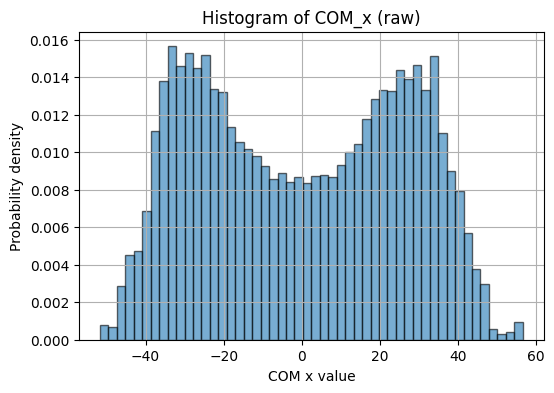

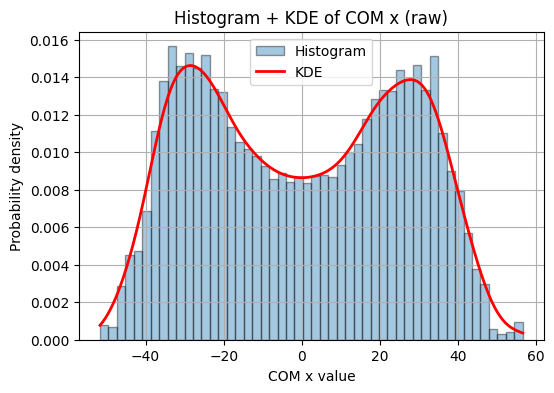

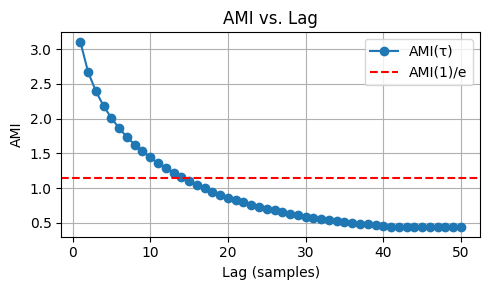

Optimal lag (τ) for axis x: 15 samples (0.150 s)


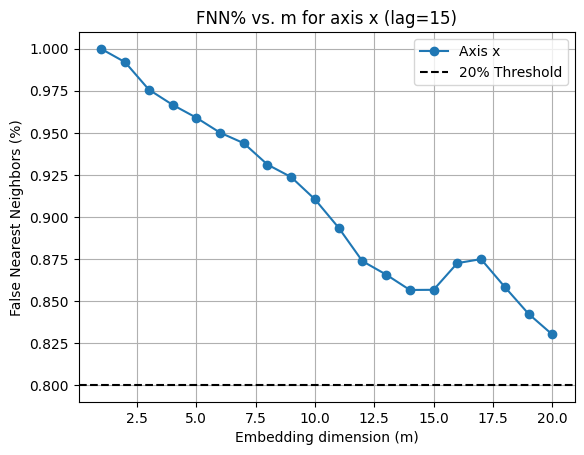

Optimal embedding dimension (m) for axis x: 17


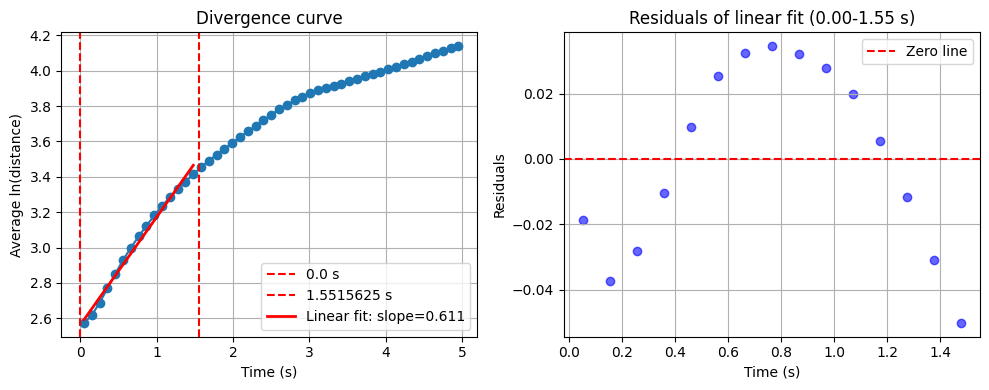

Lyapunov exponent (λ*) for axis x: 0.6106 1/s
         subject axis  average stride duration  measuring time (s)     PBT  \
0  Cereneo_SR_13    x                 1.551562                99.3  Before   

   lag  embedding_dimension  fnn_threshold  lyapunov_exponent  
0   15                   17            0.8           0.610576  

--- Axis: z ---


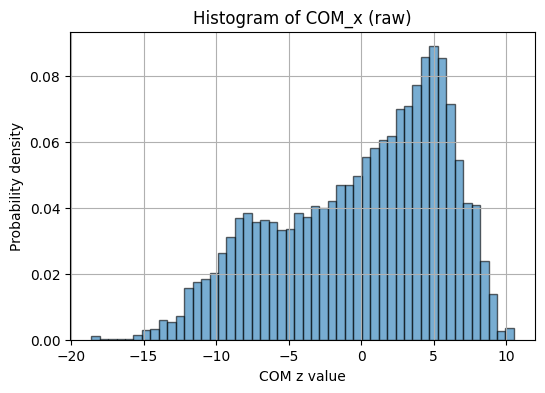

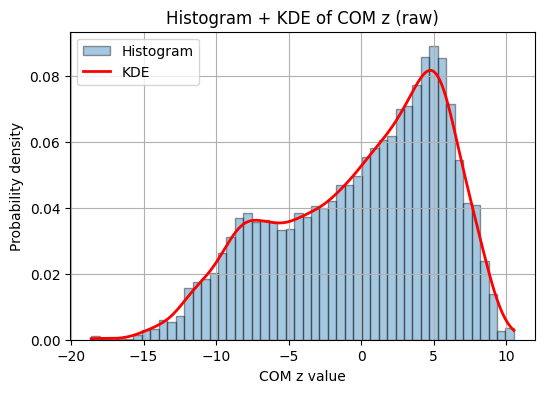

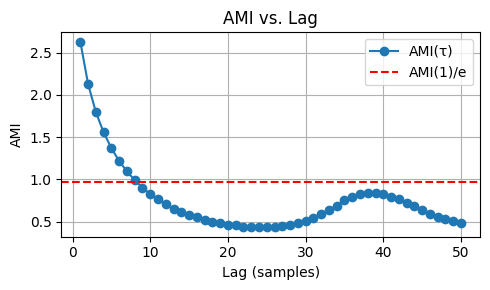

Optimal lag (τ) for axis z: 9 samples (0.090 s)


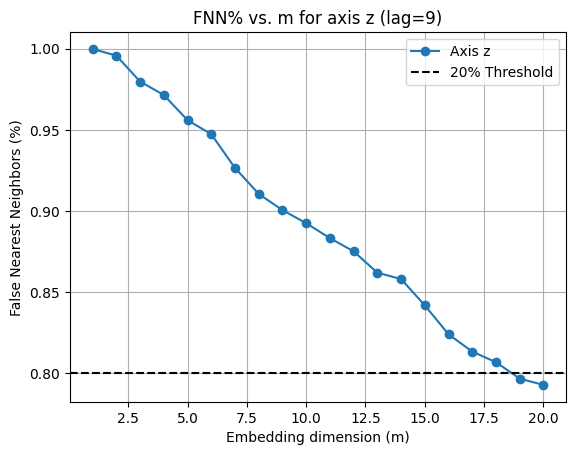

Optimal embedding dimension (m) for axis z: 14


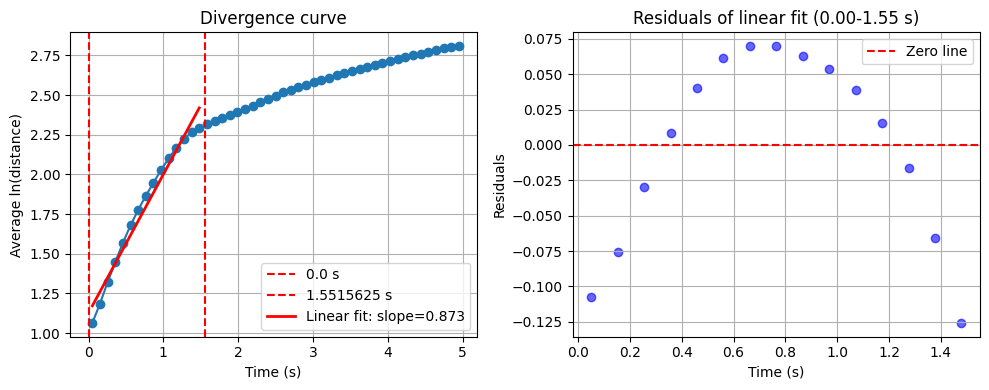

Lyapunov exponent (λ*) for axis z: 0.8728 1/s
         subject axis  average stride duration  measuring time (s)     PBT  \
0  Cereneo_SR_13    x                 1.551562                99.3  Before   
1  Cereneo_SR_13    z                 1.551562                99.3  Before   

   lag  embedding_dimension  fnn_threshold  lyapunov_exponent  
0   15                   17            0.8           0.610576  
1    9                   14            0.8           0.872766  


In [6]:
ds_Y13 = xr.open_dataset(file_path_Y13)
da_Y13 = ds_Y13["markers"] if "markers" in ds_Y13 else ds_Y13
com_Y13 = da_Y13.sel(channel="COM")
time = com_Y13.coords["time"].values  
print("Time coordinates:", time[0], "to", time[-1])
fstrike_time_Y13 = get_foot_strike(events_path_Y13, foot='Right', start_time=20.0, end_time=120.0)
start_time_Y13 = fstrike_time_Y13['first_strike']
end_time_Y13 = fstrike_time_Y13['last_strike']
com_Y13 = com_Y13.sel(time=slice(start_time_Y13, end_time_Y13))  
print("Selected COM shape:", start_time_Y13, end_time_Y13, com_Y13.shape)
average_stride = get_average_stride_duration(events_path_Y13, foot='Right', start_time=20.0, end_time=120.0)
print("Average stride duration:", average_stride['mean_duration'], "±", average_stride['std_duration'], "s")

max_lag_Y13 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y13 = 20        # Search FNN% up to 20 dimensions
rtol = 0.10
fnn_threshold = 0.80
fs = 100.0
max_time_Y13 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y13 = com_Y13.sel(axis=axis).values.ravel()
    ts_Y13 = preprocess_signal(ts_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)


    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y13, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y13)            
    xs_Y13 = np.linspace(ts_Y13.min(), ts_Y13.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y13, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y13, kde(xs_Y13), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y13 = optimal_lag(ts_Y13, max_lag=max_lag_Y13, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y13} samples ({lag_Y13/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y13, fnn_perc_Y13 = compute_fnn_percentage(ts_Y13, lag_Y13, max_dim=max_dim_Y13, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y13, fnn_perc_Y13, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y13})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y13 = optimal_embedding_dimension(
        ts_Y13, lag_Y13, max_dim=max_dim_Y13, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y13}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y13 = compute_lyapunov_exponent(
        ts_Y13, emb_dim=dim_Y13, lag=lag_Y13, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y13:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_13',
    'axis': axis,
    'average stride duration': average_stride['mean_duration'],
    'measuring time (s)': end_time_Y13 - start_time_Y13,
    'PBT': 'Before',
    'lag': lag_Y13,
    'embedding_dimension': dim_Y13,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y13}
    print (results_df)



post perturbation

Selected COM shape: 135.39 282.85 (3, 14747)
Average stride duration: 1.5202061855670106 ± 0.0887830598386654 s

--- Axis: x ---


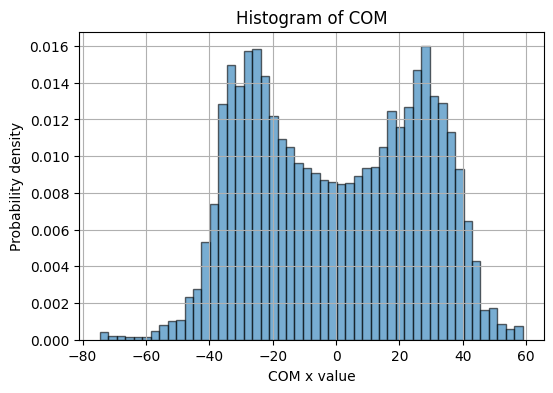

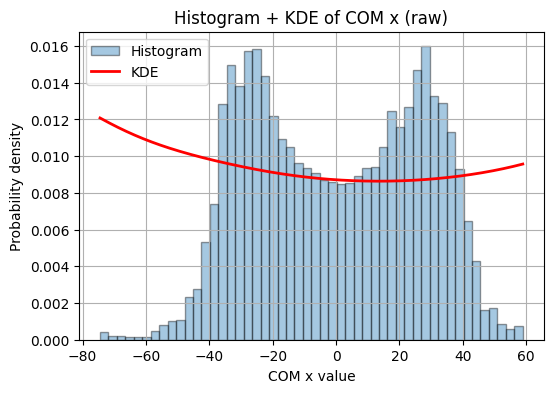

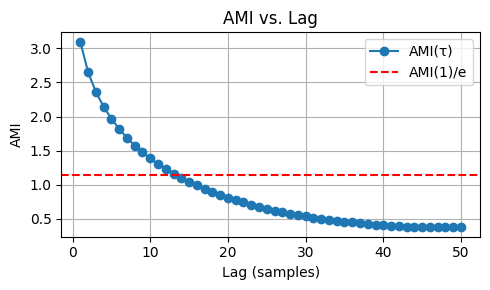

Optimal lag (τ) for axis x: 14 samples (0.140 s)


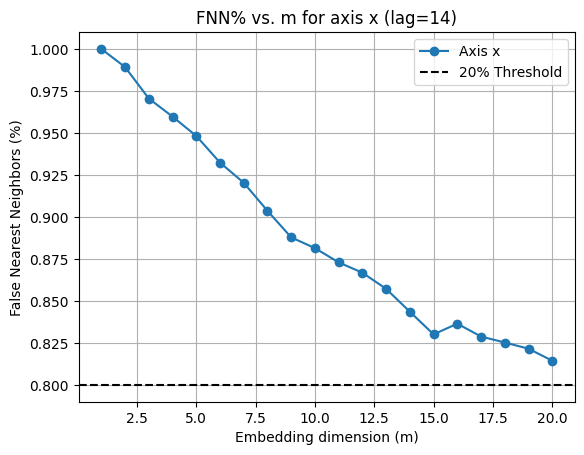

Optimal embedding dimension (m) for axis x: 15


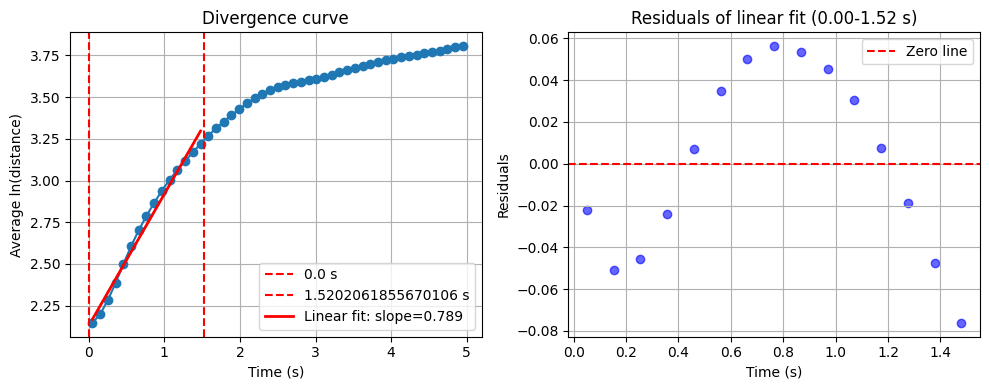

Lyapunov exponent (λ*) for axis x: 0.7893 1/s
         subject axis  average stride duration  measuring time (s)     PBT  \
0  Cereneo_SR_13    x                 1.551562               99.30  Before   
1  Cereneo_SR_13    z                 1.551562               99.30  Before   
2  Cereneo_SR_13    x                 1.520206              147.46   After   

   lag  embedding_dimension  fnn_threshold  lyapunov_exponent  
0   15                   17            0.8           0.610576  
1    9                   14            0.8           0.872766  
2   14                   15            0.8           0.789337  

--- Axis: z ---


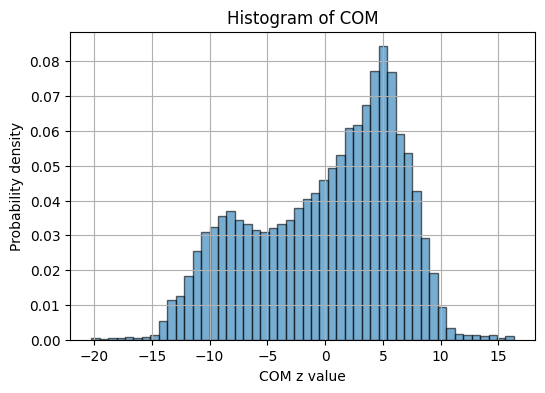

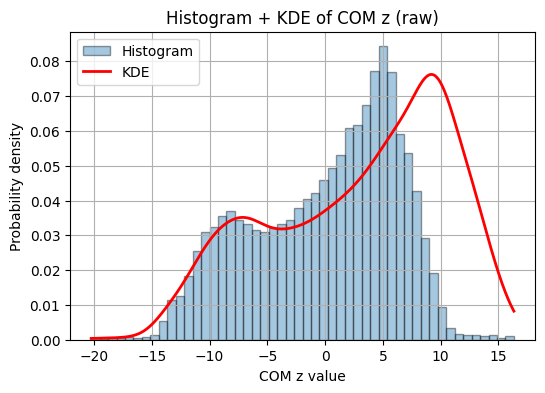

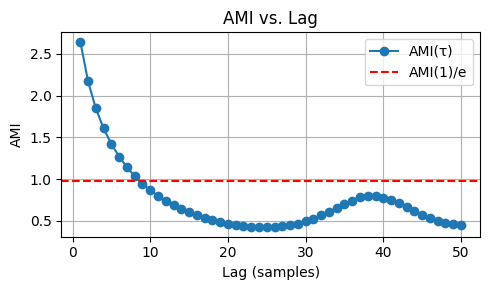

Optimal lag (τ) for axis z: 9 samples (0.090 s)


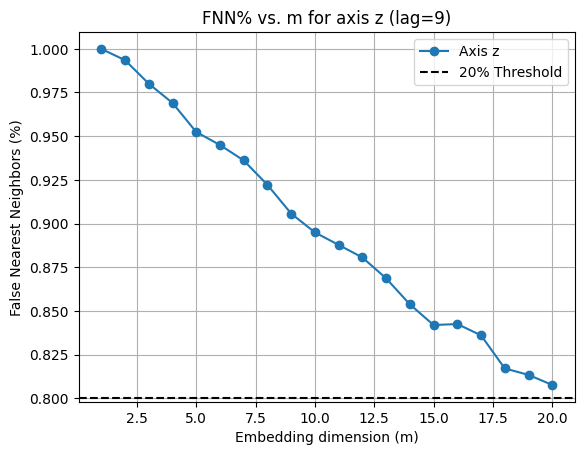

Optimal embedding dimension (m) for axis z: 18


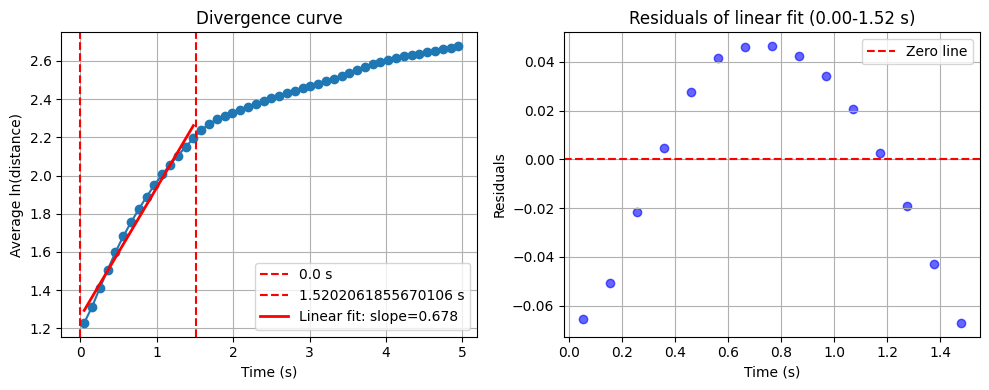

Lyapunov exponent (λ*) for axis z: 0.6777 1/s
         subject axis  average stride duration  measuring time (s)     PBT  \
0  Cereneo_SR_13    x                 1.551562               99.30  Before   
1  Cereneo_SR_13    z                 1.551562               99.30  Before   
2  Cereneo_SR_13    x                 1.520206              147.46   After   
3  Cereneo_SR_13    z                 1.520206              147.46   After   

   lag  embedding_dimension  fnn_threshold  lyapunov_exponent  
0   15                   17            0.8           0.610576  
1    9                   14            0.8           0.872766  
2   14                   15            0.8           0.789337  
3    9                   18            0.8           0.677714  


In [8]:
ds_Y13P = xr.open_dataset(file_path_Y13)
da_Y13P = ds_Y13P["markers"] if "markers" in ds_Y13P else ds_Y13P
com_Y13P = da_Y13.sel(channel="COM")
time = com_Y13P.coords["time"].values  
da_Y13P = ds_Y13P["markers"] if "markers" in ds_Y13P else ds_Y13P 
fstrike_time_Y13P = get_foot_strike(events_path_Y13, foot='Right', start_time=135.0, end_time=time[-1]-5.0)
start_time_Y13P = fstrike_time_Y13P['first_strike']
end_time_Y13P = fstrike_time_Y13P['last_strike']
com_Y13P = com_Y13P.sel(time=slice(start_time_Y13P, end_time_Y13P))  
print("Selected COM shape:", start_time_Y13P, end_time_Y13P, com_Y13P.shape)
average_stride_Y13P = get_average_stride_duration(events_path_Y13, foot='Right', start_time=135.0, end_time=time[-1]-5.0)
print("Average stride duration:", average_stride_Y13P['mean_duration'], "±", average_stride_Y13P['std_duration'], "s")

max_lag_Y13 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y13 = 20        # Search FNN% up to 20 dimensions
rtol = 0.10
fnn_threshold = 0.80
fs = 100.0
max_time_Y13 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y13P = com_Y13P.sel(axis=axis).values.ravel()
    ts_Y13P = preprocess_signal(ts_Y13P, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y13P, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y13P)            
    xs_Y13P = np.linspace(ts_Y13P.min(), ts_Y13P.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y13P, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y13P, kde(xs_Y13), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y13P = optimal_lag(ts_Y13P, max_lag=max_lag_Y13, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y13P} samples ({lag_Y13P/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y13P, fnn_perc_Y13P = compute_fnn_percentage(ts_Y13P, lag_Y13P, max_dim=max_dim_Y13, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y13P, fnn_perc_Y13P, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y13P})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y13P = optimal_embedding_dimension(
        ts_Y13P, lag_Y13P, max_dim=max_dim_Y13, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y13P}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y13P = compute_lyapunov_exponent(
        ts_Y13P, emb_dim=dim_Y13P, lag=lag_Y13P, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y13P['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y13P:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_13',
    'axis': axis,
    'average stride duration': average_stride_Y13P['mean_duration'],
    'measuring time (s)': end_time_Y13P - start_time_Y13P,
    'PBT': 'After',
    'lag': lag_Y13P,
    'embedding_dimension': dim_Y13P,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y13P}
    print (results_df)



# Lyapunov patient 14

Visualize shortly to examine the perturbation

In [9]:
file_path_Y14 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_14" /"Pre.3"/ "markers.nc"
events_path_Y14 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_14" /"Pre.4"/ "events.nc"
markers_Y14= xr.open_dataarray(file_path_Y14)
com_Y14= markers_Y14.sel(channel="COM")
# %matplotlib widget


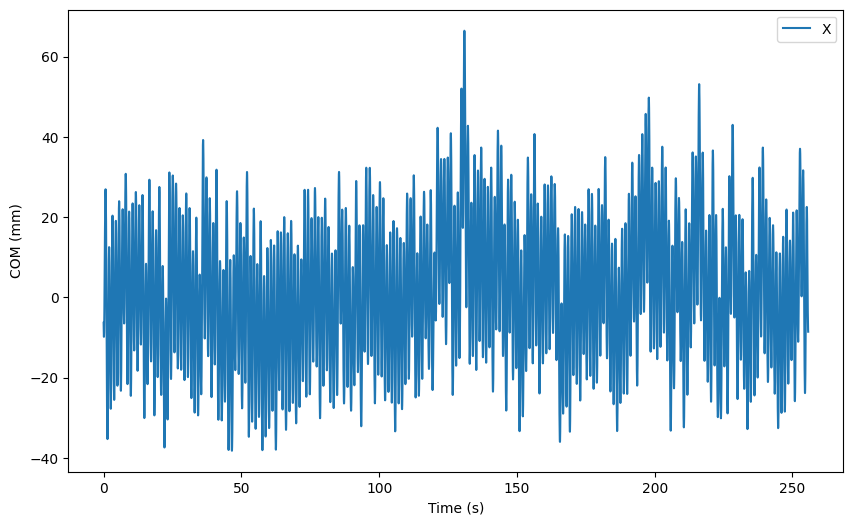

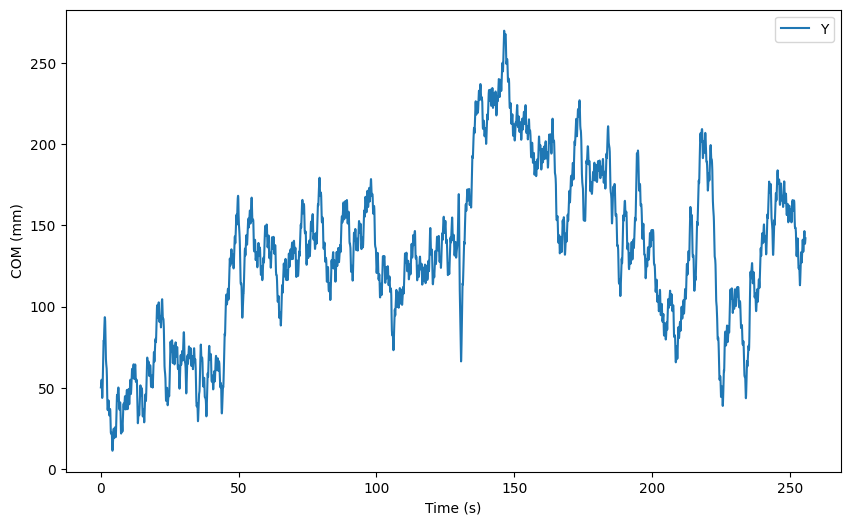

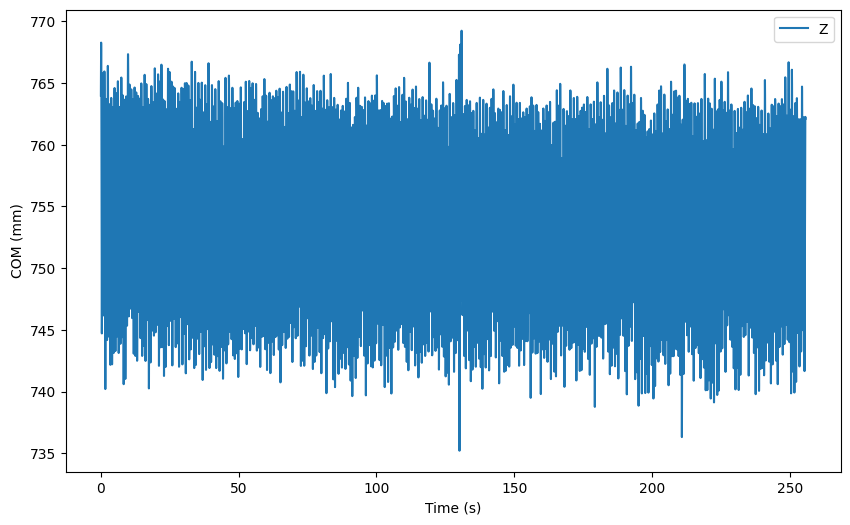

In [10]:
time = com_Y14.coords["time"].values      
x_Y14    = com_Y14.sel(axis="x").values       
y_Y14   = com_Y14.sel(axis="y").values
z_Y14    = com_Y14.sel(axis="z").values

fig = plt.figure(figsize=(10, 6))       
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x_Y14, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y_Y14, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z_Y14, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

pre perturbation

Time coordinates: 0.0 to 255.72
Selected COM shape: 20.44 118.9 (3, 9847)
Average stride duration: 1.23075 ± 0.02090305001668503 s

--- Axis: x ---


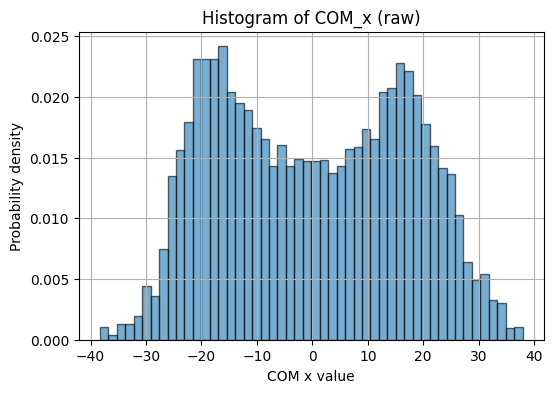

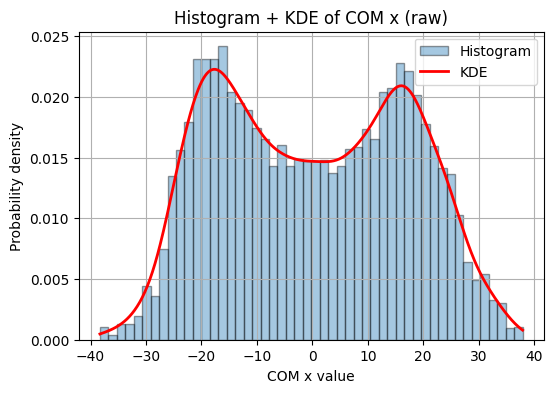

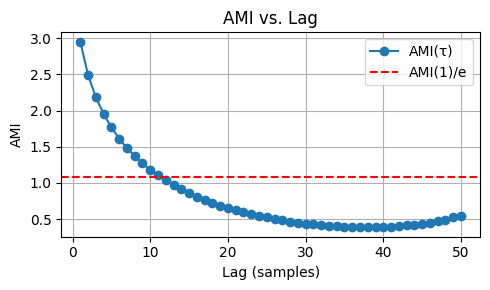

Optimal lag (τ) for axis x: 12 samples (0.120 s)


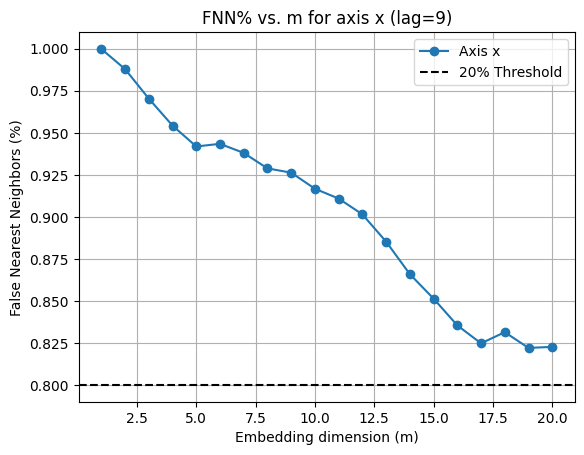

Optimal embedding dimension (m) for axis x: 17


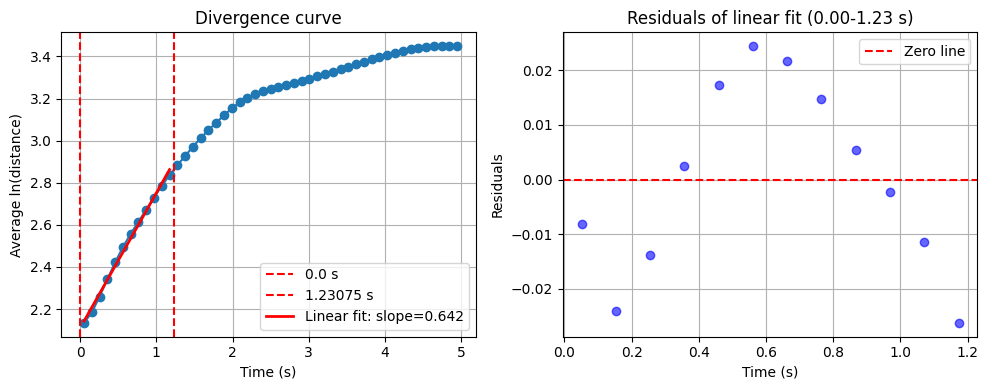

Lyapunov exponent (λ*) for axis x: 0.6415 1/s
         subject axis  average stride duration  measuring time (s)     PBT  \
0  Cereneo_SR_13    x                 1.551562               99.30  Before   
1  Cereneo_SR_13    z                 1.551562               99.30  Before   
2  Cereneo_SR_13    x                 1.520206              147.46   After   
3  Cereneo_SR_13    z                 1.520206              147.46   After   
4  Cereneo_SR_14    x                 1.230750               98.46  Before   

   lag  embedding_dimension  fnn_threshold  lyapunov_exponent  
0   15                   17            0.8           0.610576  
1    9                   14            0.8           0.872766  
2   14                   15            0.8           0.789337  
3    9                   18            0.8           0.677714  
4   12                   17            0.8           0.641521  

--- Axis: z ---


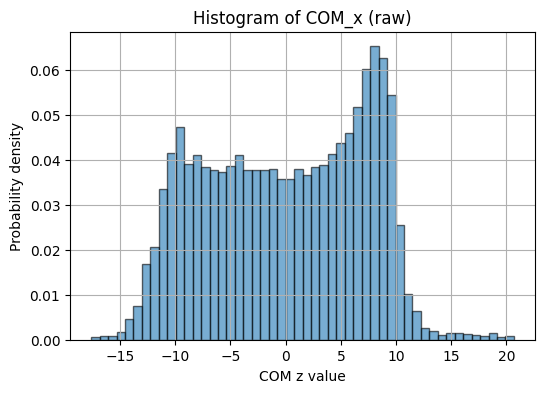

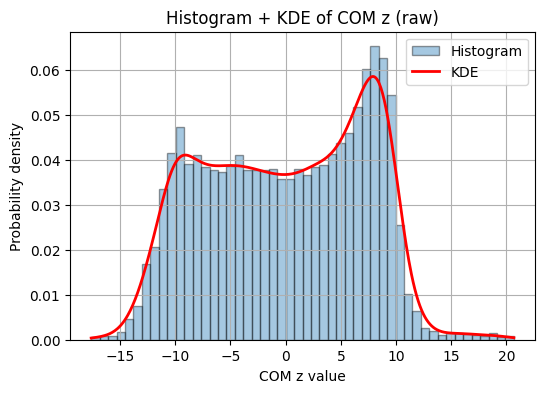

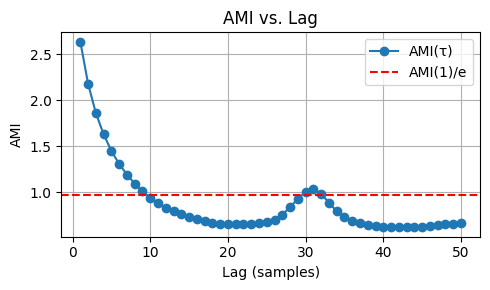

Optimal lag (τ) for axis z: 10 samples (0.100 s)


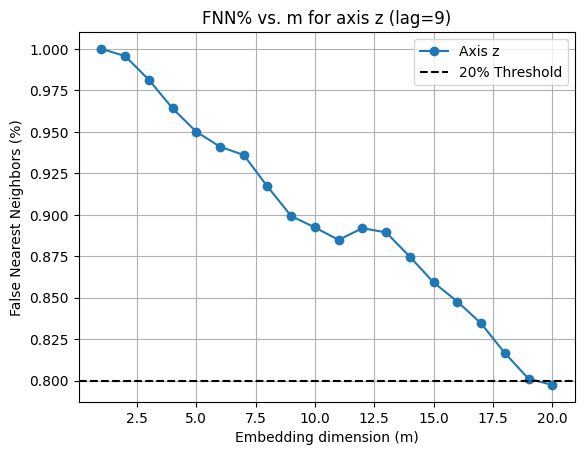

Optimal embedding dimension (m) for axis z: 11


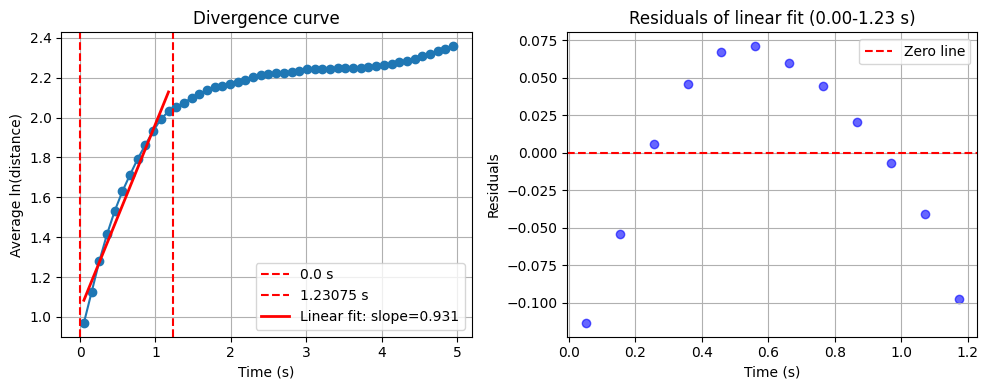

Lyapunov exponent (λ*) for axis z: 0.9310 1/s
         subject axis  average stride duration  measuring time (s)     PBT  \
0  Cereneo_SR_13    x                 1.551562               99.30  Before   
1  Cereneo_SR_13    z                 1.551562               99.30  Before   
2  Cereneo_SR_13    x                 1.520206              147.46   After   
3  Cereneo_SR_13    z                 1.520206              147.46   After   
4  Cereneo_SR_14    x                 1.230750               98.46  Before   
5  Cereneo_SR_14    z                 1.230750               98.46  Before   

   lag  embedding_dimension  fnn_threshold  lyapunov_exponent  
0   15                   17            0.8           0.610576  
1    9                   14            0.8           0.872766  
2   14                   15            0.8           0.789337  
3    9                   18            0.8           0.677714  
4   12                   17            0.8           0.641521  
5   10                 

In [11]:
ds_Y14 = xr.open_dataset(file_path_Y14)
da_Y14 = ds_Y14["markers"] if "markers" in ds_Y14 else ds_Y14
com_Y14 = da_Y14.sel(channel="COM")
time = com_Y14.coords["time"].values  
print("Time coordinates:", time[0], "to", time[-1])
fstrike_time_Y14 = get_foot_strike(events_path_Y14, foot='Right', start_time=20.0, end_time=120.0)
start_time_Y14 = fstrike_time_Y14['first_strike']
end_time_Y14 = fstrike_time_Y14['last_strike']
com_Y14= com_Y14.sel(time=slice(start_time_Y14, end_time_Y14))  
print("Selected COM shape:", start_time_Y14, end_time_Y14, com_Y14.shape)
average_stride_Y14 = get_average_stride_duration(events_path_Y14, foot='Right', start_time=20.0, end_time=120.0)
print("Average stride duration:", average_stride_Y14['mean_duration'], "±", average_stride_Y14['std_duration'], "s")

max_lag_Y14 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y14 = 20        # Search FNN% up to 20 dimensions
rtol = 0.10
fnn_threshold = 0.80
fs = 100.0
max_time_Y14 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y14 = com_Y14.sel(axis=axis).values.ravel()
    ts_Y14 = preprocess_signal(ts_Y14, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)


    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y14, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y14)            
    xs_Y14 = np.linspace(ts_Y14.min(), ts_Y14.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y14, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y14, kde(xs_Y14), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y14 = optimal_lag(ts_Y14, max_lag=max_lag_Y14, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y14} samples ({lag_Y14/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y14, fnn_perc_Y14 = compute_fnn_percentage(ts_Y14, lag_Y14, max_dim=max_dim_Y14, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y14, fnn_perc_Y14, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y13})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y14 = optimal_embedding_dimension(
        ts_Y14, lag_Y14, max_dim=max_dim_Y14, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y14}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y14 = compute_lyapunov_exponent(
        ts_Y14, emb_dim=dim_Y14, lag=lag_Y14, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y14['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y14:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_14',
    'axis': axis,
    'average stride duration': average_stride_Y14['mean_duration'],
    'measuring time (s)': end_time_Y14 - start_time_Y14,
    'PBT': 'Before',
    'lag': lag_Y14,
    'embedding_dimension': dim_Y14,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y14}
    print (results_df)



after the perturbation

Selected COM shape: 136.04 250.47 (3, 11444)
Average stride duration: 1.217340425531915 ± 0.021741984676915842 s

--- Axis: x ---


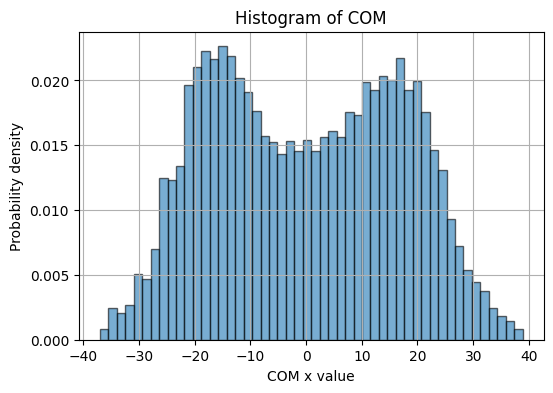

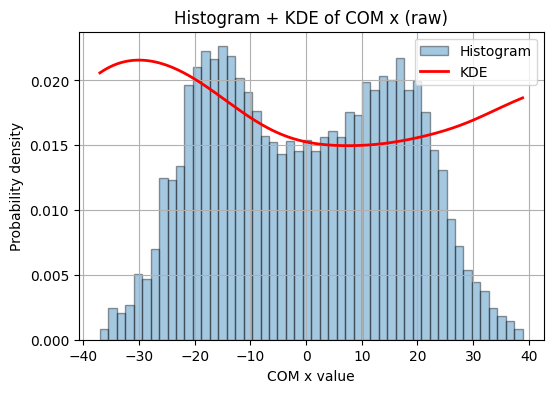

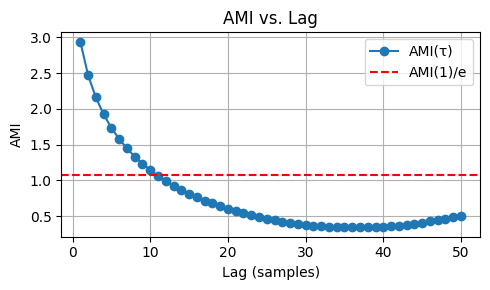

Optimal lag (τ) for axis x: 11 samples (0.110 s)


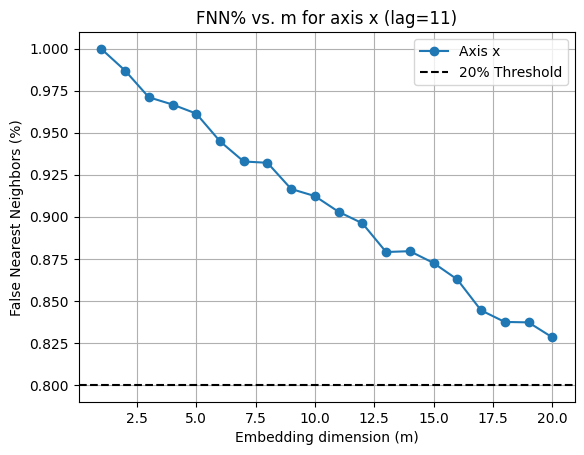

Optimal embedding dimension (m) for axis x: 13


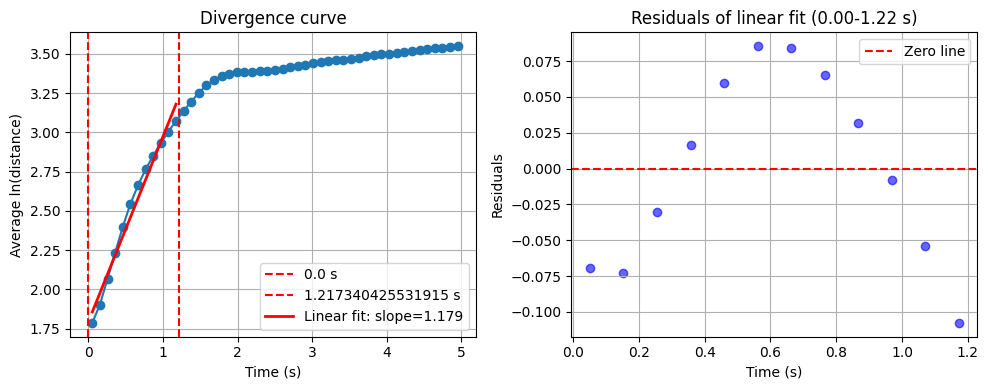

Lyapunov exponent (λ*) for axis x: 1.1791 1/s
         subject axis  average stride duration  measuring time (s)     PBT  \
0  Cereneo_SR_13    x                 1.551562               99.30  Before   
1  Cereneo_SR_13    z                 1.551562               99.30  Before   
2  Cereneo_SR_13    x                 1.520206              147.46   After   
3  Cereneo_SR_13    z                 1.520206              147.46   After   
4  Cereneo_SR_14    x                 1.230750               98.46  Before   
5  Cereneo_SR_14    z                 1.230750               98.46  Before   
6  Cereneo_SR_14    x                 1.217340              114.43   After   

   lag  embedding_dimension  fnn_threshold  lyapunov_exponent  
0   15                   17            0.8           0.610576  
1    9                   14            0.8           0.872766  
2   14                   15            0.8           0.789337  
3    9                   18            0.8           0.677714  
4   12   

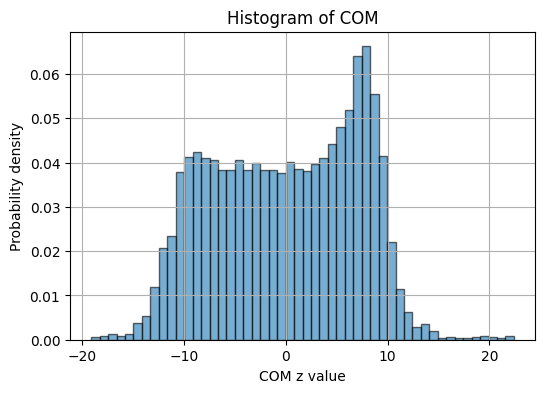

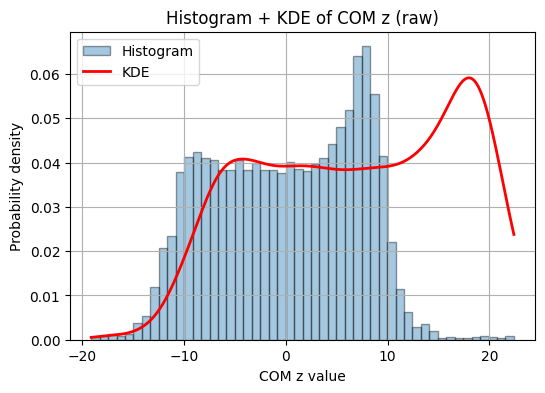

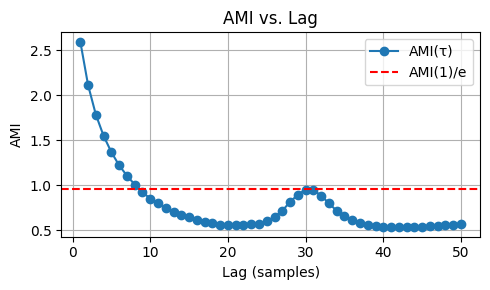

Optimal lag (τ) for axis z: 9 samples (0.090 s)


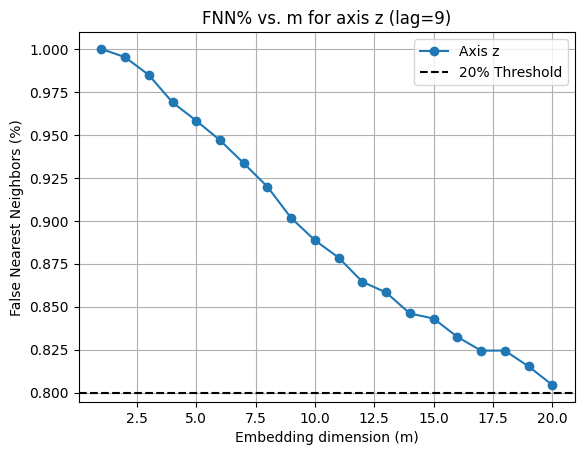

Optimal embedding dimension (m) for axis z: 14


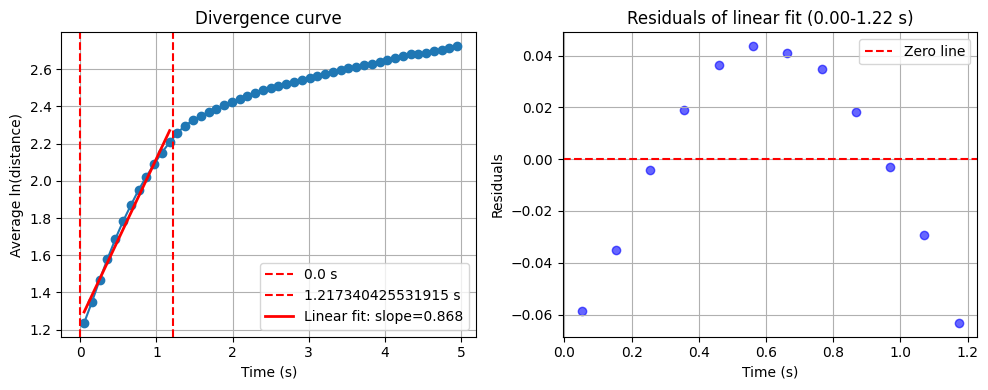

Lyapunov exponent (λ*) for axis z: 0.8684 1/s
         subject axis  average stride duration  measuring time (s)     PBT  \
0  Cereneo_SR_13    x                 1.551562               99.30  Before   
1  Cereneo_SR_13    z                 1.551562               99.30  Before   
2  Cereneo_SR_13    x                 1.520206              147.46   After   
3  Cereneo_SR_13    z                 1.520206              147.46   After   
4  Cereneo_SR_14    x                 1.230750               98.46  Before   
5  Cereneo_SR_14    z                 1.230750               98.46  Before   
6  Cereneo_SR_14    x                 1.217340              114.43   After   
7  Cereneo_SR_14    z                 1.217340              114.43   After   

   lag  embedding_dimension  fnn_threshold  lyapunov_exponent  
0   15                   17            0.8           0.610576  
1    9                   14            0.8           0.872766  
2   14                   15            0.8           0.7893

In [13]:
ds_Y14P = xr.open_dataset(file_path_Y14)
da_Y14P = ds_Y14P["markers"] if "markers" in ds_Y14P else ds_Y14P
com_Y14P = da_Y14.sel(channel="COM")
time = com_Y14P.coords["time"].values  
da_Y14P = ds_Y14P["markers"] if "markers" in ds_Y14P else ds_Y14P 
fstrike_time_Y14P = get_foot_strike(events_path_Y14, foot='Right', start_time=135.0, end_time=time[-1]-5.0)
start_time_Y14P = fstrike_time_Y14P['first_strike']
end_time_Y14P = fstrike_time_Y14P['last_strike']
com_Y14P = com_Y14P.sel(time=slice(start_time_Y14P, end_time_Y14P))  
print("Selected COM shape:", start_time_Y14P, end_time_Y14P, com_Y14P.shape)
average_stride_Y14P = get_average_stride_duration(events_path_Y14, foot='Right', start_time=135.0, end_time=time[-1]-5.0)
print("Average stride duration:", average_stride_Y14P['mean_duration'], "±", average_stride_Y14P['std_duration'], "s")

max_lag_Y14 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y14 = 20        # Search FNN% up to 20 dimensions
rtol = 0.10
fnn_threshold = 0.80
fs = 100.0
max_time_Y14 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y14P = com_Y14P.sel(axis=axis).values.ravel()
    ts_Y14P = preprocess_signal(ts_Y14P, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y14P, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y14P)            
    xs_Y14P = np.linspace(ts_Y14P.min(), ts_Y14P.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y14P, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y14P, kde(xs_Y13), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y14P = optimal_lag(ts_Y14P, max_lag=max_lag_Y14, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y14P} samples ({lag_Y14P/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y14P, fnn_perc_Y14P = compute_fnn_percentage(ts_Y14P, lag_Y14P, max_dim=max_dim_Y14, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y14P, fnn_perc_Y14P, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y14P})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y14P = optimal_embedding_dimension(
        ts_Y14P, lag_Y14P, max_dim=max_dim_Y14, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y14P}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y14P = compute_lyapunov_exponent(
        ts_Y14P, emb_dim=dim_Y14P, lag=lag_Y14P, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y14P['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y14P:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_14',
    'axis': axis,
    'average stride duration': average_stride_Y14P['mean_duration'],
    'measuring time (s)': end_time_Y14P - start_time_Y14P,
    'PBT': 'After',
    'lag': lag_Y14P,
    'embedding_dimension': dim_Y14P,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y14P}
    print (results_df)



## Lyapunov Patient 15

In [17]:
file_path_Y15 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_15" /"Pre.3"/ "markers.nc"
events_path_Y15 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_15" /"Pre.4"/ "events.nc"
markers_Y15= xr.open_dataarray(file_path_Y15)
com_Y15= markers_Y15.sel(channel="COM")
# %matplotlib widget


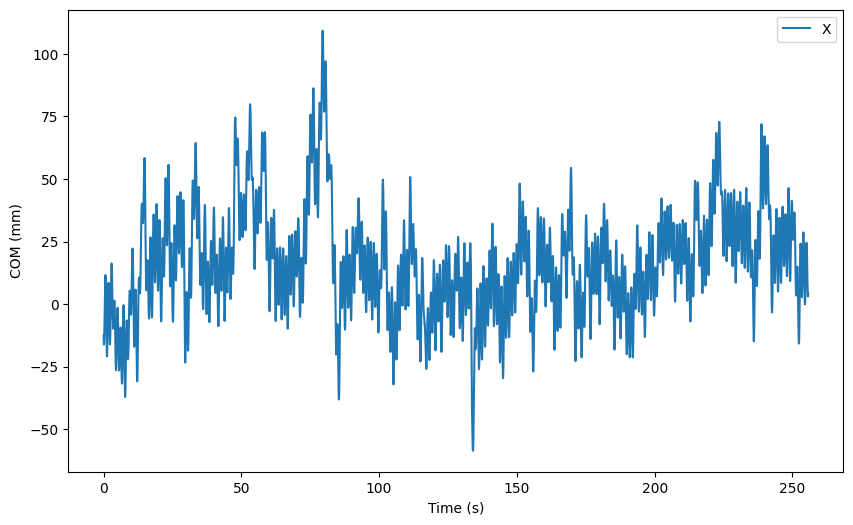

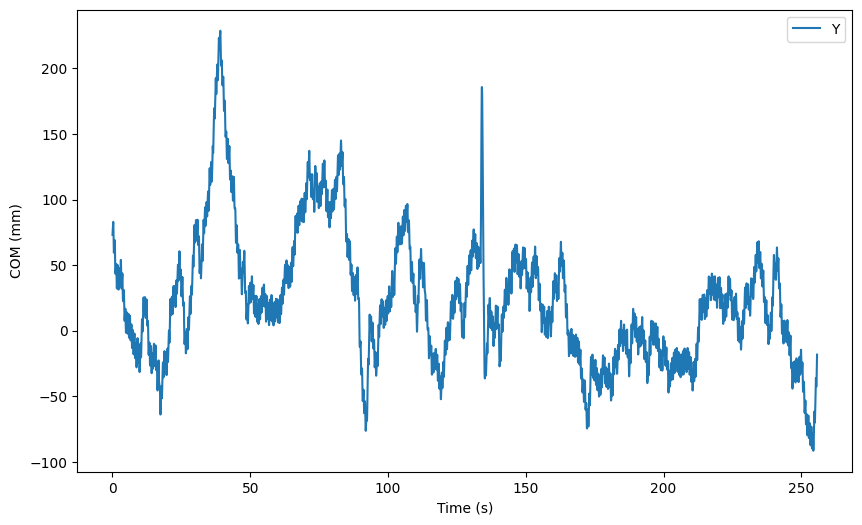

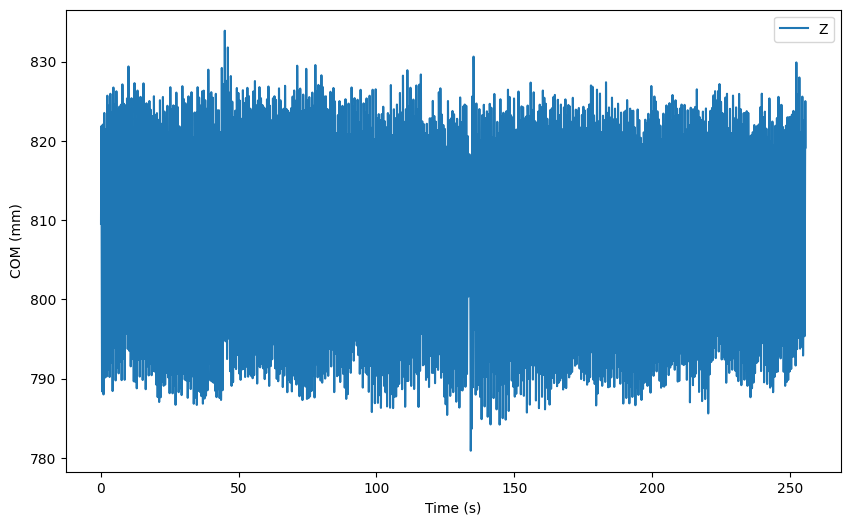

In [18]:
time = com_Y15.coords["time"].values      
x_Y15    = com_Y15.sel(axis="x").values       
y_Y15   = com_Y15.sel(axis="y").values
z_Y15    = com_Y15.sel(axis="z").values

fig = plt.figure(figsize=(10, 6))       
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x_Y15, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y_Y15, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z_Y15, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

Time coordinates: 0.02 to 255.71
Selected COM shape: 20.53 119.01 (3, 9849)
Average stride duration: 1.0942222222222222 ± 0.01299382569426172 s

--- Axis: x ---


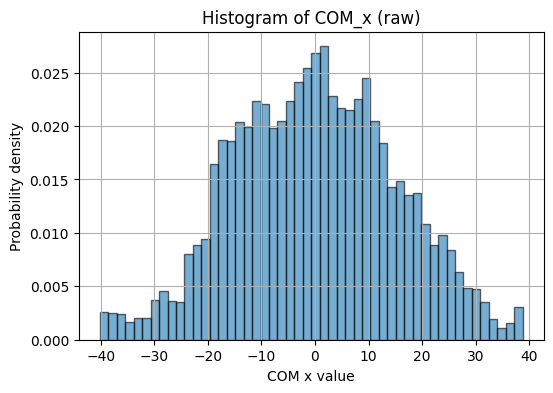

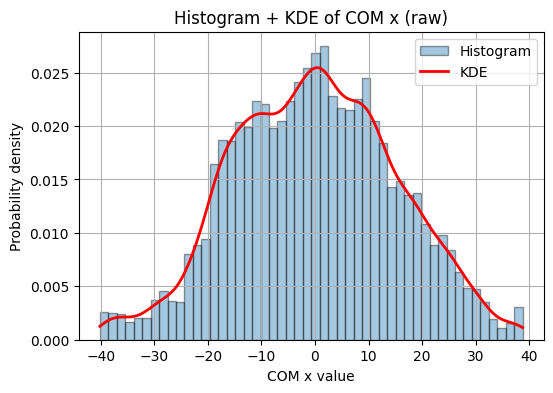

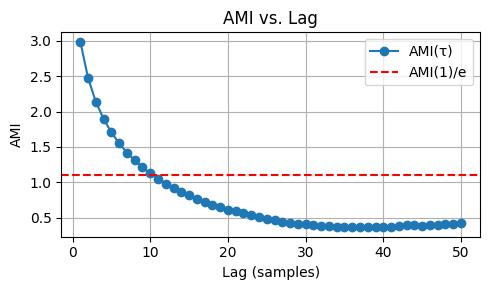

Optimal lag (τ) for axis x: 11 samples (0.110 s)


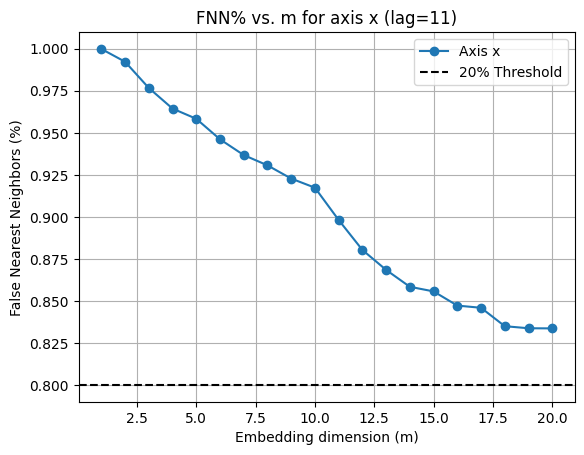

Optimal embedding dimension (m) for axis x: 10


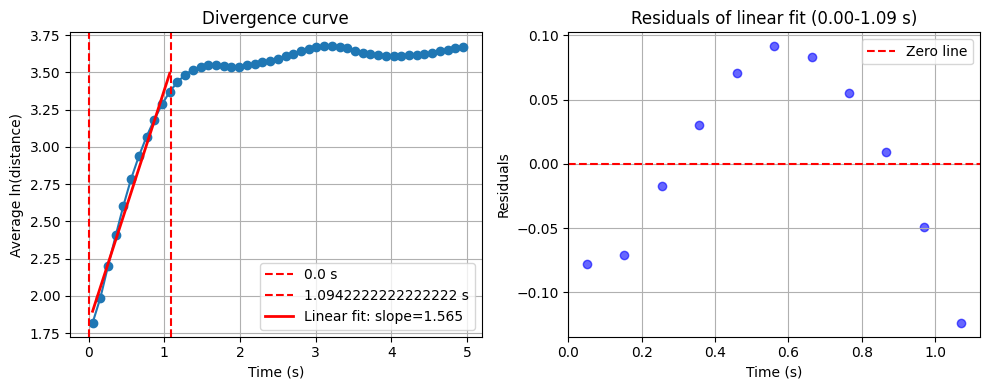

Lyapunov exponent (λ*) for axis x: 1.5652 1/s
         subject axis  average stride duration  measuring time (s)     PBT  \
0  Cereneo_SR_13    x                 1.551562               99.30  Before   
1  Cereneo_SR_13    z                 1.551562               99.30  Before   
2  Cereneo_SR_13    x                 1.520206              147.46   After   
3  Cereneo_SR_13    z                 1.520206              147.46   After   
4  Cereneo_SR_14    x                 1.230750               98.46  Before   
5  Cereneo_SR_14    z                 1.230750               98.46  Before   
6  Cereneo_SR_14    x                 1.217340              114.43   After   
7  Cereneo_SR_14    z                 1.217340              114.43   After   
8  Cereneo_SR_15    x                 1.094222               98.48  Before   

   lag  embedding_dimension  fnn_threshold  lyapunov_exponent  
0   15                   17            0.8           0.610576  
1    9                   14            0.8   

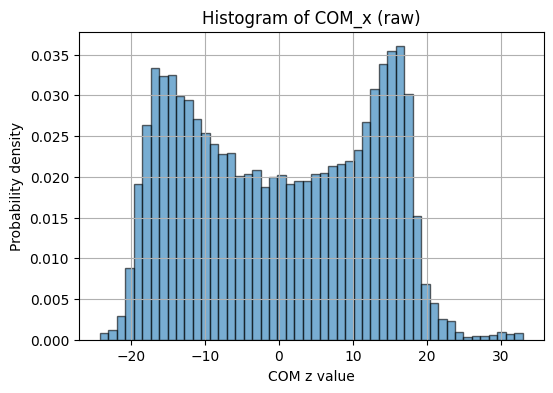

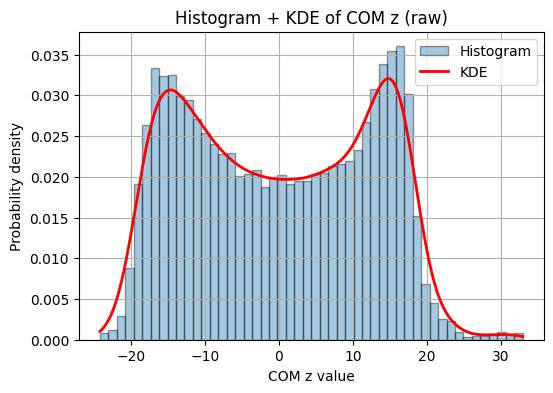

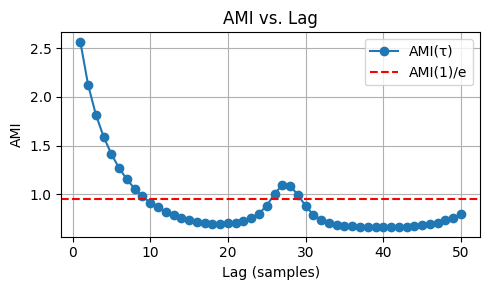

Optimal lag (τ) for axis z: 19 samples (0.190 s)


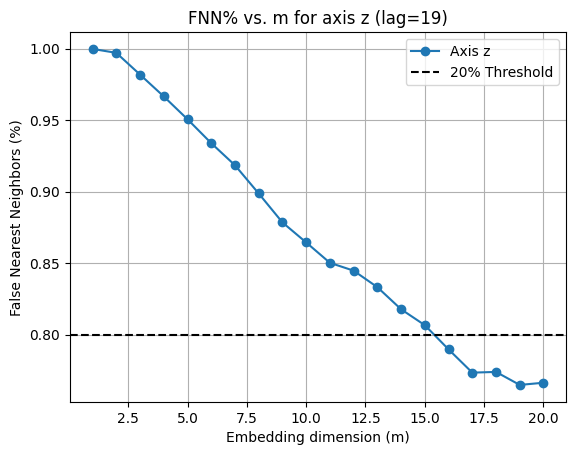

Optimal embedding dimension (m) for axis z: 17


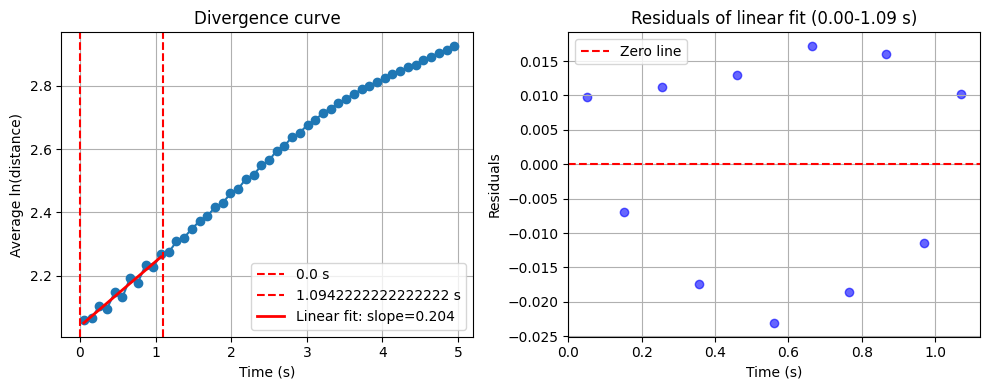

Lyapunov exponent (λ*) for axis z: 0.2045 1/s
         subject axis  average stride duration  measuring time (s)     PBT  \
0  Cereneo_SR_13    x                 1.551562               99.30  Before   
1  Cereneo_SR_13    z                 1.551562               99.30  Before   
2  Cereneo_SR_13    x                 1.520206              147.46   After   
3  Cereneo_SR_13    z                 1.520206              147.46   After   
4  Cereneo_SR_14    x                 1.230750               98.46  Before   
5  Cereneo_SR_14    z                 1.230750               98.46  Before   
6  Cereneo_SR_14    x                 1.217340              114.43   After   
7  Cereneo_SR_14    z                 1.217340              114.43   After   
8  Cereneo_SR_15    x                 1.094222               98.48  Before   
9  Cereneo_SR_15    z                 1.094222               98.48  Before   

   lag  embedding_dimension  fnn_threshold  lyapunov_exponent  
0   15                   17    

In [34]:
ds_Y15 = xr.open_dataset(file_path_Y15)
da_Y15 = ds_Y15["markers"] if "markers" in ds_Y15 else ds_Y15
com_Y15 = da_Y15.sel(channel="COM")
time = com_Y15.coords["time"].values  
print("Time coordinates:", time[0], "to", time[-1])
fstrike_time_Y15= get_foot_strike(events_path_Y15, foot='Right', start_time=20.0, end_time=120.0)
start_time_Y15 = fstrike_time_Y15['first_strike']
end_time_Y15 = fstrike_time_Y15['last_strike']
com_Y15= com_Y15.sel(time=slice(start_time_Y15, end_time_Y15))  
print("Selected COM shape:", start_time_Y15, end_time_Y15, com_Y15.shape)
average_stride_Y15 = get_average_stride_duration(events_path_Y15, foot='Right', start_time=20.0, end_time=120.0)
print("Average stride duration:", average_stride_Y15['mean_duration'], "±", average_stride_Y15['std_duration'], "s")

max_lag_Y15 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y15 = 20        # Search FNN% up to 20 dimensions
rtol = 0.10
fnn_threshold = 0.80
fs = 100.0
max_time_Y15 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y15 = com_Y15.sel(axis=axis).values.ravel()
    ts_Y15 = preprocess_signal(ts_Y15, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)


    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y15, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y15)            
    xs_Y15 = np.linspace(ts_Y15.min(), ts_Y15.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y15, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y15, kde(xs_Y15), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y15 = optimal_lag(ts_Y15, max_lag=max_lag_Y15, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y15} samples ({lag_Y15/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y15, fnn_perc_Y15 = compute_fnn_percentage(ts_Y15, lag_Y15, max_dim=max_dim_Y15, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y15, fnn_perc_Y15, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y15})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y15 = optimal_embedding_dimension(
        ts_Y15, lag_Y15, max_dim=max_dim_Y15, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y15}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y15 = compute_lyapunov_exponent(
        ts_Y15, emb_dim=dim_Y15, lag=lag_Y15, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y15['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y15:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_15',
    'axis': axis,
    'average stride duration': average_stride_Y15['mean_duration'],
    'measuring time (s)': end_time_Y15 - start_time_Y15,
    'PBT': 'Before',
    'lag': lag_Y15,
    'embedding_dimension': dim_Y15,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y15}
    print (results_df)



post eprturbation

Selected COM shape: 140.28 249.9 (3, 10963)
Average stride duration: 1.0962 ± 0.011469960767152215 s

--- Axis: x ---


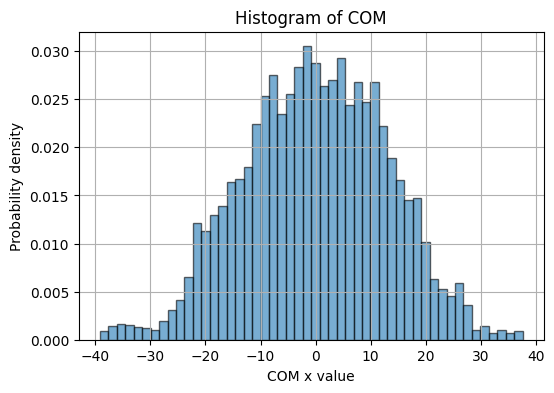

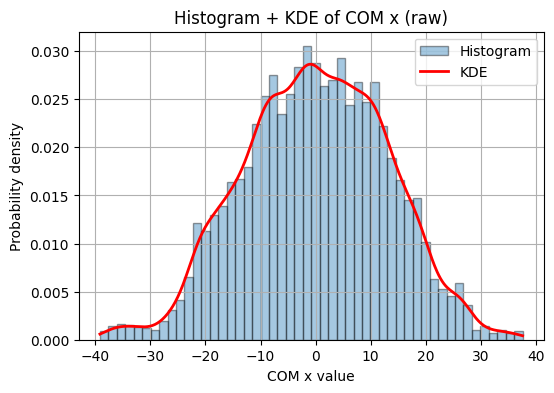

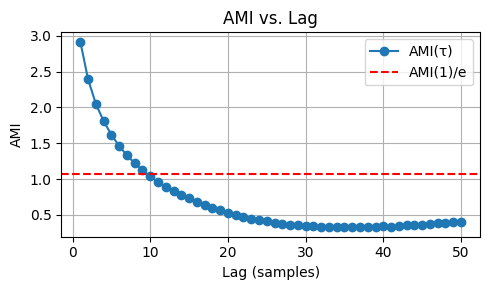

Optimal lag (τ) for axis x: 10 samples (0.100 s)


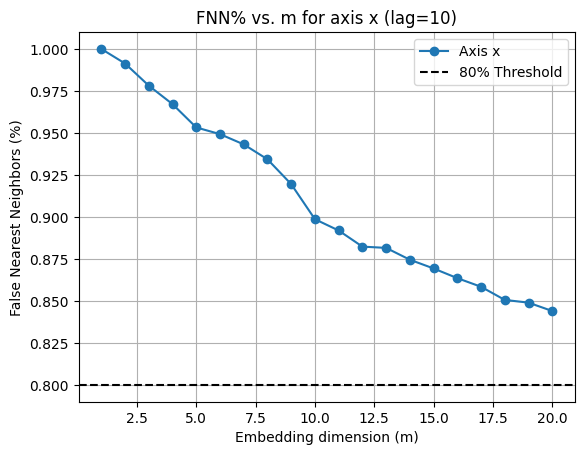

Optimal embedding dimension (m) for axis x: 10


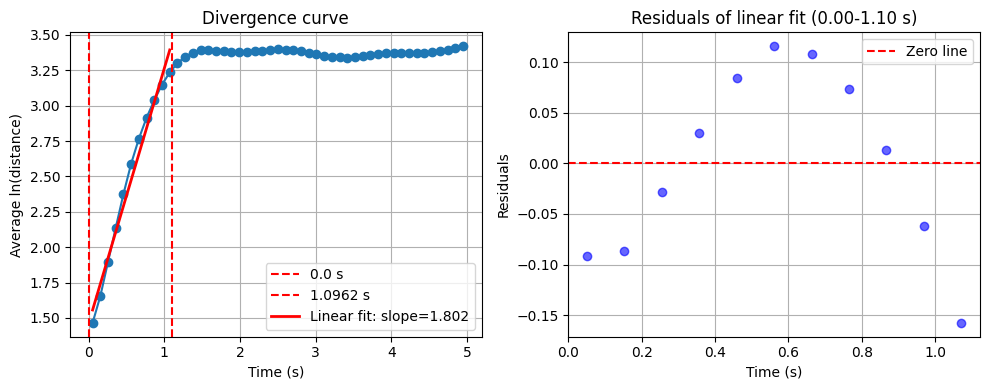

Lyapunov exponent (λ*) for axis x: 1.8015 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   

    l

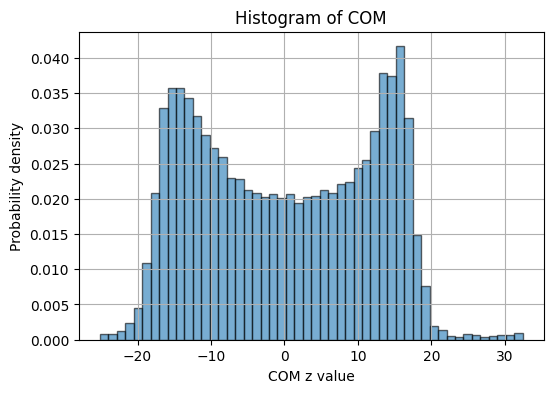

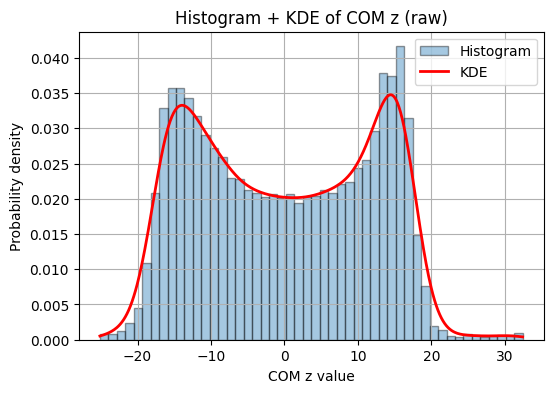

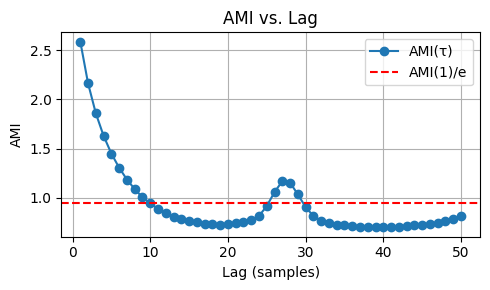

Optimal lag (τ) for axis z: 19 samples (0.190 s)


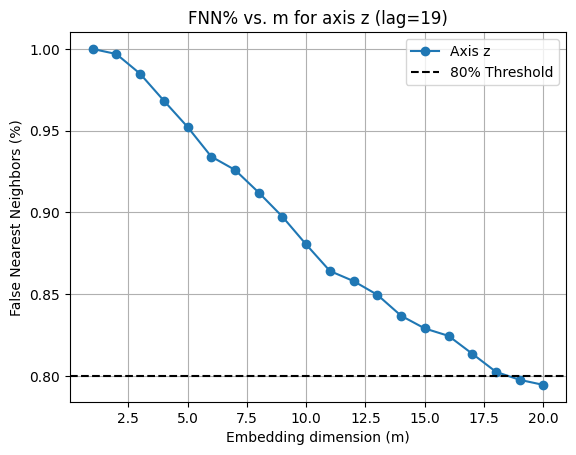

Optimal embedding dimension (m) for axis z: 11


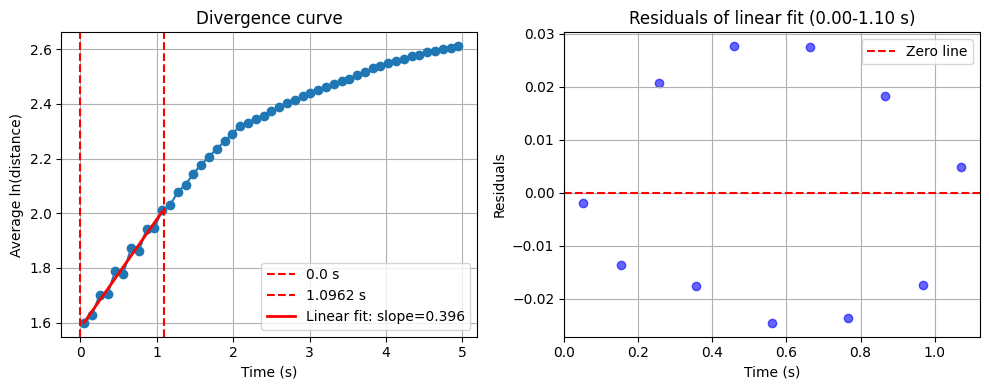

Lyapunov exponent (λ*) for axis z: 0.3965 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [35]:
ds_Y15P = xr.open_dataset(file_path_Y15)
da_Y15P = ds_Y15P["markers"] if "markers" in ds_Y15P else ds_Y15P
com_Y15P = da_Y15.sel(channel="COM")
time = com_Y15P.coords["time"].values  
da_Y15P = ds_Y15P["markers"] if "markers" in ds_Y15P else ds_Y15P 
fstrike_time_Y15P = get_foot_strike(events_path_Y15, foot='Right', start_time=140.0, end_time=time[-1]-5.0)
start_time_Y15P = fstrike_time_Y15P['first_strike']
end_time_Y15P = fstrike_time_Y15P['last_strike']
com_Y15P = com_Y15P.sel(time=slice(start_time_Y15P, end_time_Y15P))  
print("Selected COM shape:", start_time_Y15P, end_time_Y15P, com_Y15P.shape)
average_stride_Y15P = get_average_stride_duration(events_path_Y15, foot='Right', start_time=140.0, end_time=time[-1]-5.0)
print("Average stride duration:", average_stride_Y15P['mean_duration'], "±", average_stride_Y15P['std_duration'], "s")

max_lag_Y15 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y15 = 20        # Search FNN% up to 20 dimensions
rtol = 0.10
fnn_threshold = 0.80
fs = 100.0
max_time_Y15 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y15P = com_Y15P.sel(axis=axis).values.ravel()
    ts_Y15P = preprocess_signal(ts_Y15P, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y15P, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y15P)            
    xs_Y15P = np.linspace(ts_Y15P.min(), ts_Y15P.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y15P, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y15P, kde(xs_Y15P), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y15P = optimal_lag(ts_Y15P, max_lag=max_lag_Y15, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y15P} samples ({lag_Y15P/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y15P, fnn_perc_Y15P = compute_fnn_percentage(ts_Y15P, lag_Y15P, max_dim=max_dim_Y15, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y15P, fnn_perc_Y15P, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="80% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y15P})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y15P = optimal_embedding_dimension(
        ts_Y15P, lag_Y15P, max_dim=max_dim_Y15, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y15P}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y15P = compute_lyapunov_exponent(
        ts_Y15P, emb_dim=dim_Y15P, lag=lag_Y15P, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y15P['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y15P:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_15',
    'axis': axis,
    'average stride duration': average_stride_Y15P['mean_duration'],
    'measuring time (s)': end_time_Y15P - start_time_Y15P,
    'PBT': 'After',
    'lag': lag_Y15P,
    'embedding_dimension': dim_Y15P,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y15P}
    print (results_df)



## Young 16

In [37]:
file_path_Y16 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_16" /"Pre.3"/ "markers.nc"
events_path_Y16 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_16" /"Pre.4"/ "events.csv"
markers_Y16= xr.open_dataarray(file_path_Y16)
com_Y16= markers_Y16.sel(channel="COM")
# %matplotlib widget


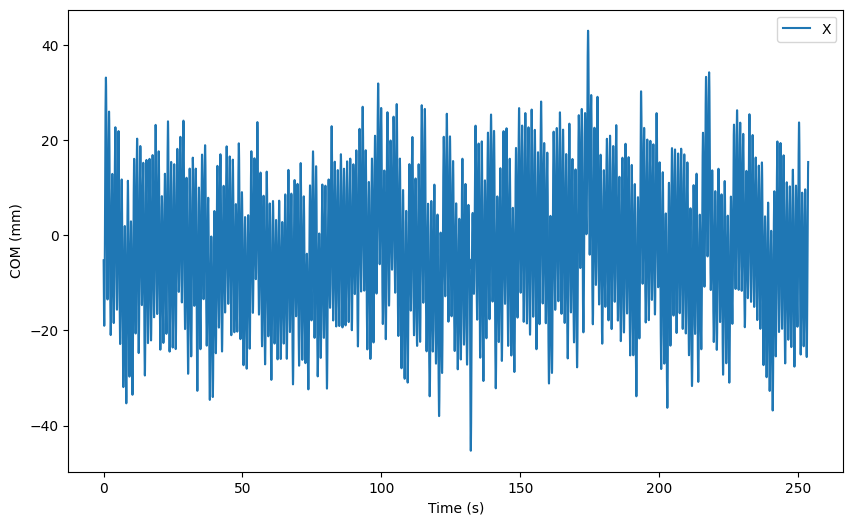

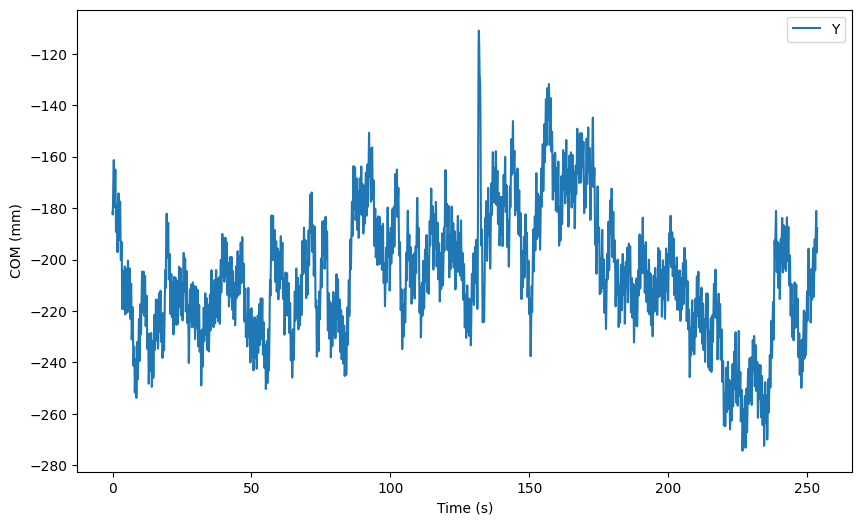

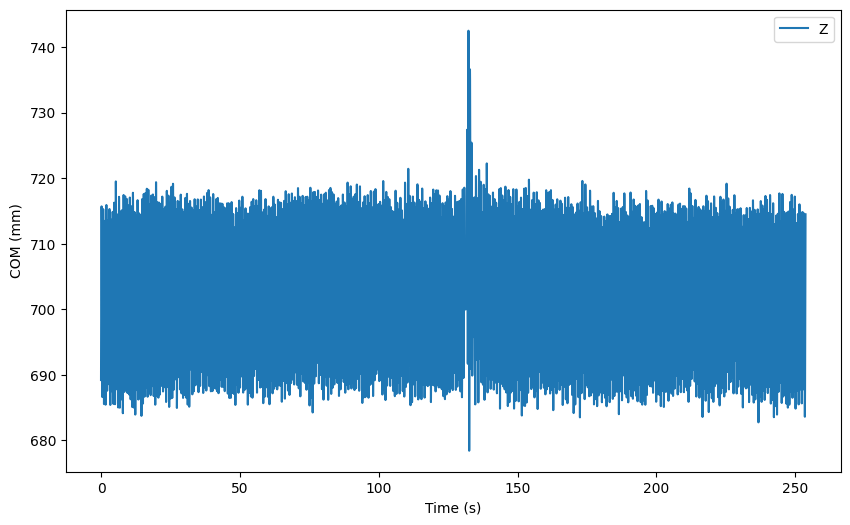

In [38]:
time = com_Y16.coords["time"].values      
x_Y16    = com_Y16.sel(axis="x").values       
y_Y16   = com_Y16.sel(axis="y").values
z_Y16    = com_Y16.sel(axis="z").values

fig = plt.figure(figsize=(10, 6))       
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x_Y16, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y_Y16, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z_Y16, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

pre perturbation

Time coordinates: 0.0 to 253.71
Selected COM shape: 20.02 119.31 (3, 9930)
Average stride duration: 1.0942222222222222 ± 0.01299382569426172 s

--- Axis: x ---


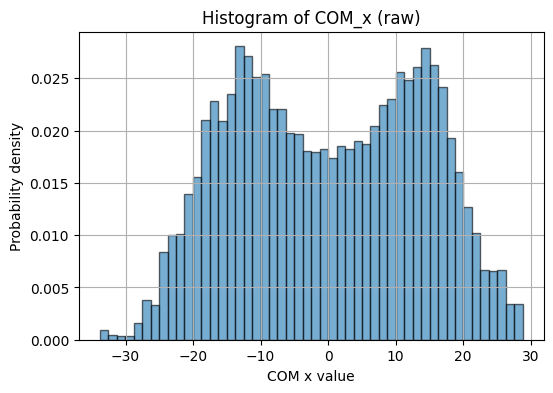

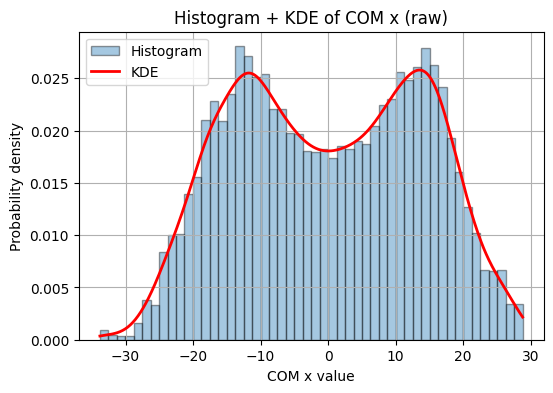

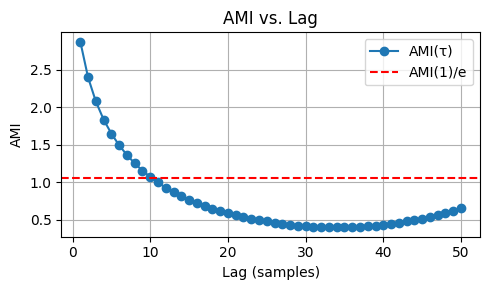

Optimal lag (τ) for axis x: 11 samples (0.110 s)


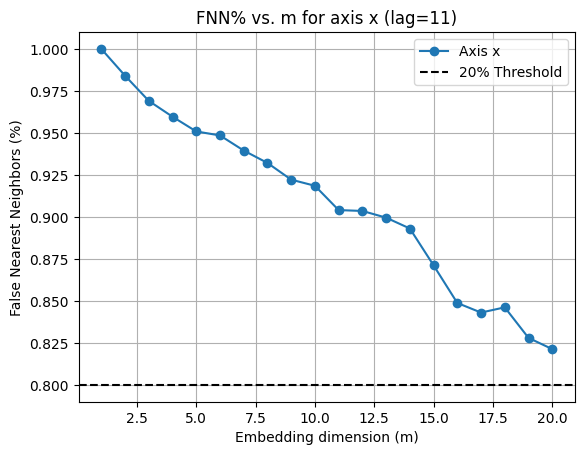

Optimal embedding dimension (m) for axis x: 18


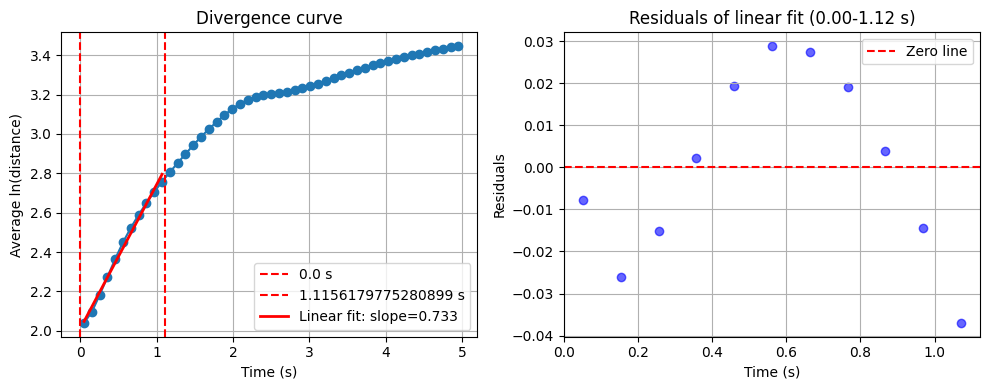

Lyapunov exponent (λ*) for axis x: 0.7325 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

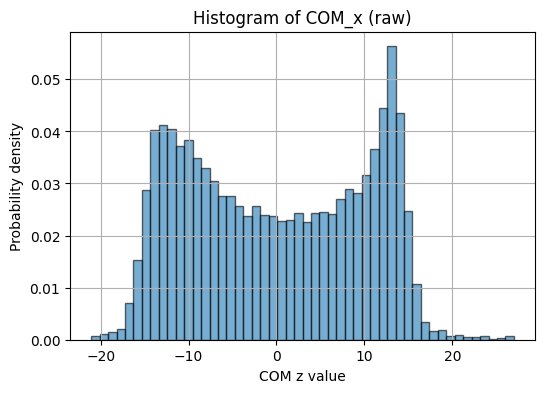

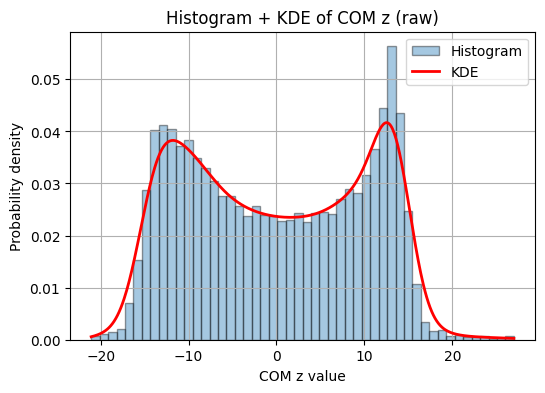

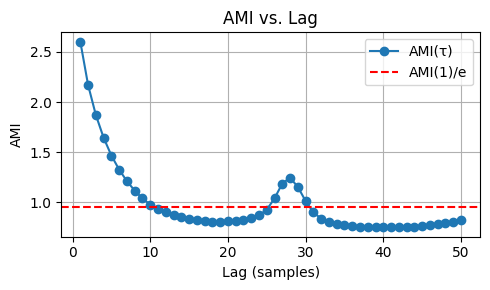

Optimal lag (τ) for axis z: 19 samples (0.190 s)


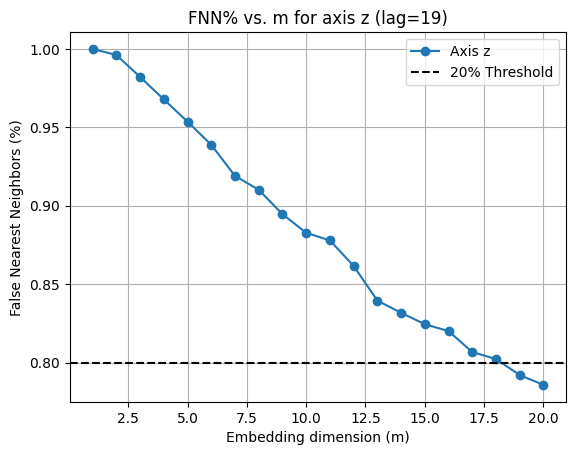

Optimal embedding dimension (m) for axis z: 13


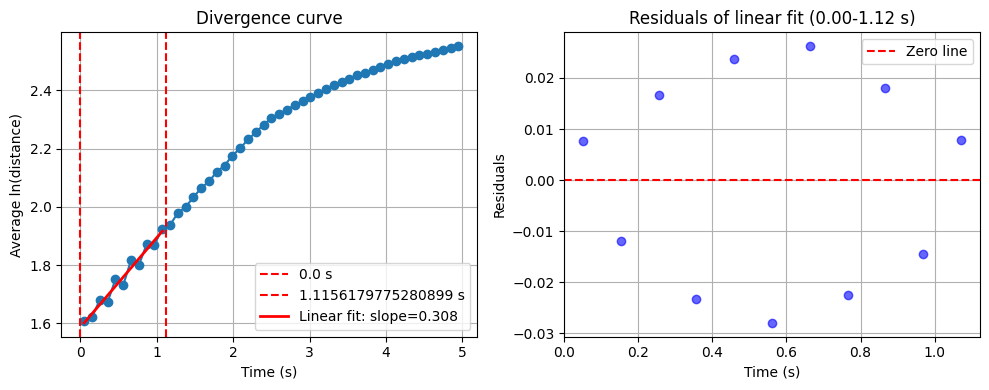

Lyapunov exponent (λ*) for axis z: 0.3082 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [39]:
ds_Y16 = xr.open_dataset(file_path_Y16)
da_Y16 = ds_Y16["markers"] if "markers" in ds_Y16 else ds_Y16
com_Y16 = da_Y16.sel(channel="COM")
time = com_Y16.coords["time"].values  
print("Time coordinates:", time[0], "to", time[-1])
fstrike_time_Y16= get_foot_strike(events_path_Y16, foot='Right', start_time=20.0, end_time=120.0)
start_time_Y16 = fstrike_time_Y16['first_strike']
end_time_Y16 = fstrike_time_Y16['last_strike']
com_Y16= com_Y16.sel(time=slice(start_time_Y16, end_time_Y16))  
print("Selected COM shape:", start_time_Y16, end_time_Y16, com_Y16.shape)
average_stride_Y16 = get_average_stride_duration(events_path_Y16, foot='Right', start_time=20.0, end_time=120.0)
print("Average stride duration:", average_stride_Y15['mean_duration'], "±", average_stride_Y15['std_duration'], "s")

max_lag_Y16 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y16 = 20        # Search FNN% up to 20 dimensions
rtol = 0.10
fnn_threshold = 0.80
fs = 100.0
max_time_Y16 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y16 = com_Y16.sel(axis=axis).values.ravel()
    ts_Y16 = preprocess_signal(ts_Y16, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)


    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y16, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM_x (raw)')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y16)            
    xs_Y16 = np.linspace(ts_Y16.min(), ts_Y16.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y16, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y16, kde(xs_Y16), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y16 = optimal_lag(ts_Y16, max_lag=max_lag_Y16, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y16} samples ({lag_Y16/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y16, fnn_perc_Y16 = compute_fnn_percentage(ts_Y16, lag_Y16, max_dim=max_dim_Y16, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y16, fnn_perc_Y16, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="20% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y16})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y16 = optimal_embedding_dimension(
        ts_Y16, lag_Y16, max_dim=max_dim_Y16, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y16}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y16 = compute_lyapunov_exponent(
        ts_Y16, emb_dim=dim_Y16, lag=lag_Y16, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y16['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y16:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_16',
    'axis': axis,
    'average stride duration': average_stride_Y16['mean_duration'],
    'measuring time (s)': end_time_Y16 - start_time_Y16,
    'PBT': 'Before',
    'lag': lag_Y16,
    'embedding_dimension': dim_Y16,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y16}
    print (results_df)



post pertubration

Selected COM shape: 135.24 248.38 (3, 11315)
Average stride duration: 1.12019801980198 ± 0.013048287928344423 s

--- Axis: x ---


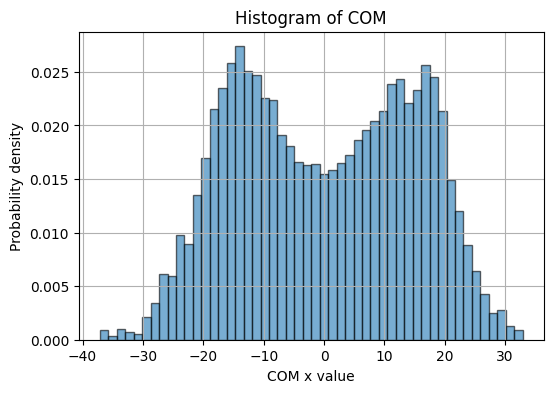

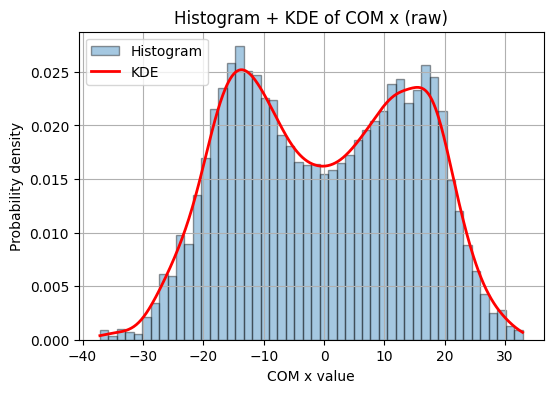

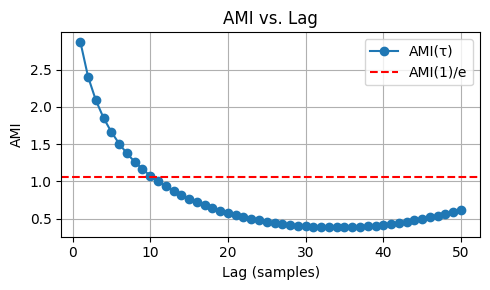

Optimal lag (τ) for axis x: 11 samples (0.110 s)


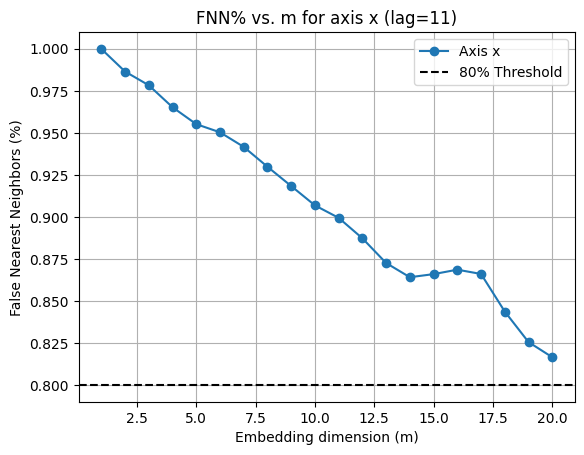

Optimal embedding dimension (m) for axis x: 17


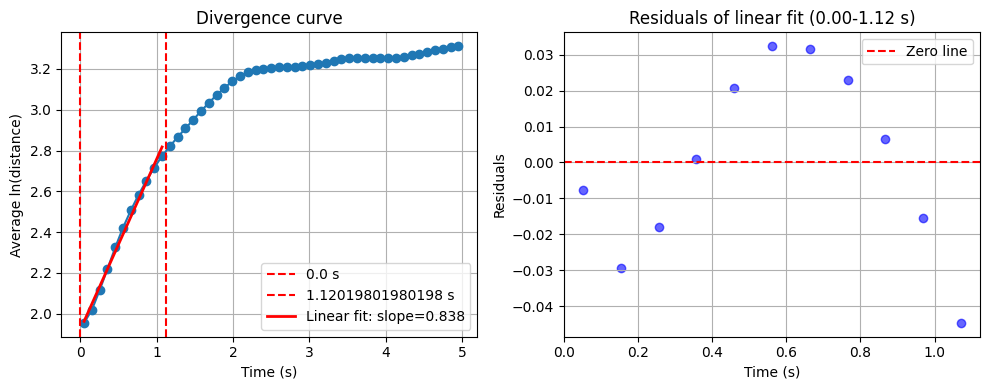

Lyapunov exponent (λ*) for axis x: 0.8381 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

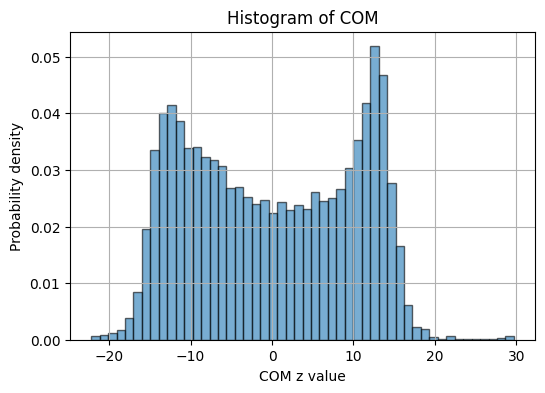

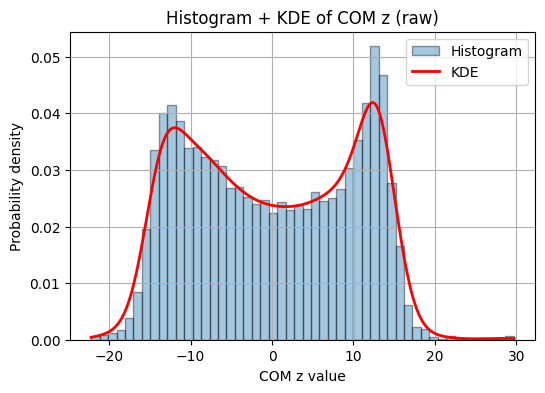

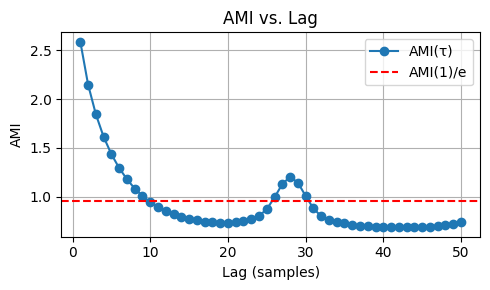

Optimal lag (τ) for axis z: 19 samples (0.190 s)


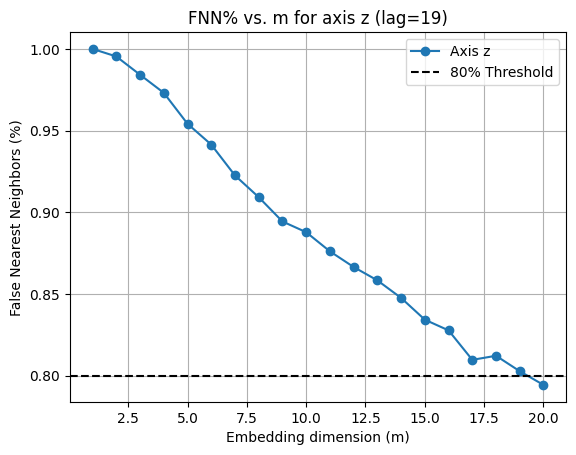

Optimal embedding dimension (m) for axis z: 17


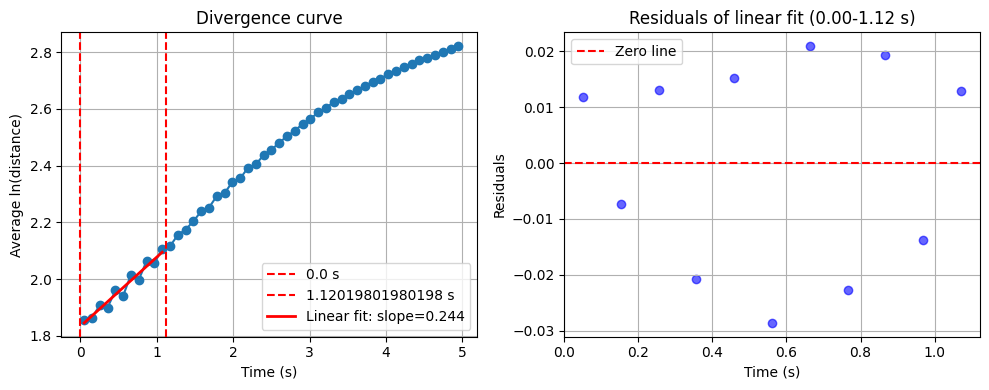

Lyapunov exponent (λ*) for axis z: 0.2443 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [42]:
ds_Y16 = xr.open_dataset(file_path_Y16)
da_Y16 = ds_Y16["markers"] if "markers" in ds_Y16 else ds_Y16
com_Y16 = da_Y16.sel(channel="COM")
time = com_Y16.coords["time"].values  
da_Y16 = ds_Y16["markers"] if "markers" in ds_Y16 else ds_Y16 
fstrike_time_Y16 = get_foot_strike(events_path_Y16, foot='Right', start_time=135.0, end_time=time[-1]-5.0)
start_time_Y16 = fstrike_time_Y16['first_strike']
end_time_Y16 = fstrike_time_Y16['last_strike']
com_Y16 = com_Y16.sel(time=slice(start_time_Y16, end_time_Y16))  
print("Selected COM shape:", start_time_Y16, end_time_Y16, com_Y16.shape)
average_stride_Y16 = get_average_stride_duration(events_path_Y16, foot='Right', start_time=135.0, end_time=time[-1]-5.0)
print("Average stride duration:", average_stride_Y16['mean_duration'], "±", average_stride_Y16['std_duration'], "s")

max_lag_Y16 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y16 = 20        # Search FNN% up to 20 dimensions
rtol = 0.10
fnn_threshold = 0.80
fs = 100.0
max_time_Y16 = 10.0     # Max evolution time for divergence (s)

for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    ts_Y16P = com_Y16.sel(axis=axis).values.ravel()
    ts_Y16P = preprocess_signal(ts_Y16P, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y16P, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

    kde = gaussian_kde(ts_Y16P)            
    xs_Y16P = np.linspace(ts_Y16P.min(), ts_Y16P.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y16P, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y16P, kde(xs_Y16P), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    lag_Y16P = optimal_lag(ts_Y16P, max_lag=max_lag_Y16, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y16P} samples ({lag_Y16P/fs:.3f} s)")

    dims_Y16P, fnn_perc_Y16P = compute_fnn_percentage(ts_Y16P, lag_Y16P, max_dim=max_dim_Y16, rtol=rtol)

    plt.figure()
    plt.plot(dims_Y16P, fnn_perc_Y16P, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="80% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y16P})")
    plt.grid(True)
    plt.legend()
    plt.show()

    dim_Y16P = optimal_embedding_dimension(
        ts_Y16P, lag_Y16P, max_dim=max_dim_Y16, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y16P}")

    lyap_Y16P = compute_lyapunov_exponent(
        ts_Y16P, emb_dim=dim_Y16P, lag=lag_Y16P, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y16['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y16P:.4f} 1/s")

    results_df.loc[len(results_df)] = {
        'subject': 'Cereneo_SR_16',
        'axis': axis,
        'average stride duration': average_stride_Y16['mean_duration'],
        'measuring time (s)': end_time_Y16 - start_time_Y16,
        'PBT': 'After',
        'lag': lag_Y16P,
        'embedding_dimension': dim_Y16P,
        'fnn_threshold': fnn_threshold,
        'lyapunov_exponent': lyap_Y16P
    }
    print(results_df)

## Young 17

In [53]:
file_path_Y17 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_17" /"Pre.3"/ "markers.nc"
events_path_Y17 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_17" /"Pre.4"/ "events.nc"
markers_Y17= xr.open_dataarray(file_path_Y17)
com_Y17= markers_Y17.sel(channel="COM")
# %matplotlib widget

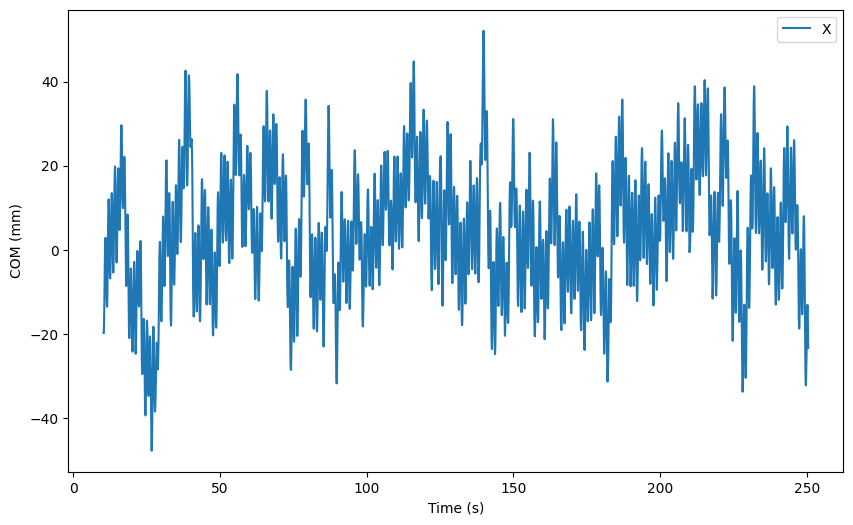

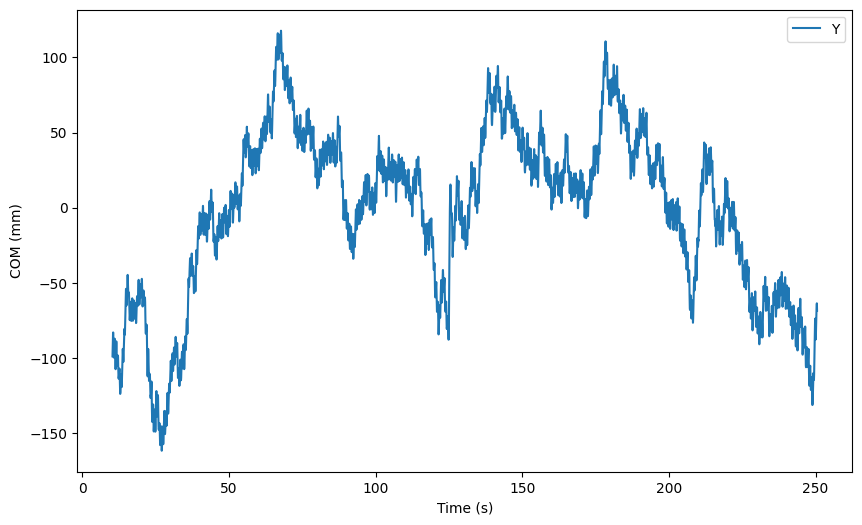

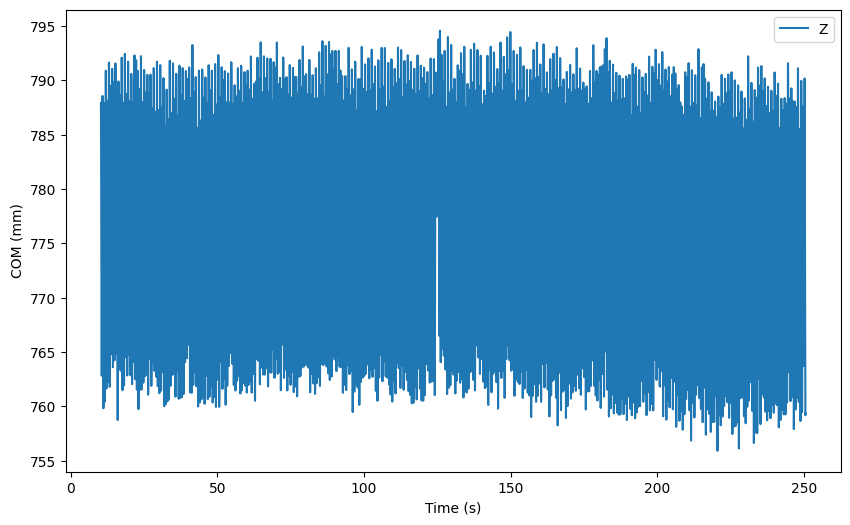

In [54]:
time = com_Y17.coords["time"].values      
x_Y17    = com_Y17.sel(axis="x").values       
y_Y17  = com_Y17.sel(axis="y").values
z_Y17    = com_Y17.sel(axis="z").values

fig = plt.figure(figsize=(10, 6))       
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x_Y17, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y_Y17, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z_Y17, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

pre perturbation

Time coordinates: 10.3 to 250.52
Selected COM shape: 50.57 129.94 (3, 7938)
Average stride duration: 1.1023611111111111 ± 0.06882935935977082 s

--- Axis: x ---


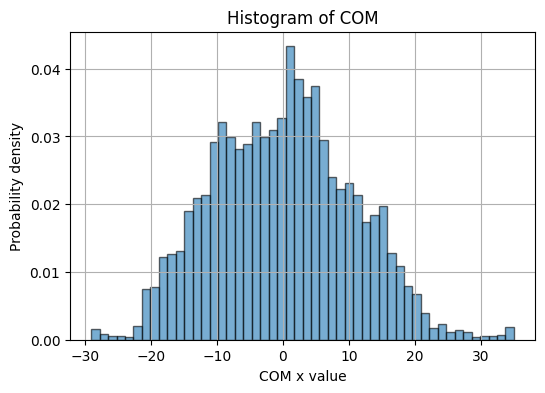

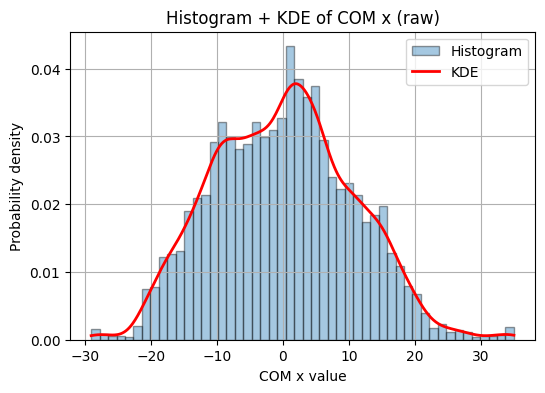

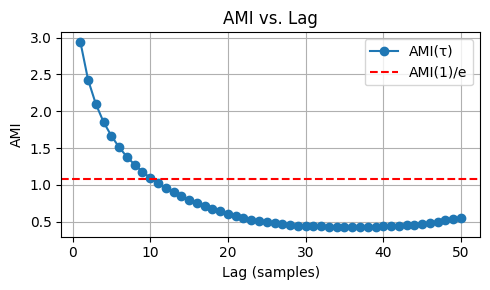

Optimal lag (τ) for axis x: 11 samples (0.110 s)


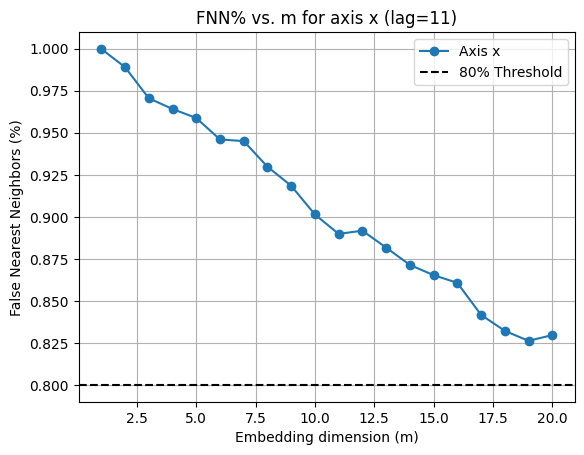

Optimal embedding dimension (m) for axis x: 16


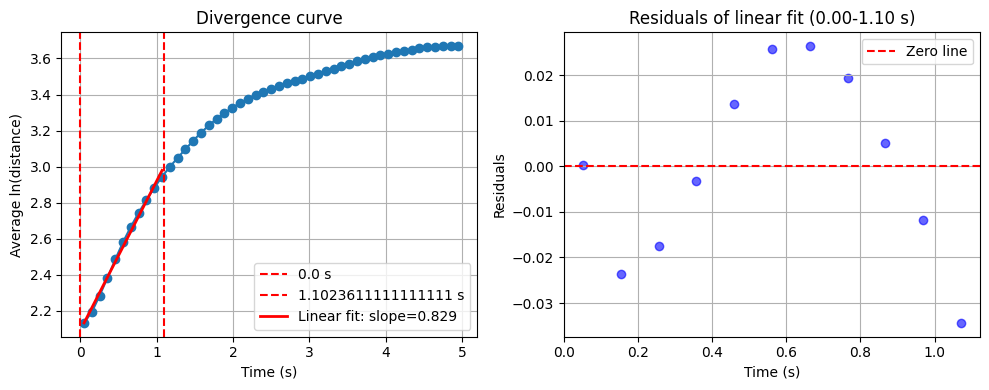

Lyapunov exponent (λ*) for axis x: 0.8288 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

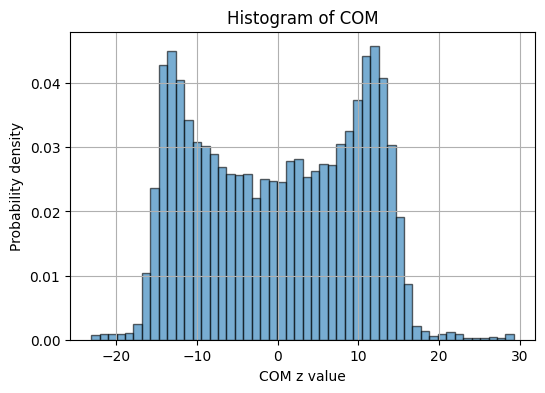

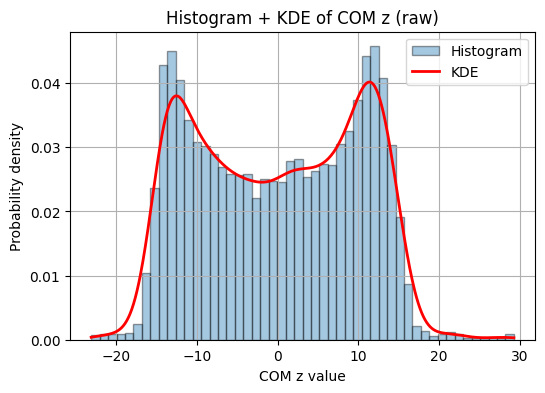

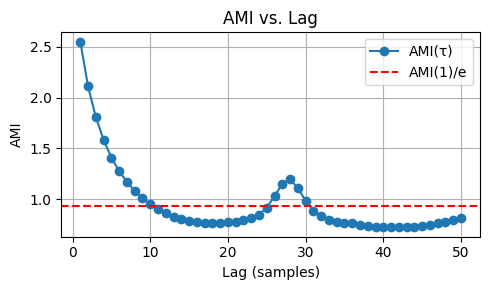

Optimal lag (τ) for axis z: 18 samples (0.180 s)


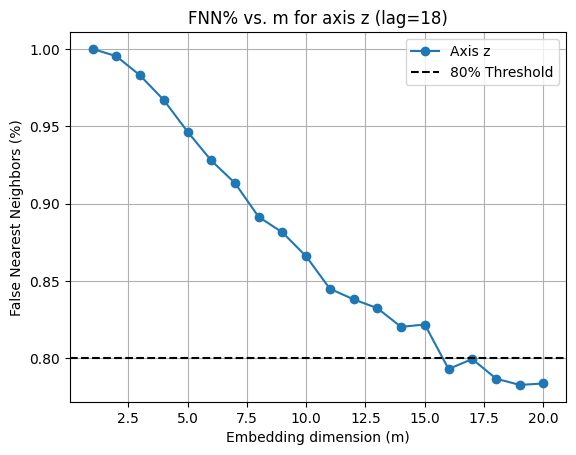

Optimal embedding dimension (m) for axis z: 16


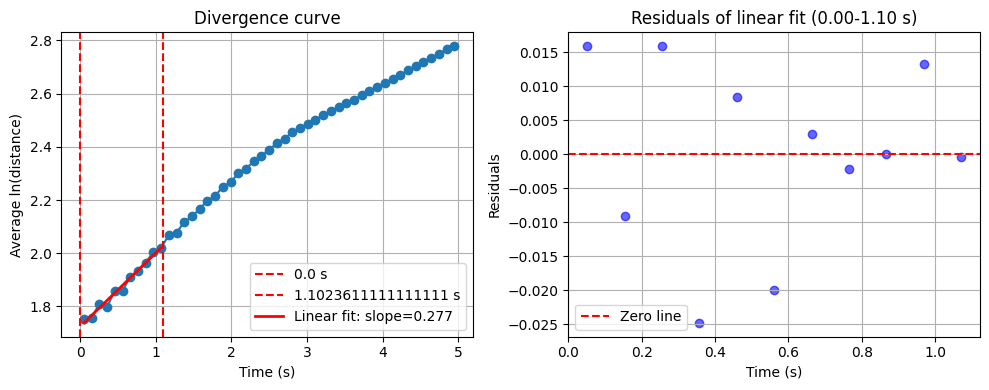

Lyapunov exponent (λ*) for axis z: 0.2768 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [55]:
ds_Y17 = xr.open_dataset(file_path_Y17)
da_Y17 = ds_Y17["markers"] if "markers" in ds_Y17 else ds_Y17
com_Y17 = da_Y17.sel(channel="COM")
time = com_Y17.coords["time"].values  
print("Time coordinates:", time[0], "to", time[-1])

fstrike_time_Y17 = get_foot_strike(events_path_Y17, foot='Right', start_time=50.0, end_time=130.0)
start_time_Y17 = fstrike_time_Y17['first_strike']
end_time_Y17   = fstrike_time_Y17['last_strike']
com_Y17 = com_Y17.sel(time=slice(start_time_Y17, end_time_Y17))  
print("Selected COM shape:", start_time_Y17, end_time_Y17, com_Y17.shape)

average_stride_Y17 = get_average_stride_duration(events_path_Y17, foot='Right', start_time=50.0, end_time=130.0)
print("Average stride duration:", average_stride_Y17['mean_duration'], "±", average_stride_Y17['std_duration'], "s")

max_lag_Y17     = 50        # Search AMI up to 50 samples (0.50 s)
bins            = 64
max_dim_Y17     = 20        # Search FNN% up to 20 dimensions
rtol            = 0.10
fnn_threshold   = 0.80
fs              = 100.0
max_time_Y17    = 10.0      # Max evolution time for divergence (s)

for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    ts_Y17 = com_Y17.sel(axis=axis).values.ravel()
    ts_Y17 = preprocess_signal(ts_Y17, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    # Histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y17, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

    # KDE overlay
    kde   = gaussian_kde(ts_Y17)
    xs_Y17 = np.linspace(ts_Y17.min(), ts_Y17.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y17, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y17, kde(xs_Y17), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Optimal lag via AMI
    lag_Y17 = optimal_lag(ts_Y17, max_lag=max_lag_Y17, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y17} samples ({lag_Y17/fs:.3f} s)")

    # False Nearest Neighbors
    dims_Y17, fnn_perc_Y17 = compute_fnn_percentage(ts_Y17, lag_Y17, max_dim=max_dim_Y17, rtol=rtol)
    plt.figure()
    plt.plot(dims_Y17, fnn_perc_Y17, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="80% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y17})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Determine embedding dimension
    dim_Y17 = optimal_embedding_dimension(ts_Y17, lag_Y17, max_dim=max_dim_Y17, rtol=rtol)
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y17}")

    # Lyapunov exponent
    lyap_Y17 = compute_lyapunov_exponent(
        ts_Y17,
        emb_dim=dim_Y17,
        lag=lag_Y17,
        fs=fs,
        max_time=5.0,
        fit_start=0.0,
        fit_end=average_stride_Y17['mean_duration'],
        plot_residuals=True
    )
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y17:.4f} 1/s")

    results_df.loc[len(results_df)] = {
        'subject': 'Cereneo_SR_17',
        'axis': axis,
        'average stride duration': average_stride_Y17['mean_duration'],
        'measuring time (s)': end_time_Y17 - start_time_Y17,
        'PBT': 'Before',
        'lag': lag_Y17,
        'embedding_dimension': dim_Y17,
        'fnn_threshold': fnn_threshold,
        'lyapunov_exponent': lyap_Y17
    }
    print(results_df)


post pertubration 

Selected COM shape: 140.04 244.81 (3, 10478)
Average stride duration: 1.1265591397849464 ± 0.014255323371333005 s

--- Axis: x ---


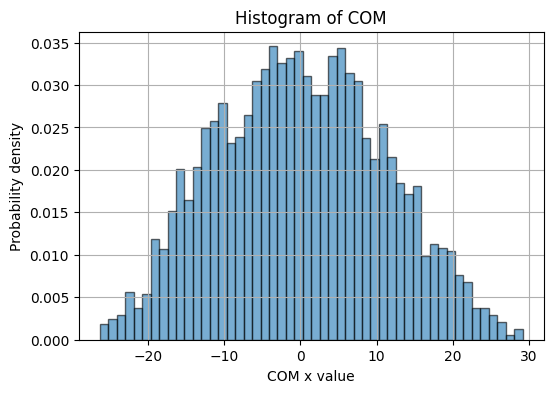

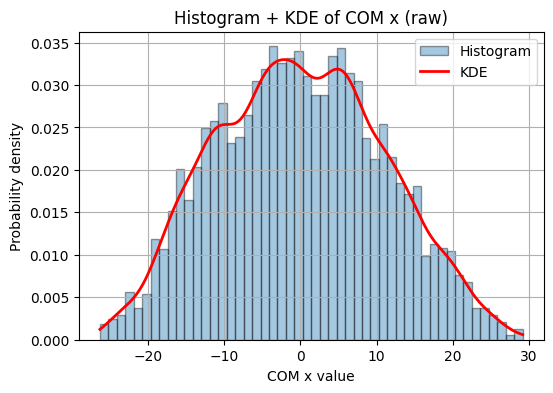

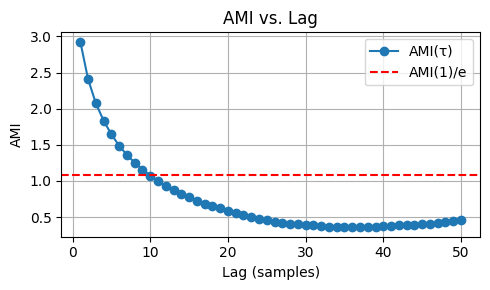

Optimal lag (τ) for axis x: 10 samples (0.100 s)


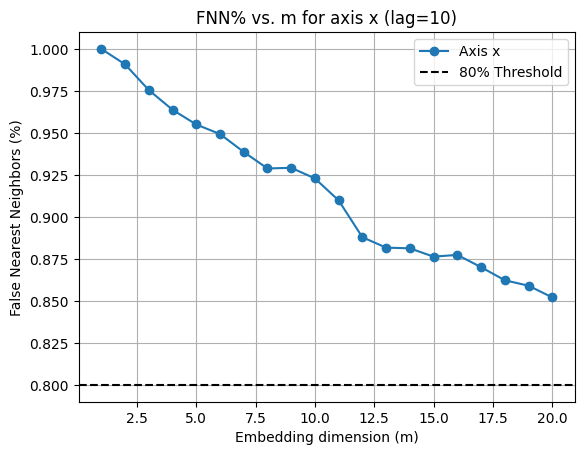

Optimal embedding dimension (m) for axis x: 12


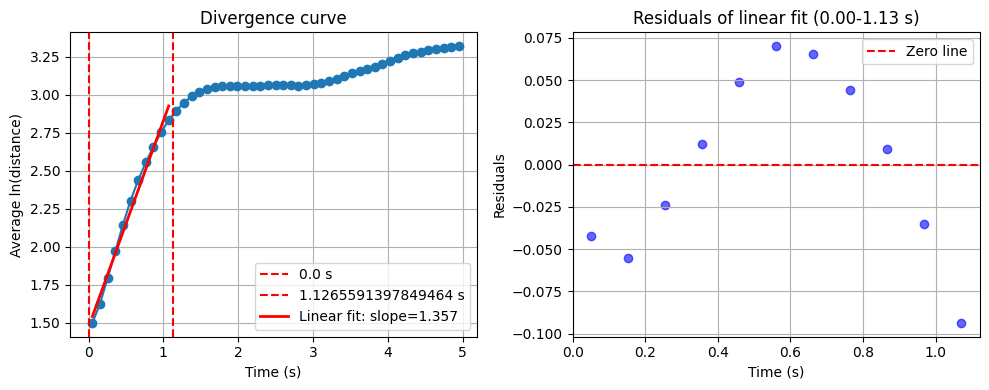

Lyapunov exponent (λ*) for axis x: 1.3567 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

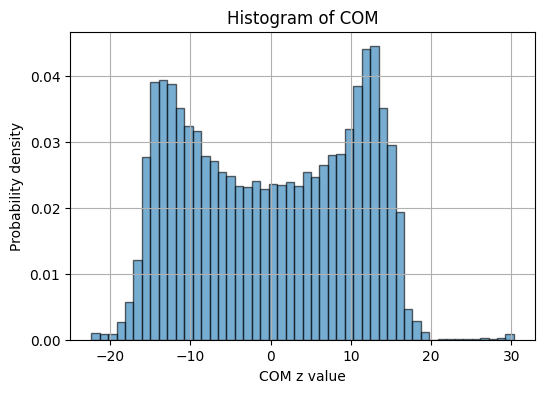

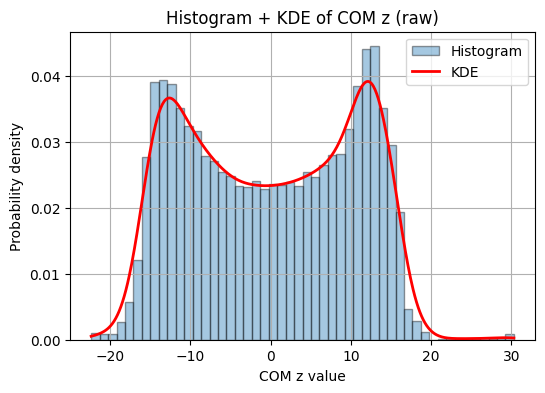

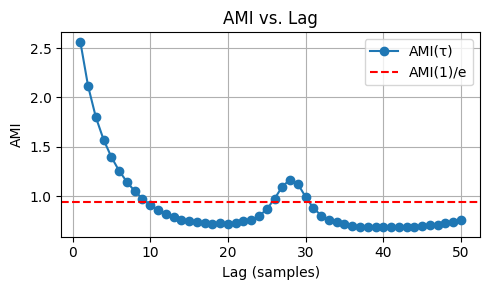

Optimal lag (τ) for axis z: 18 samples (0.180 s)


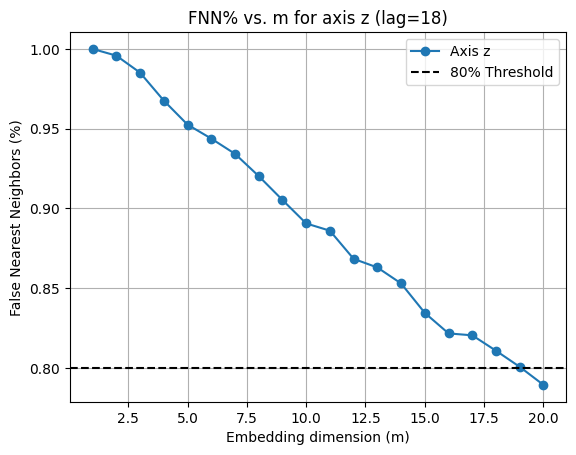

Optimal embedding dimension (m) for axis z: 11


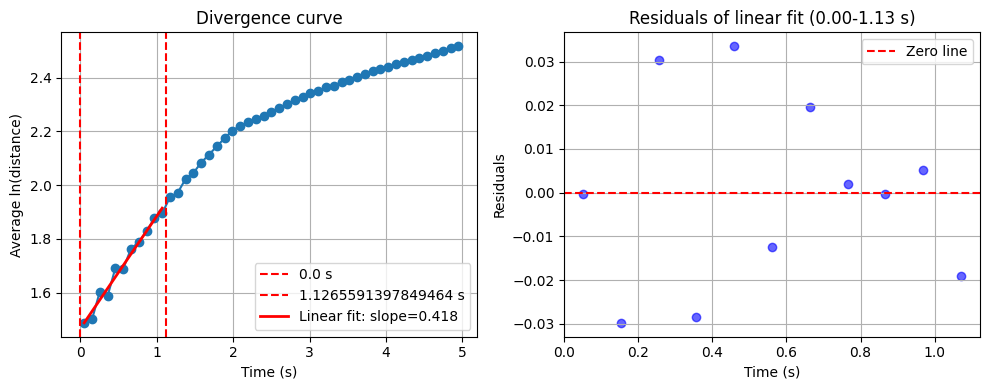

Lyapunov exponent (λ*) for axis z: 0.4184 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [56]:
ds_Y17P = xr.open_dataset(file_path_Y17)
da_Y17P = ds_Y17P["markers"] if "markers" in ds_Y17P else ds_Y17P
com_Y17P = da_Y17.sel(channel="COM")
time = com_Y17P.coords["time"].values  
da_Y17P = ds_Y17P["markers"] if "markers" in ds_Y17P else ds_Y17P 
fstrike_time_Y17P = get_foot_strike(events_path_Y17, foot='Right', start_time=140.0, end_time=time[-1]-5.0)
start_time_Y17P = fstrike_time_Y17P['first_strike']
end_time_Y17P = fstrike_time_Y17P['last_strike']
com_Y17P = com_Y17P.sel(time=slice(start_time_Y17P, end_time_Y17P))  
print("Selected COM shape:", start_time_Y17P, end_time_Y17P, com_Y17P.shape)
average_stride_Y17P = get_average_stride_duration(events_path_Y17, foot='Right', start_time=140.0, end_time=time[-1]-5.0)
print("Average stride duration:", average_stride_Y17P['mean_duration'], "±", average_stride_Y17P['std_duration'], "s")

max_lag_Y17 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y17 = 20        # Search FNN% up to 20 dimensions
rtol = 0.10
fnn_threshold = 0.80
fs = 100.0
max_time_Y17 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y17P = com_Y17P.sel(axis=axis).values.ravel()
    ts_Y17P = preprocess_signal(ts_Y17P, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y17P, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y17P)            
    xs_Y17P = np.linspace(ts_Y17P.min(), ts_Y17P.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y17P, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y17P, kde(xs_Y17P), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y17P = optimal_lag(ts_Y17P, max_lag=max_lag_Y17, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y17P} samples ({lag_Y17P/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y17P, fnn_perc_Y17P = compute_fnn_percentage(ts_Y17P, lag_Y17P, max_dim=max_dim_Y17, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y17P, fnn_perc_Y17P, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="80% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y17P})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y17P = optimal_embedding_dimension(
        ts_Y17P, lag_Y17P, max_dim=max_dim_Y17, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y17P}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y17P = compute_lyapunov_exponent(
        ts_Y17P, emb_dim=dim_Y17P, lag=lag_Y17P, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y17P['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y17P:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_17',
    'axis': axis,
    'average stride duration': average_stride_Y17P['mean_duration'],
    'measuring time (s)': end_time_Y17P - start_time_Y17P,
    'PBT': 'After',
    'lag': lag_Y17P,
    'embedding_dimension': dim_Y17P,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y17P}
    print (results_df)



In [52]:
print(results_df)

          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Cereneo_SR_15    z                 1.096200     

## Young 18

In [57]:
file_path_Y18 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_18" /"Pre.3"/ "markers.nc"
events_path_Y18 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_18" /"Pre.4"/ "events.csv"
markers_Y18 = xr.open_dataarray(file_path_Y18)
com_Y18 = markers_Y18.sel(channel="COM")
# %matplotlib widget

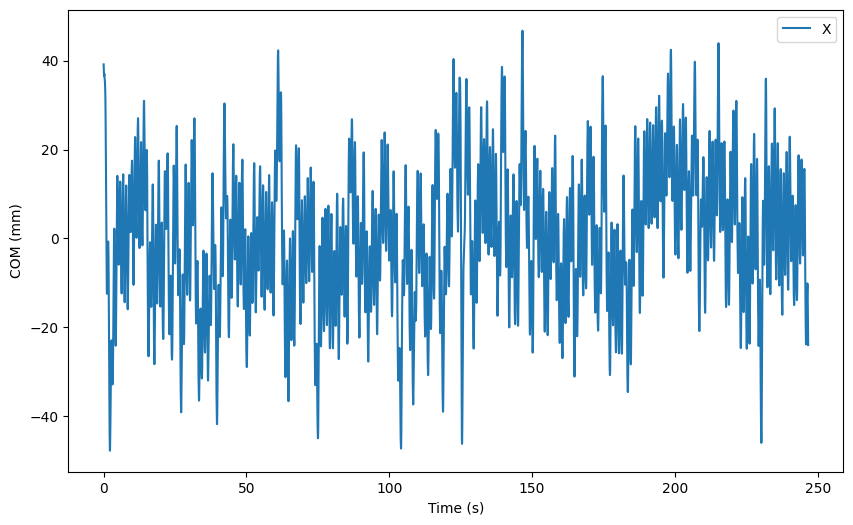

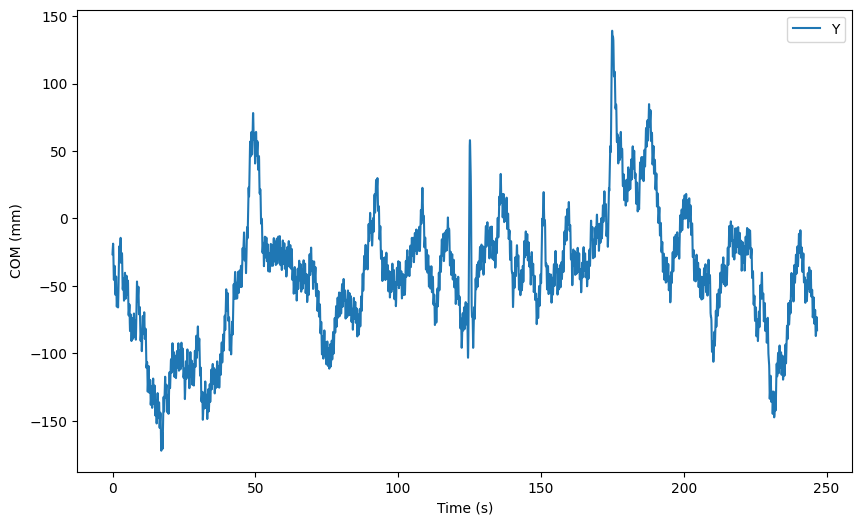

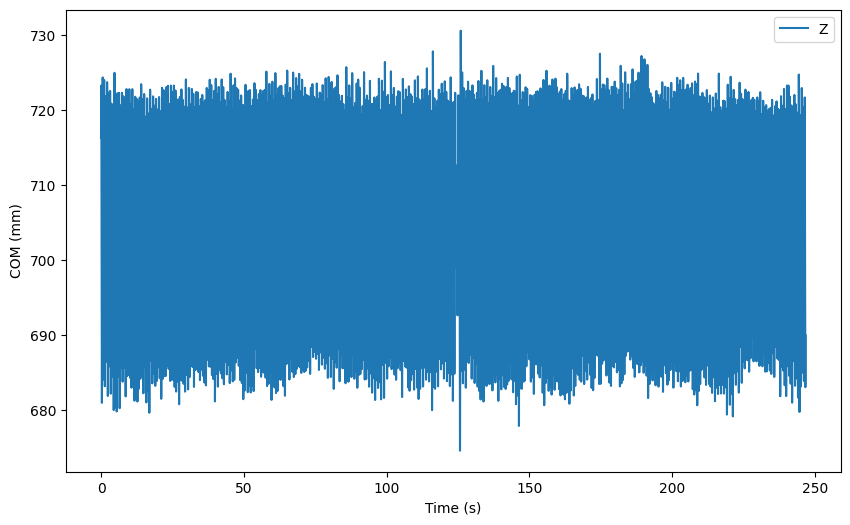

In [58]:
time = com_Y18.coords["time"].values      
x_Y18    = com_Y18.sel(axis="x").values       
y_Y18   = com_Y18.sel(axis="y").values
z_Y18    = com_Y18.sel(axis="z").values

fig = plt.figure(figsize=(10, 6))       
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x_Y18, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y_Y18, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z_Y18, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

pre perturbation

Time coordinates: 0.0 to 246.68
Selected COM shape: 50.81 119.52 (3, 6872)
Average stride duration: 1.041060606060606 ± 0.011694182428156851 s

--- Axis: x ---


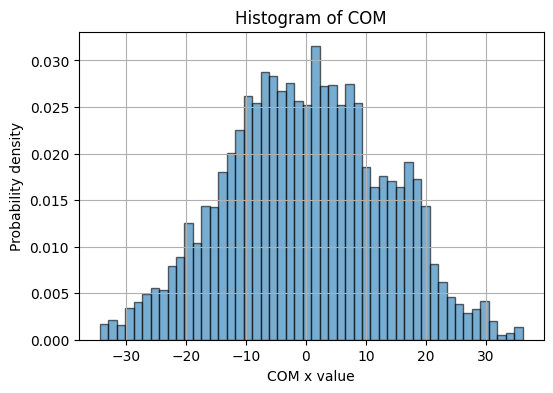

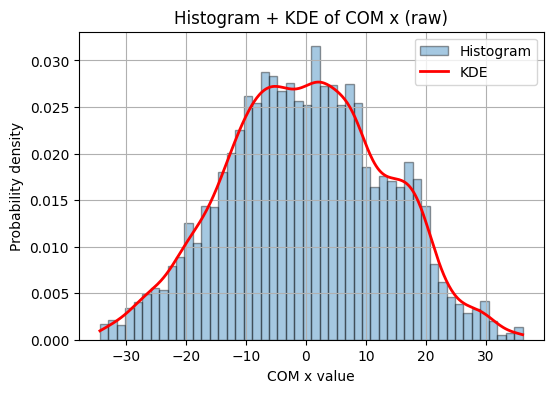

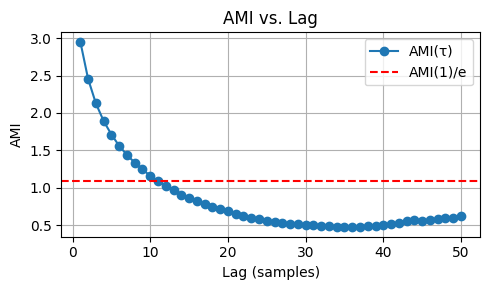

Optimal lag (τ) for axis x: 12 samples (0.120 s)


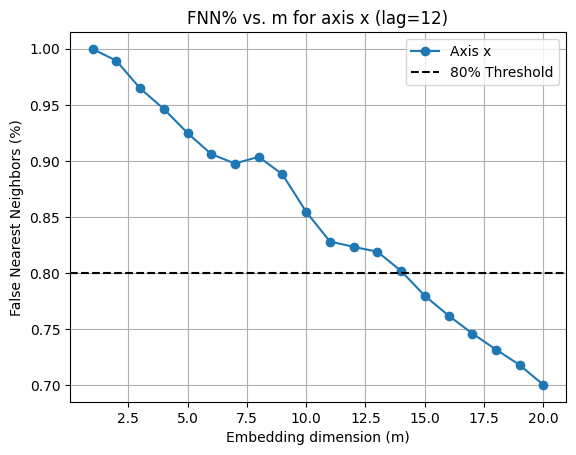

Optimal embedding dimension (m) for axis x: 11


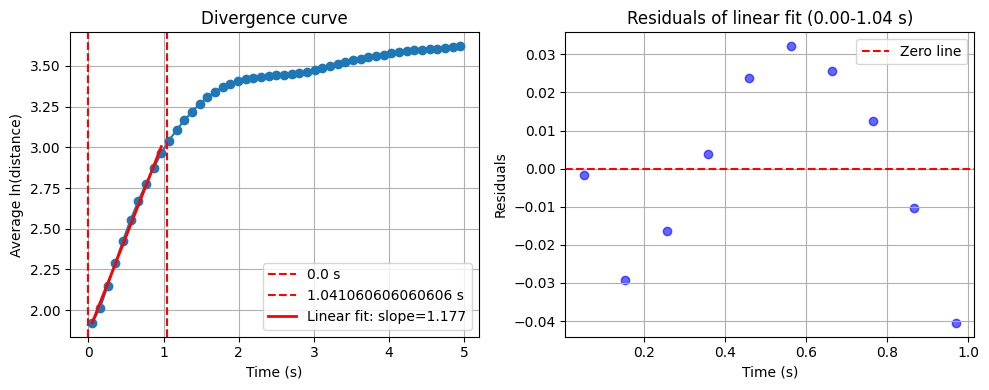

Lyapunov exponent (λ*) for axis x: 1.1768 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

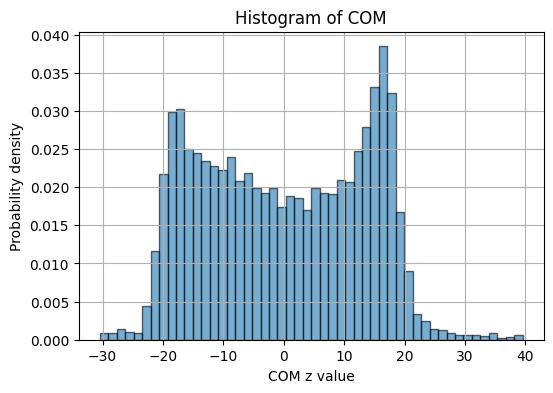

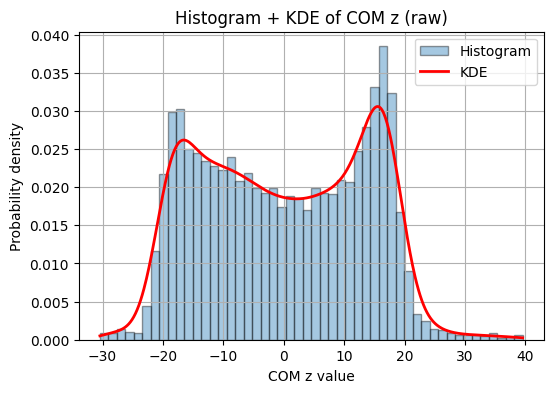

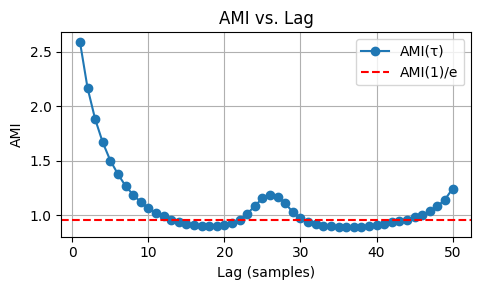

Optimal lag (τ) for axis z: 17 samples (0.170 s)


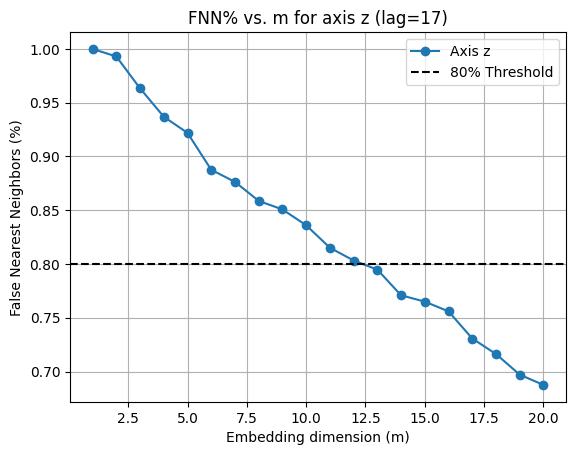

Optimal embedding dimension (m) for axis z: 6


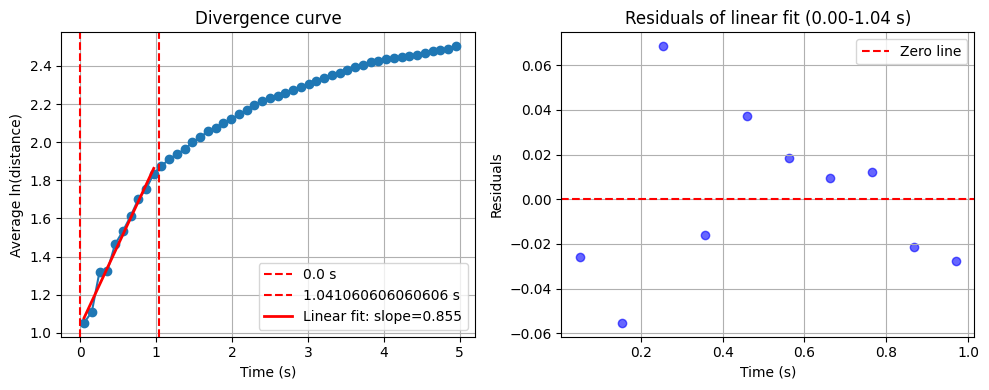

Lyapunov exponent (λ*) for axis z: 0.8547 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [95]:
ds_Y18 = xr.open_dataset(file_path_Y18)
da_Y18= ds_Y18["markers"] if "markers" in ds_Y18 else ds_Y18
com_Y18= da_Y18.sel(channel="COM")
time = com_Y18.coords["time"].values  
print("Time coordinates:", time[0], "to", time[-1])

fstrike_time_Y18 = get_foot_strike(events_path_Y18, foot='Right', start_time=50.0, end_time=120.0)
start_time_Y18 = fstrike_time_Y18['first_strike']
end_time_Y18   = fstrike_time_Y18['last_strike']
com_Y18 = com_Y18.sel(time=slice(start_time_Y18, end_time_Y18))  
print("Selected COM shape:", start_time_Y18, end_time_Y18, com_Y18.shape)

average_stride_Y18 = get_average_stride_duration(events_path_Y18, foot='Right', start_time=50.0, end_time=120.0)
print("Average stride duration:", average_stride_Y18['mean_duration'], "±", average_stride_Y18['std_duration'], "s")

max_lag_Y18    = 50        # Search AMI up to 50 samples (0.50 s)
bins            = 64
max_dim_Y18     = 20        # Search FNN% up to 20 dimensions
rtol            = 0.15
fnn_threshold   = 0.80
fs              = 100.0
max_time_Y18   = 10.0      # Max evolution time for divergence (s)

for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    ts_Y18 = com_Y18.sel(axis=axis).values.ravel()
    ts_Y18 = preprocess_signal(ts_Y18, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    # Histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y18, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

    # KDE overlay
    kde   = gaussian_kde(ts_Y18)
    xs_Y18 = np.linspace(ts_Y18.min(), ts_Y18.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y18, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y18, kde(xs_Y18), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Optimal lag via AMI
    lag_Y18 = optimal_lag(ts_Y18, max_lag=max_lag_Y18, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y18} samples ({lag_Y18/fs:.3f} s)")

    # False Nearest Neighbors
    dims_Y18, fnn_perc_Y18 = compute_fnn_percentage(ts_Y18, lag_Y18, max_dim=max_dim_Y18, rtol=rtol)
    plt.figure()
    plt.plot(dims_Y18, fnn_perc_Y18, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="80% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y18})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Determine embedding dimension
    dim_Y18 = optimal_embedding_dimension(ts_Y18, lag_Y18, max_dim=max_dim_Y18, rtol=rtol)
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y18}")

    # Lyapunov exponent
    lyap_Y18 = compute_lyapunov_exponent(
        ts_Y18,
        emb_dim=dim_Y18,
        lag=lag_Y18,
        fs=fs,
        max_time=5.0,
        fit_start=0.0,
        fit_end=average_stride_Y18['mean_duration'],
        plot_residuals=True
    )
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y18:.4f} 1/s")

    results_df.loc[len(results_df)] = {
        'subject': 'Cereneo_SR_18',
        'axis': axis,
        'average stride duration': average_stride_Y18['mean_duration'],
        'measuring time (s)': end_time_Y18 - start_time_Y18,
        'PBT': 'Before',
        'lag': lag_Y18,
        'embedding_dimension': dim_Y18,
        'fnn_threshold': fnn_threshold,
        'lyapunov_exponent': lyap_Y18
    }
    print(results_df)


post perturbation

Selected COM shape: 130.25 241.4 (3, 11116)
Average stride duration: 1.038785046728972 ± 0.010652565868242075 s

--- Axis: x ---


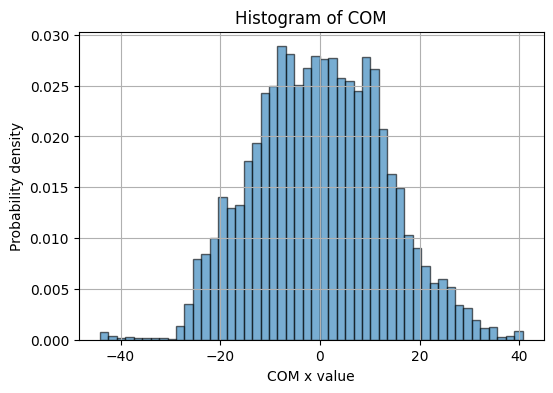

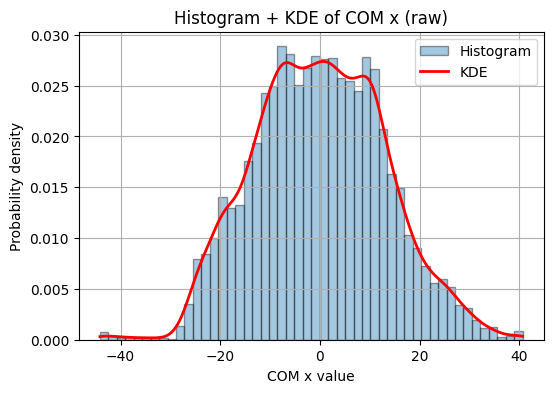

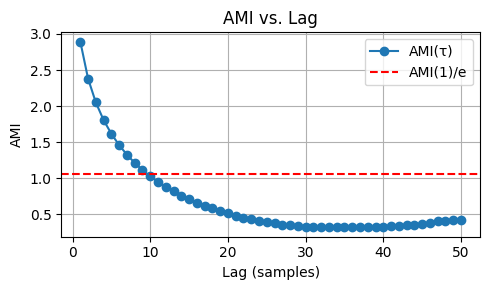

Optimal lag (τ) for axis x: 10 samples (0.100 s)


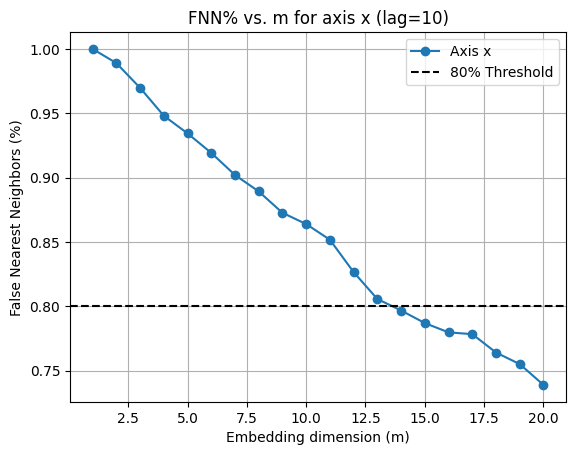

Optimal embedding dimension (m) for axis x: 11


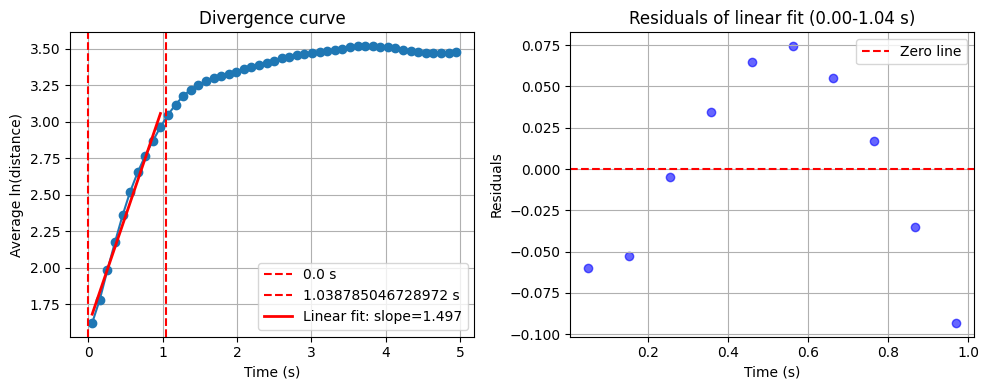

Lyapunov exponent (λ*) for axis x: 1.4973 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

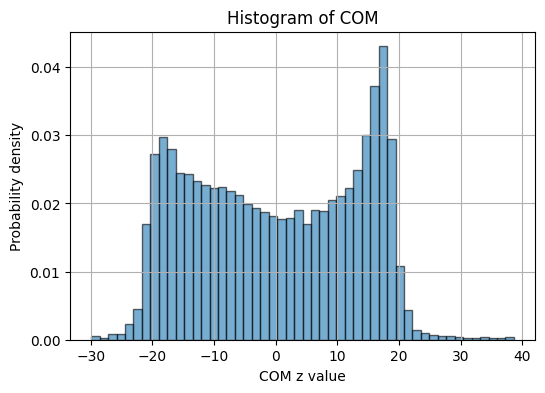

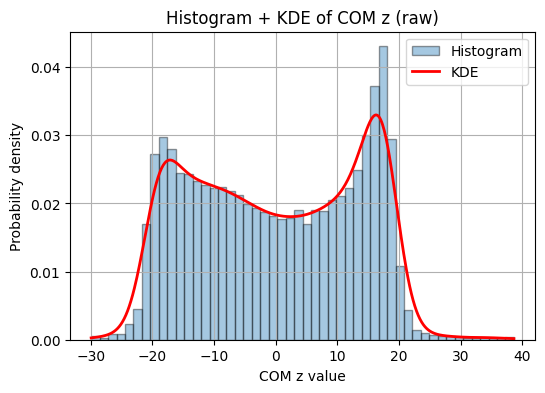

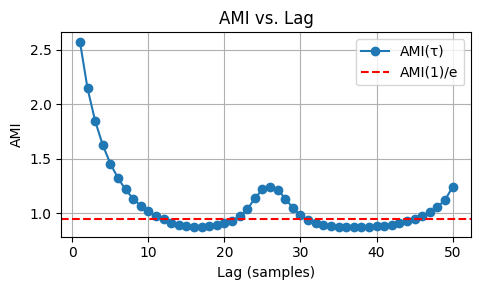

Optimal lag (τ) for axis z: 17 samples (0.170 s)


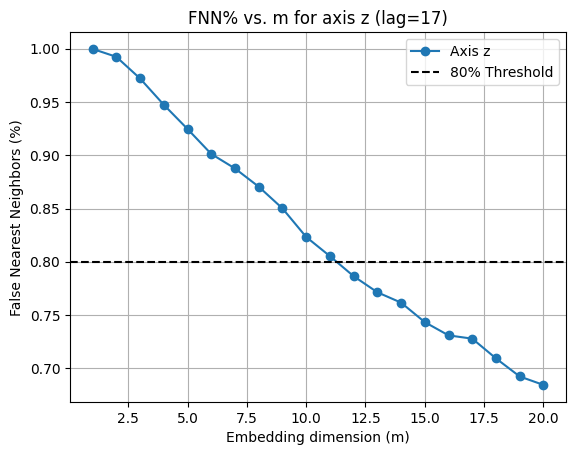

Optimal embedding dimension (m) for axis z: 17


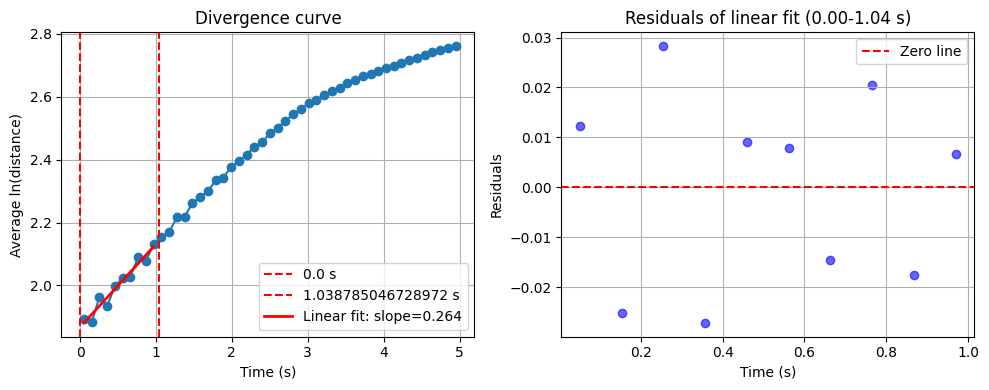

Lyapunov exponent (λ*) for axis z: 0.2640 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [96]:
ds_Y18P = xr.open_dataset(file_path_Y18)
da_Y18P = ds_Y18P["markers"] if "markers" in ds_Y18P else ds_Y18P
com_Y18P = da_Y18.sel(channel="COM")
time = com_Y18P.coords["time"].values  
da_Y18P = ds_Y18P["markers"] if "markers" in ds_Y18P else ds_Y18P 
fstrike_time_Y18P = get_foot_strike(events_path_Y18, foot='Right', start_time=130.0, end_time=time[-1]-5.0)
start_time_Y18P = fstrike_time_Y18P['first_strike']
end_time_Y18P = fstrike_time_Y18P['last_strike']
com_Y18P = com_Y18P.sel(time=slice(start_time_Y18P, end_time_Y18P))  
print("Selected COM shape:", start_time_Y18P, end_time_Y18P, com_Y18P.shape)
average_stride_Y18P = get_average_stride_duration(events_path_Y18, foot='Right', start_time=130.0, end_time=time[-1]-5.0)
print("Average stride duration:", average_stride_Y18P['mean_duration'], "±", average_stride_Y18P['std_duration'], "s")

max_lag_Y18 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y18 = 20        # Search FNN% up to 20 dimensions
rtol = 0.15
fnn_threshold = 0.80
fs = 100.0
max_time_Y18 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y18P = com_Y18P.sel(axis=axis).values.ravel()
    ts_Y18P = preprocess_signal(ts_Y18P, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y18P, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y18P)            
    xs_Y18P = np.linspace(ts_Y18P.min(), ts_Y18P.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y18P, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y18P, kde(xs_Y18P), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y18P = optimal_lag(ts_Y18P, max_lag=max_lag_Y18, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y18P} samples ({lag_Y18P/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y18P, fnn_perc_Y18P = compute_fnn_percentage(ts_Y18P, lag_Y18P, max_dim=max_dim_Y18, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y18P, fnn_perc_Y18P, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="80% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y18P})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y18P = optimal_embedding_dimension(
        ts_Y18P, lag_Y18P, max_dim=max_dim_Y18, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y18P}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y18P = compute_lyapunov_exponent(
        ts_Y18P, emb_dim=dim_Y18P, lag=lag_Y18P, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y18P['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y18P:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_18',
    'axis': axis,
    'average stride duration': average_stride_Y18P['mean_duration'],
    'measuring time (s)': end_time_Y18P - start_time_Y18P,
    'PBT': 'After',
    'lag': lag_Y18P,
    'embedding_dimension': dim_Y18P,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y18P}
    print (results_df)



## Young 19

In [97]:
file_path_Y19 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_19" /"Pre.3"/ "markers.nc"
events_path_Y19 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_19" /"Pre.4"/ "events.csv"
markers_Y19 = xr.open_dataarray(file_path_Y19)
com_Y19 = markers_Y19.sel(channel="COM")
# %matplotlib widget

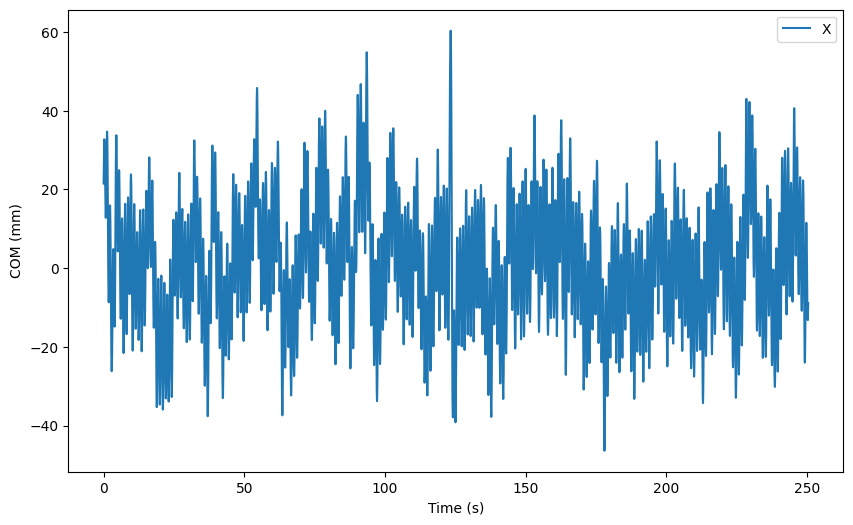

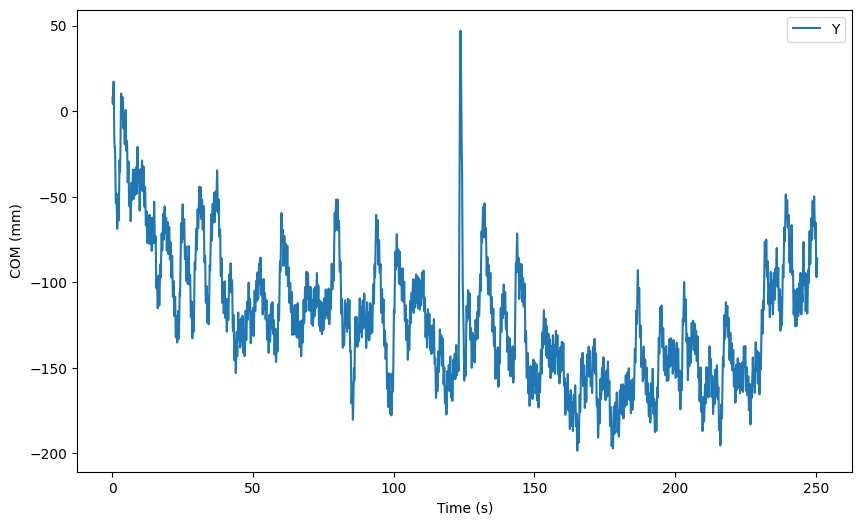

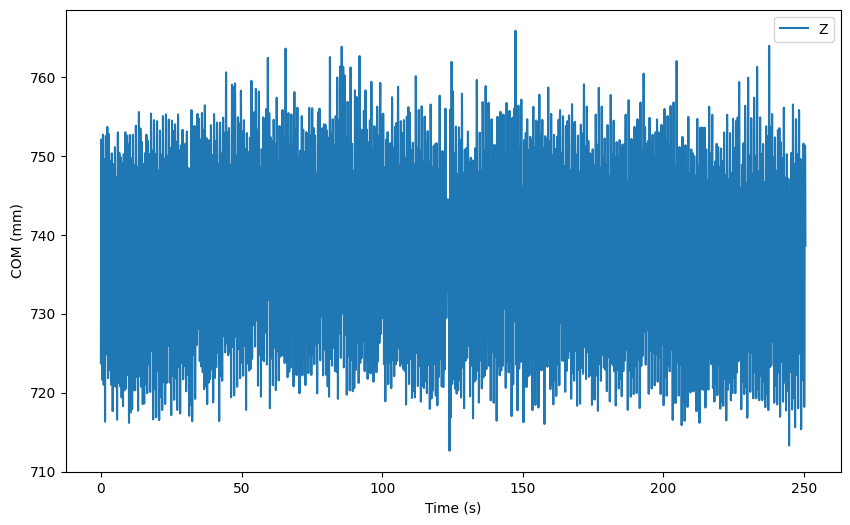

In [98]:
time = com_Y19.coords["time"].values      
x_Y19    = com_Y19.sel(axis="x").values       
y_Y19   = com_Y19.sel(axis="y").values
z_Y19    = com_Y19.sel(axis="z").values

fig = plt.figure(figsize=(10, 6))       
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x_Y19, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y_Y19, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z_Y19, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

Pre perturbation

Time coordinates: 0.01 to 250.46
Selected COM shape: 50.53 119.02 (3, 6849)
Average stride duration: 1.0536923076923077 ± 0.009210233567442924 s

--- Axis: x ---


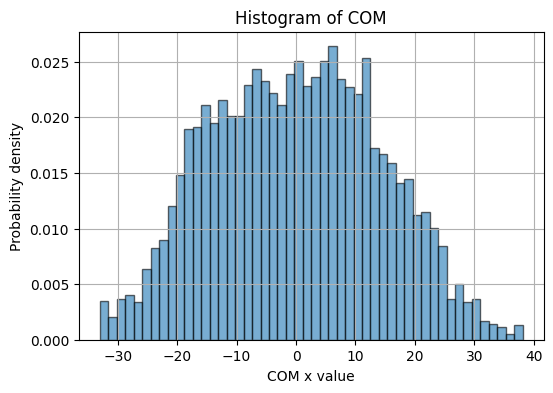

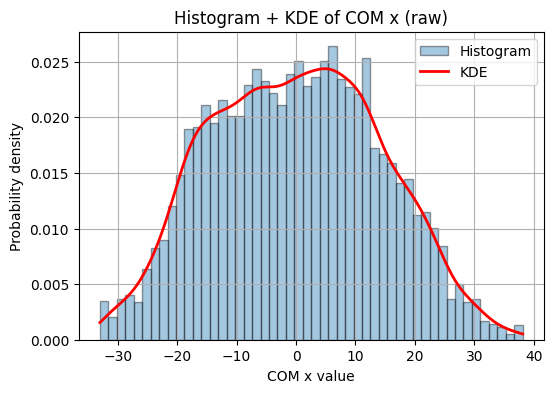

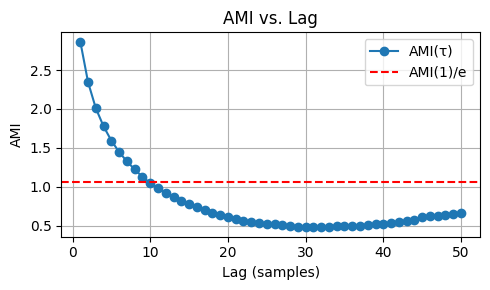

Optimal lag (τ) for axis x: 10 samples (0.100 s)


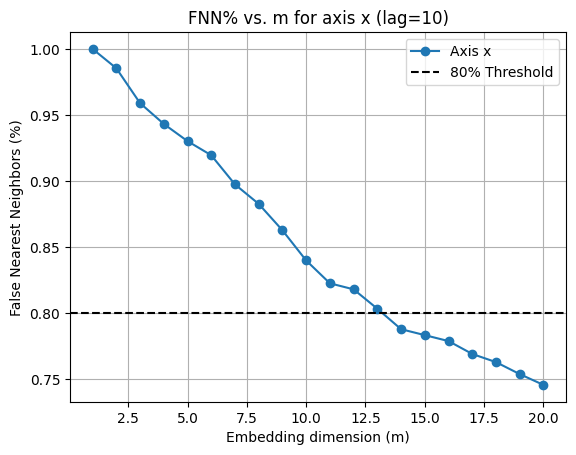

Optimal embedding dimension (m) for axis x: 11


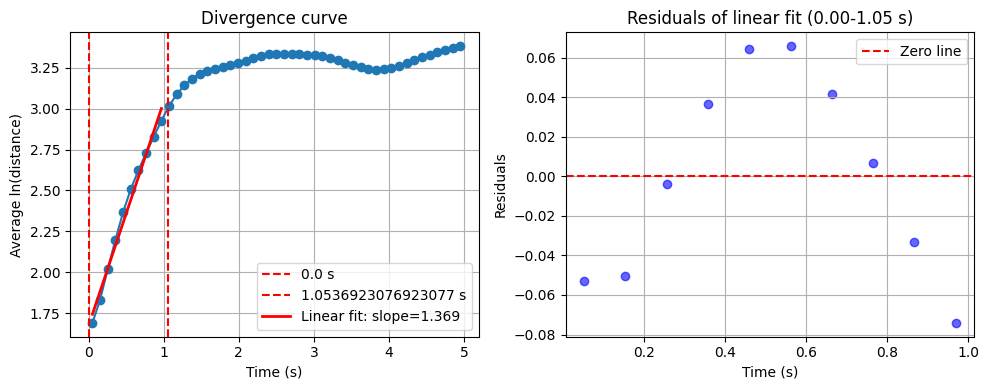

Lyapunov exponent (λ*) for axis x: 1.3690 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

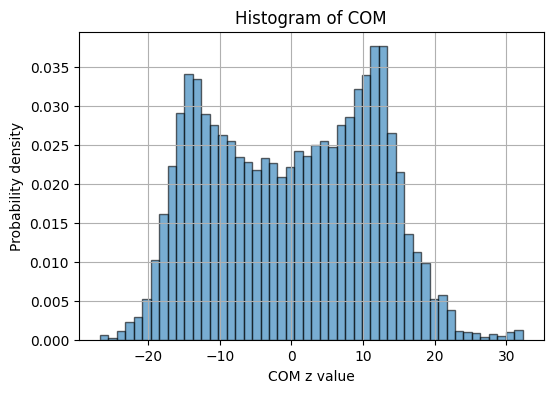

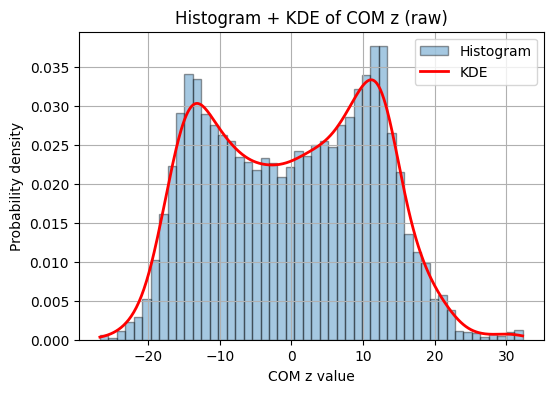

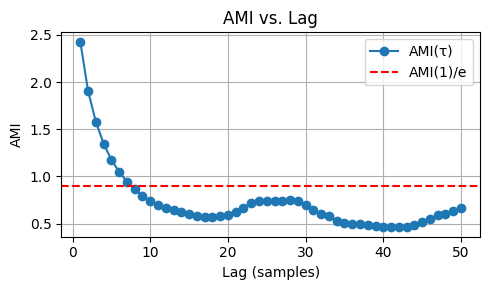

Optimal lag (τ) for axis z: 18 samples (0.180 s)


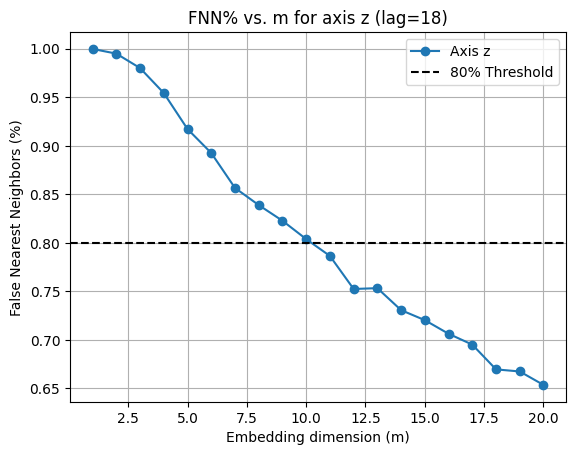

Optimal embedding dimension (m) for axis z: 12


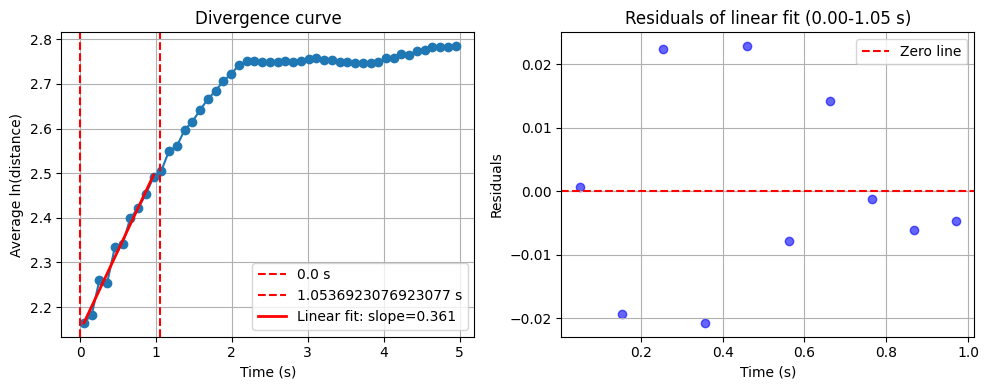

Lyapunov exponent (λ*) for axis z: 0.3612 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [102]:
ds_Y19 = xr.open_dataset(file_path_Y19)
da_Y19= ds_Y19["markers"] if "markers" in ds_Y19 else ds_Y19
com_Y19= da_Y19.sel(channel="COM")
time = com_Y19.coords["time"].values  
print("Time coordinates:", time[0], "to", time[-1])

fstrike_time_Y19 = get_foot_strike(events_path_Y19, foot='Right', start_time=50.0, end_time=120.0)
start_time_Y19 = fstrike_time_Y19['first_strike']
end_time_Y19   = fstrike_time_Y19['last_strike']
com_Y19 = com_Y19.sel(time=slice(start_time_Y19, end_time_Y19))  
print("Selected COM shape:", start_time_Y19, end_time_Y19, com_Y19.shape)

average_stride_Y19 = get_average_stride_duration(events_path_Y19, foot='Right', start_time=50.0, end_time=120.0)
print("Average stride duration:", average_stride_Y19['mean_duration'], "±", average_stride_Y19['std_duration'], "s")

max_lag_Y19    = 50        # Search AMI up to 50 samples (0.50 s)
bins            = 64
max_dim_Y19     = 20        # Search FNN% up to 20 dimensions
rtol            = 0.15
fnn_threshold   = 0.80
fs              = 100.0
max_time_Y19   = 10.0      # Max evolution time for divergence (s)

for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    ts_Y19 = com_Y19.sel(axis=axis).values.ravel()
    ts_Y19 = preprocess_signal(ts_Y19, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    # Histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y19, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

    # KDE overlay
    kde   = gaussian_kde(ts_Y19)
    xs_Y19 = np.linspace(ts_Y19.min(), ts_Y19.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y19, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y19, kde(xs_Y19), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Optimal lag via AMI
    lag_Y19 = optimal_lag(ts_Y19, max_lag=max_lag_Y19, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y19} samples ({lag_Y19/fs:.3f} s)")

    # False Nearest Neighbors
    dims_Y19, fnn_perc_Y19 = compute_fnn_percentage(ts_Y19, lag_Y19, max_dim=max_dim_Y19, rtol=rtol)
    plt.figure()
    plt.plot(dims_Y19, fnn_perc_Y19, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="80% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y19})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Determine embedding dimension
    dim_Y19 = optimal_embedding_dimension(ts_Y19, lag_Y19, max_dim=max_dim_Y19, rtol=rtol)
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y19}")

    # Lyapunov exponent
    lyap_Y19 = compute_lyapunov_exponent(
        ts_Y19,
        emb_dim=dim_Y19,
        lag=lag_Y19,
        fs=fs,
        max_time=5.0,
        fit_start=0.0,
        fit_end=average_stride_Y19['mean_duration'],
        plot_residuals=True
    )
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y19:.4f} 1/s")

    results_df.loc[len(results_df)] = {
        'subject': 'Cereneo_SR_19',
        'axis': axis,
        'average stride duration': average_stride_Y19['mean_duration'],
        'measuring time (s)': end_time_Y19- start_time_Y19,
        'PBT': 'Before',
        'lag': lag_Y19,
        'embedding_dimension': dim_Y19,
        'fnn_threshold': fnn_threshold,
        'lyapunov_exponent': lyap_Y19
    }
    print(results_df)


post perturbation

Selected COM shape: 130.14 244.6 (3, 11447)
Average stride duration: 1.059814814814815 ± 0.011302366310863302 s

--- Axis: x ---


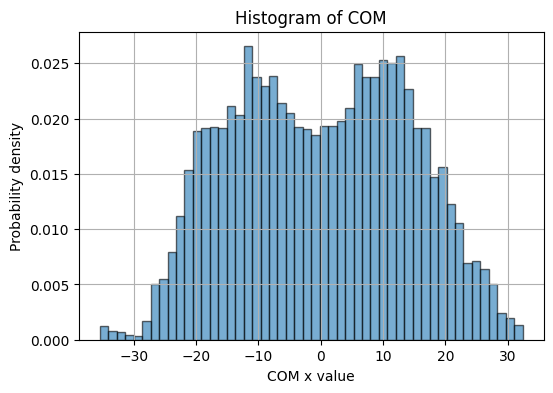

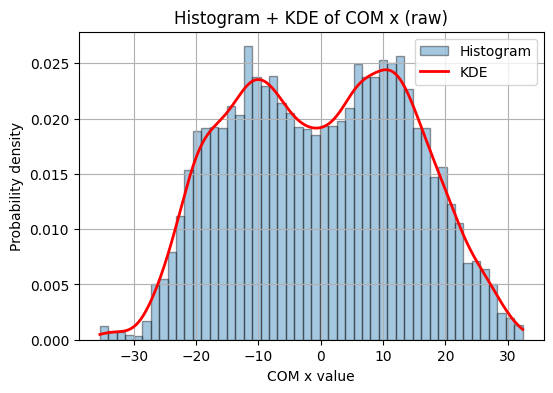

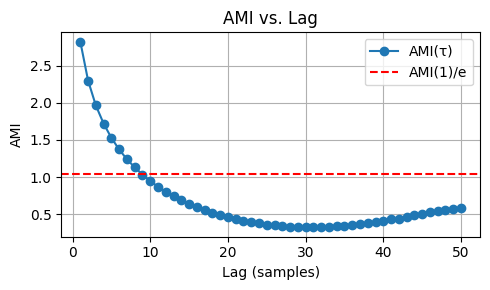

Optimal lag (τ) for axis x: 9 samples (0.090 s)


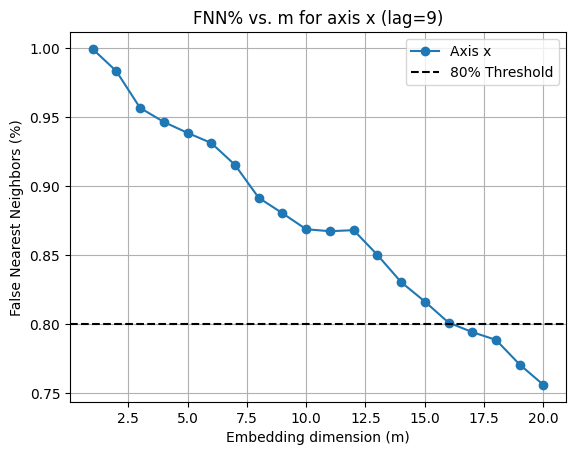

Optimal embedding dimension (m) for axis x: 12


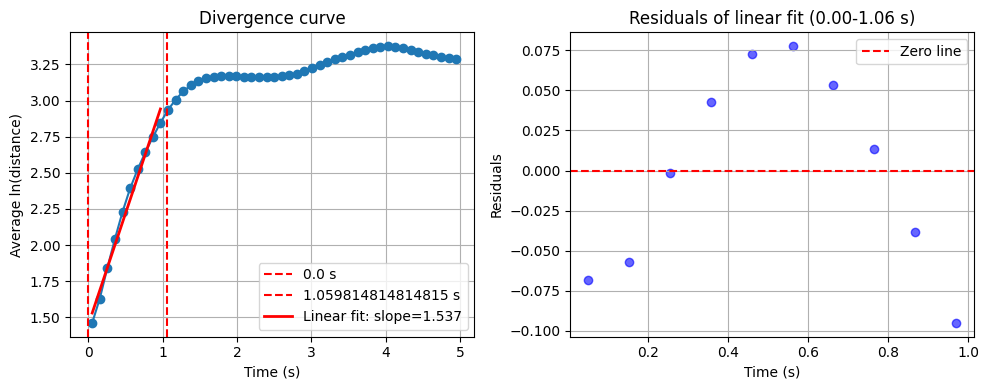

Lyapunov exponent (λ*) for axis x: 1.5374 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

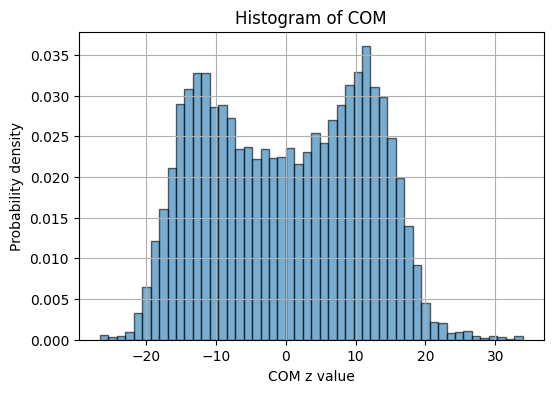

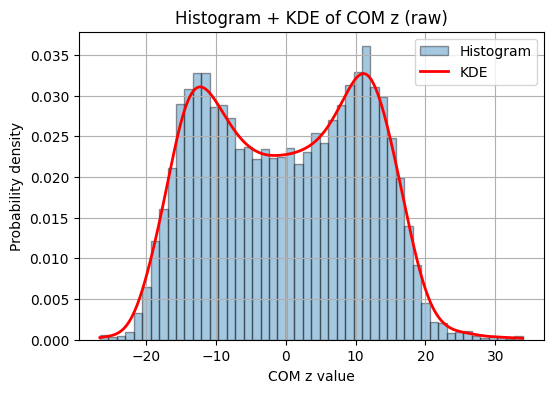

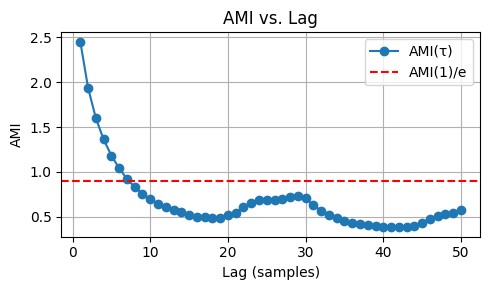

Optimal lag (τ) for axis z: 18 samples (0.180 s)


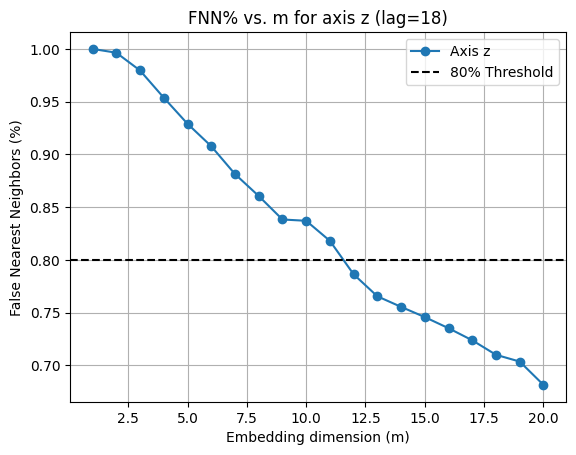

Optimal embedding dimension (m) for axis z: 9


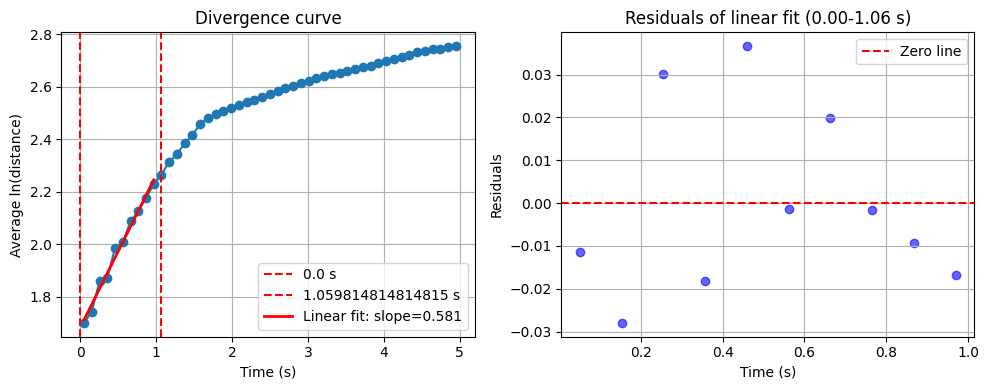

Lyapunov exponent (λ*) for axis z: 0.5807 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [103]:
ds_Y19P = xr.open_dataset(file_path_Y19)
da_Y19P = ds_Y19P["markers"] if "markers" in ds_Y19P else ds_Y19P
com_Y19P = da_Y19.sel(channel="COM")
time = com_Y19P.coords["time"].values  
da_Y19P = ds_Y19P["markers"] if "markers" in ds_Y19P else ds_Y19P 
fstrike_time_Y19P = get_foot_strike(events_path_Y19, foot='Right', start_time=130.0, end_time=time[-1]-5.0)
start_time_Y19P = fstrike_time_Y19P['first_strike']
end_time_Y19P = fstrike_time_Y19P['last_strike']
com_Y19P = com_Y19P.sel(time=slice(start_time_Y19P, end_time_Y19P))  
print("Selected COM shape:", start_time_Y19P, end_time_Y19P, com_Y19P.shape)
average_stride_Y19P = get_average_stride_duration(events_path_Y19, foot='Right', start_time=130.0, end_time=time[-1]-5.0)
print("Average stride duration:", average_stride_Y19P['mean_duration'], "±", average_stride_Y19P['std_duration'], "s")

max_lag_Y19 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y19 = 20        # Search FNN% up to 20 dimensions
rtol = 0.15
fnn_threshold = 0.80
fs = 100.0
max_time_Y19 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y19P = com_Y19P.sel(axis=axis).values.ravel()
    ts_Y19P = preprocess_signal(ts_Y19P, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y19P, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y19P)            
    xs_Y19P = np.linspace(ts_Y19P.min(), ts_Y19P.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y19P, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y19P, kde(xs_Y19P), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y19P = optimal_lag(ts_Y19P, max_lag=max_lag_Y19, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y19P} samples ({lag_Y19P/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y19P, fnn_perc_Y19P = compute_fnn_percentage(ts_Y19P, lag_Y19P, max_dim=max_dim_Y19, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y19P, fnn_perc_Y19P, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="80% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y19P})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y19P = optimal_embedding_dimension(
        ts_Y19P, lag_Y19P, max_dim=max_dim_Y19, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y19P}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y19P = compute_lyapunov_exponent(
        ts_Y19P, emb_dim=dim_Y19P, lag=lag_Y19P, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y19P['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y19P:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_19',
    'axis': axis,
    'average stride duration': average_stride_Y19P['mean_duration'],
    'measuring time (s)': end_time_Y19P - start_time_Y19P,
    'PBT': 'After',
    'lag': lag_Y19P,
    'embedding_dimension': dim_Y19P,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y19P}
    print (results_df)



## Young 20

In [104]:
file_path_Y20 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_20" /"Pre.3"/ "markers.nc"
events_path_Y20 = cwd.parent / "../data" / "PBT" / "Young" / "Cereneo_SR_20" /"Pre.4"/ "events.csv"
markers_Y20 = xr.open_dataarray(file_path_Y20)
com_Y20= markers_Y20.sel(channel="COM")
# %matplotlib widget

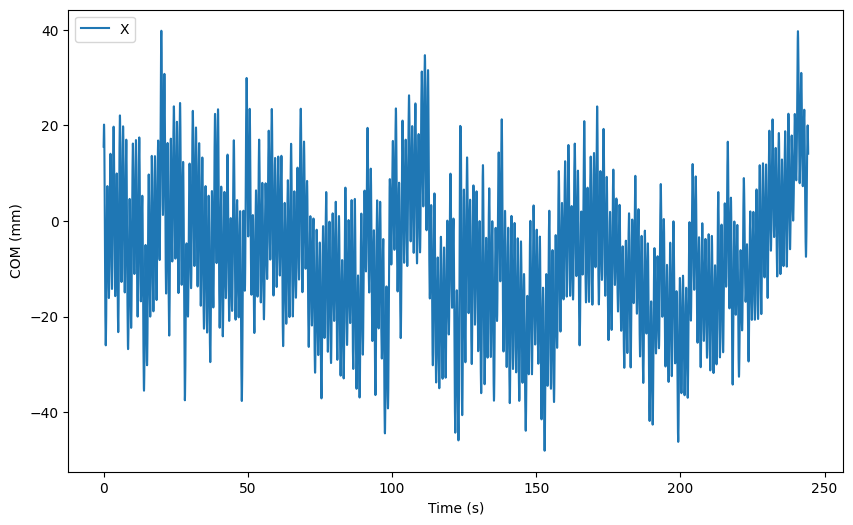

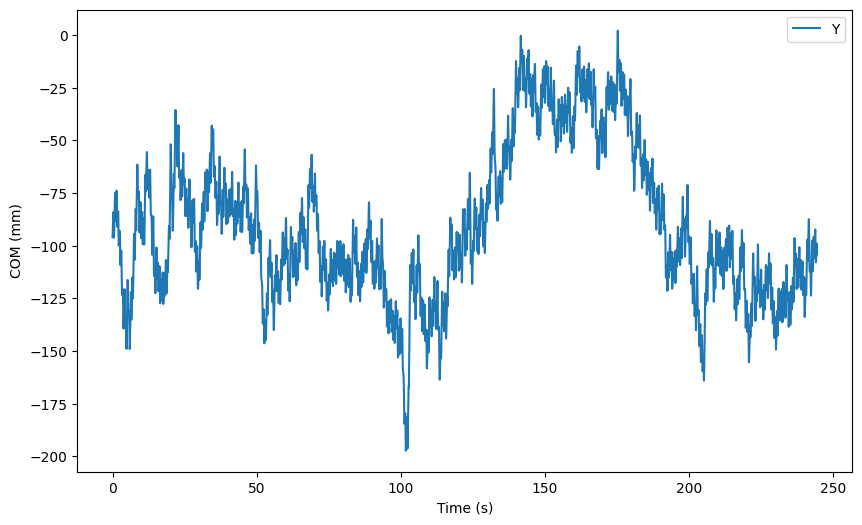

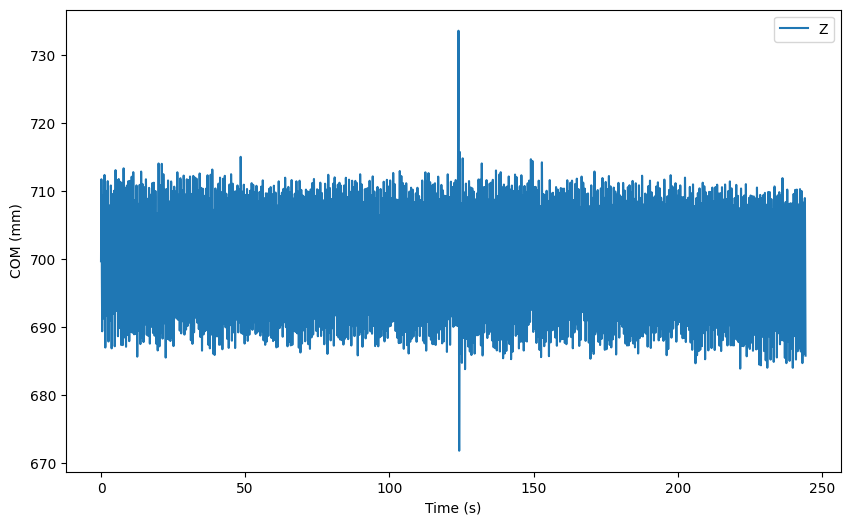

In [105]:
time = com_Y20.coords["time"].values      
x_Y20    = com_Y20.sel(axis="x").values       
y_Y20   = com_Y20.sel(axis="y").values
z_Y20    = com_Y20.sel(axis="z").values

fig = plt.figure(figsize=(10, 6))       
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x_Y20, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y_Y20, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z_Y20, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

pre

Time coordinates: 0.0 to 244.33
Selected COM shape: 20.18 99.36 (3, 7919)
Average stride duration: 1.0997222222222223 ± 0.015363396454472005 s

--- Axis: x ---


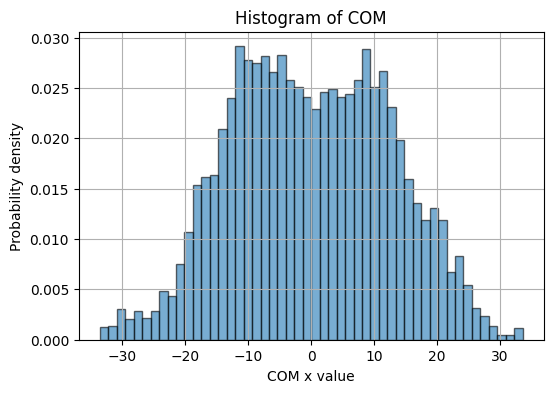

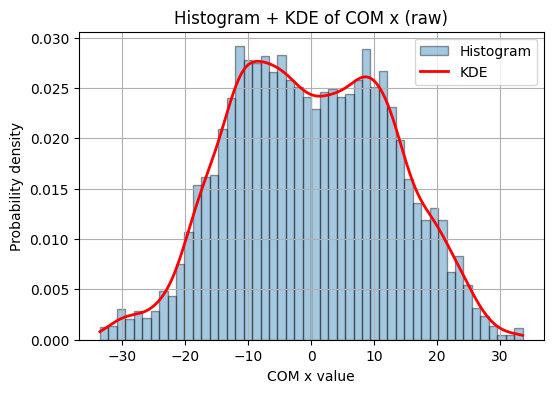

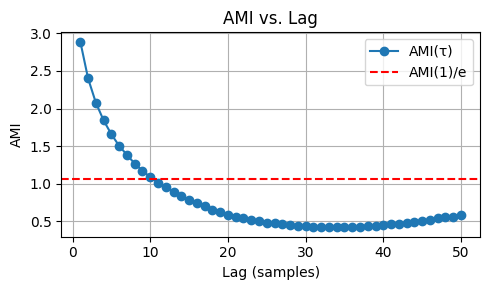

Optimal lag (τ) for axis x: 11 samples (0.110 s)


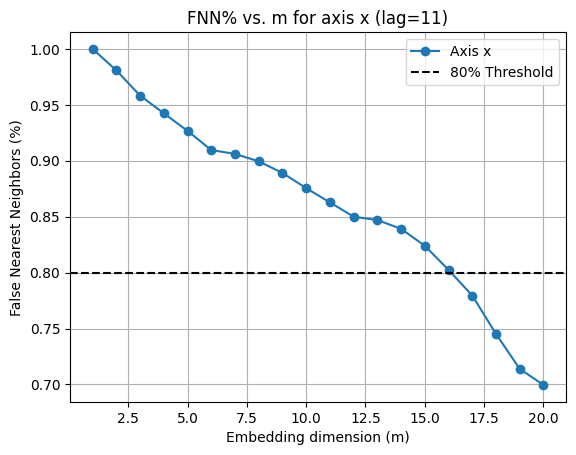

Optimal embedding dimension (m) for axis x: 19


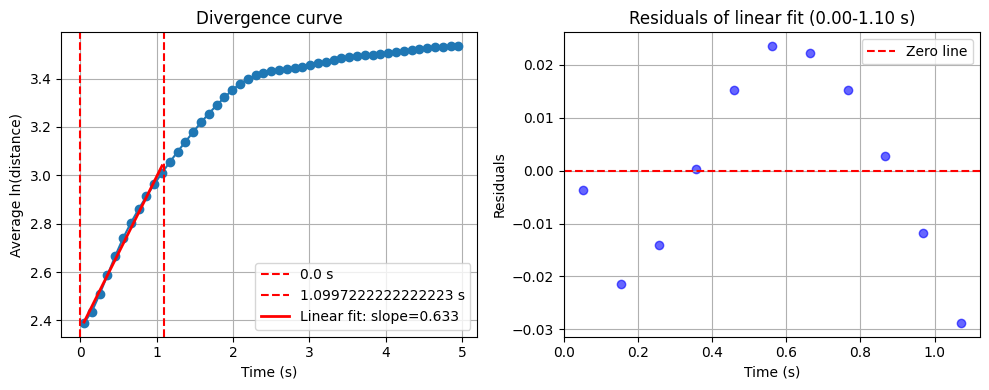

Lyapunov exponent (λ*) for axis x: 0.6332 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

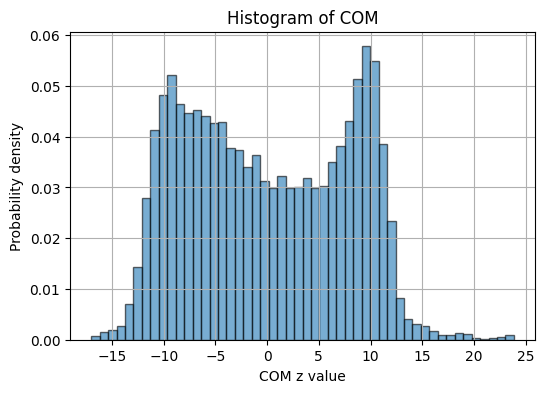

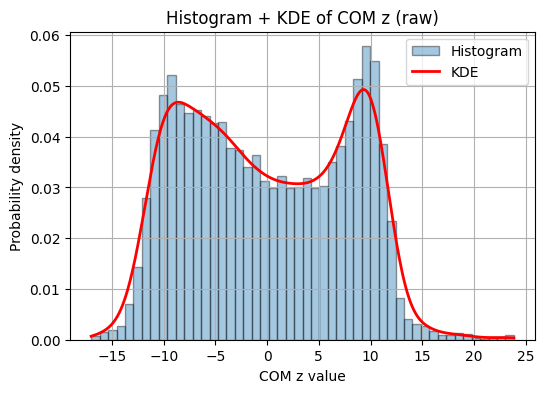

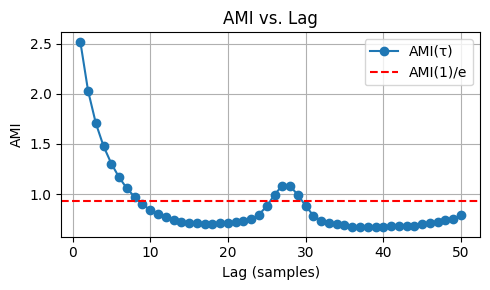

Optimal lag (τ) for axis z: 18 samples (0.180 s)


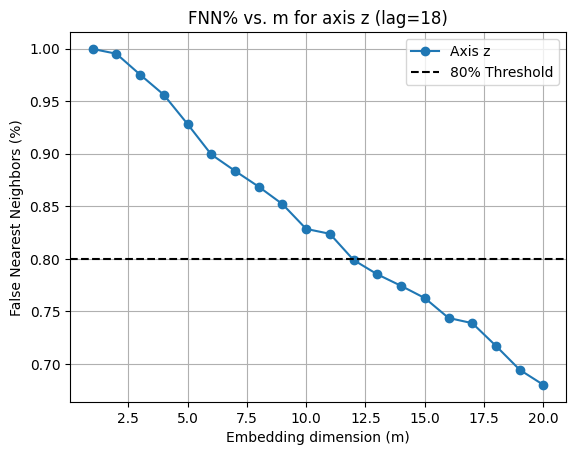

Optimal embedding dimension (m) for axis z: 11


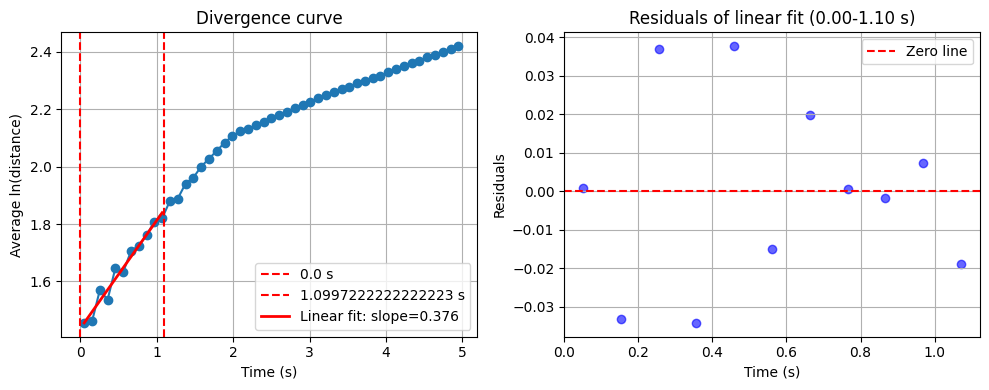

Lyapunov exponent (λ*) for axis z: 0.3764 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [106]:
ds_Y20 = xr.open_dataset(file_path_Y20)
da_Y20 = ds_Y20["markers"] if "markers" in ds_Y20 else ds_Y20
com_Y20= da_Y20.sel(channel="COM")
time = com_Y20.coords["time"].values  
print("Time coordinates:", time[0], "to", time[-1])

fstrike_time_Y20 = get_foot_strike(events_path_Y20, foot='Right', start_time=20.0, end_time=100.0)
start_time_Y20 = fstrike_time_Y20['first_strike']
end_time_Y20   = fstrike_time_Y20['last_strike']
com_Y20 = com_Y20.sel(time=slice(start_time_Y20, end_time_Y20))  
print("Selected COM shape:", start_time_Y20, end_time_Y20, com_Y20.shape)

average_stride_Y20 = get_average_stride_duration(events_path_Y20, foot='Right', start_time=20.0, end_time=100.0)
print("Average stride duration:", average_stride_Y20['mean_duration'], "±", average_stride_Y20['std_duration'], "s")

max_lag_Y20   = 50        # Search AMI up to 50 samples (0.50 s)
bins            = 64
max_dim_Y20     = 20        # Search FNN% up to 20 dimensions
rtol            = 0.15
fnn_threshold   = 0.80
fs              = 100.0
max_time_Y20   = 10.0      # Max evolution time for divergence (s)

for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    ts_Y20 = com_Y20.sel(axis=axis).values.ravel()
    ts_Y20 = preprocess_signal(ts_Y20, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    # Histogram
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y20, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

    # KDE overlay
    kde   = gaussian_kde(ts_Y20)
    xs_Y20 = np.linspace(ts_Y20.min(), ts_Y20.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y20, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y20, kde(xs_Y20), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Optimal lag via AMI
    lag_Y20 = optimal_lag(ts_Y20, max_lag=max_lag_Y20, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y20} samples ({lag_Y20/fs:.3f} s)")

    # False Nearest Neighbors
    dims_Y20, fnn_perc_Y20 = compute_fnn_percentage(ts_Y20, lag_Y20, max_dim=max_dim_Y20, rtol=rtol)
    plt.figure()
    plt.plot(dims_Y20, fnn_perc_Y20, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="80% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y20})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Determine embedding dimension
    dim_Y20 = optimal_embedding_dimension(ts_Y20, lag_Y20, max_dim=max_dim_Y20, rtol=rtol)
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y20}")

    # Lyapunov exponent
    lyap_Y20 = compute_lyapunov_exponent(
        ts_Y20,
        emb_dim=dim_Y20,
        lag=lag_Y20,
        fs=fs,
        max_time=5.0,
        fit_start=0.0,
        fit_end=average_stride_Y20['mean_duration'],
        plot_residuals=True
    )
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y20:.4f} 1/s")

    results_df.loc[len(results_df)] = {
        'subject': 'Cereneo_SR_20',
        'axis': axis,
        'average stride duration': average_stride_Y20['mean_duration'],
        'measuring time (s)': end_time_Y20- start_time_Y20,
        'PBT': 'Before',
        'lag': lag_Y20,
        'embedding_dimension': dim_Y20,
        'fnn_threshold': fnn_threshold,
        'lyapunov_exponent': lyap_Y20
    }
    print(results_df)


post

Selected COM shape: 130.59 238.74 (3, 10816)
Average stride duration: 1.1035714285714286 ± 0.01319013236615701 s

--- Axis: x ---


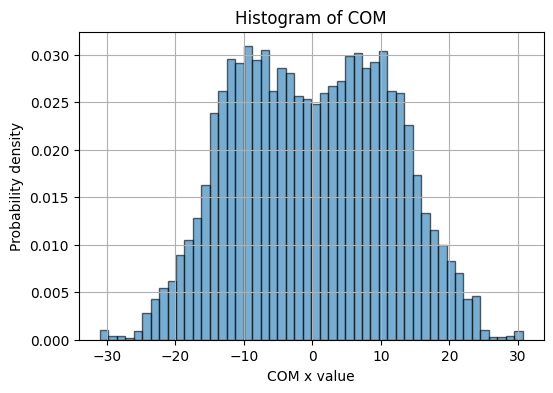

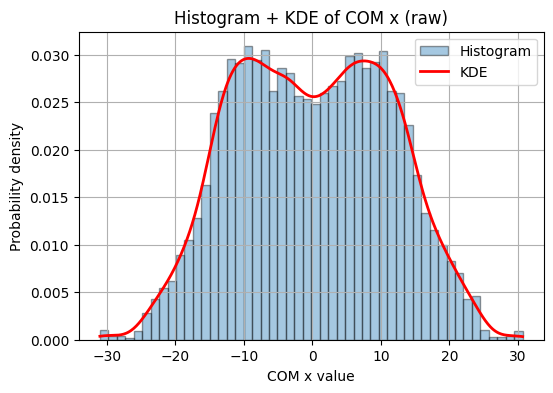

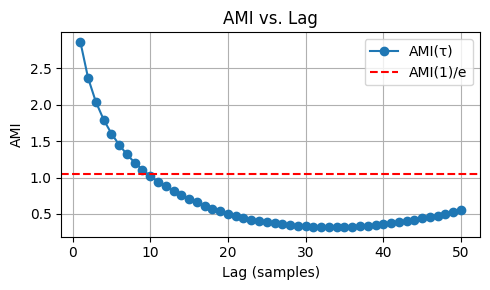

Optimal lag (τ) for axis x: 10 samples (0.100 s)


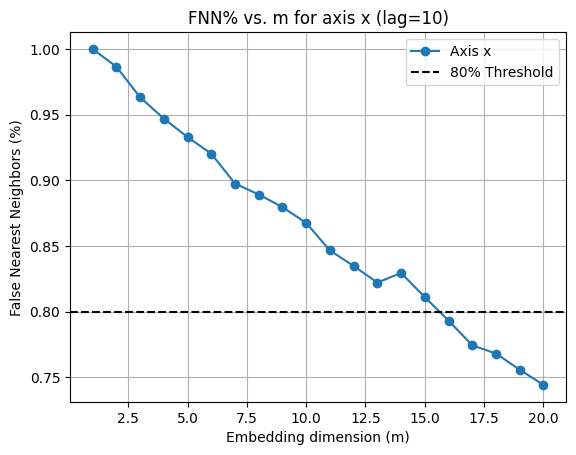

Optimal embedding dimension (m) for axis x: 14


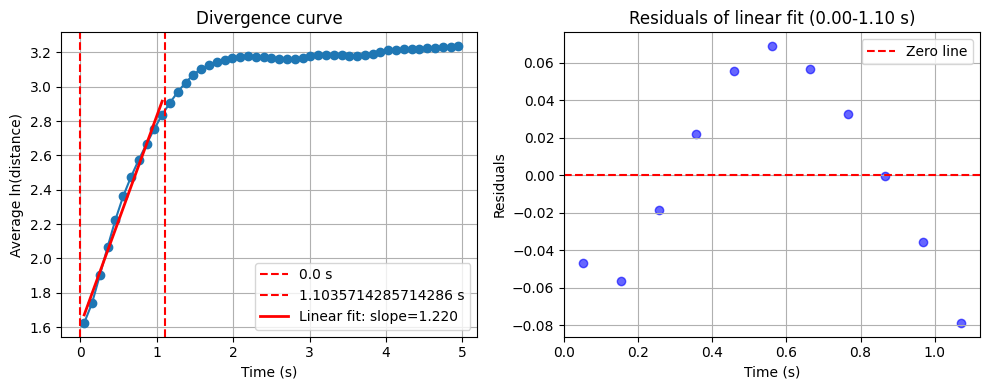

Lyapunov exponent (λ*) for axis x: 1.2199 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

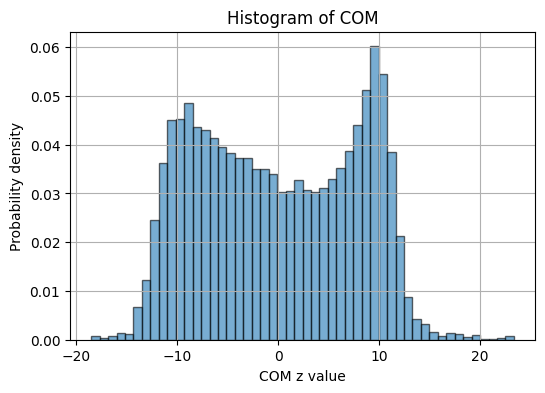

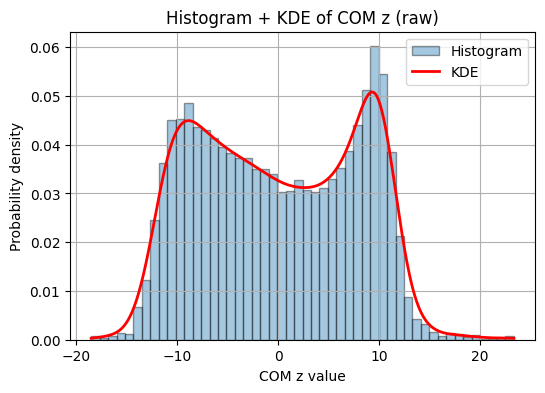

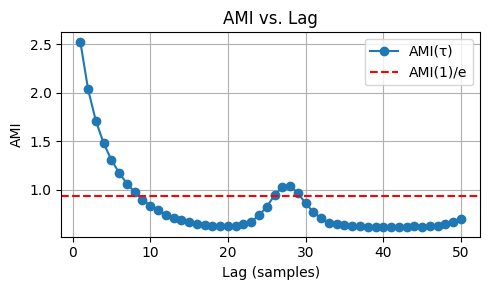

Optimal lag (τ) for axis z: 18 samples (0.180 s)


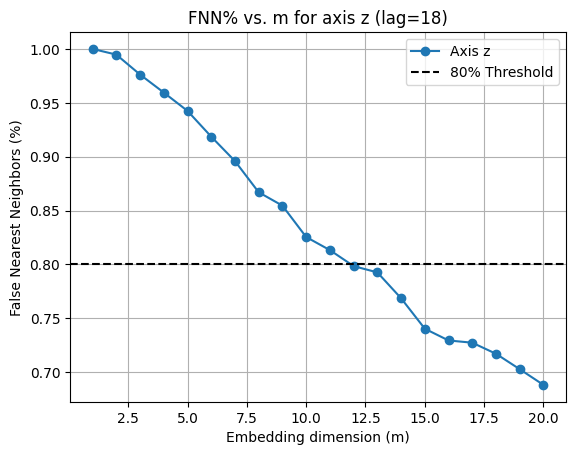

Optimal embedding dimension (m) for axis z: 13


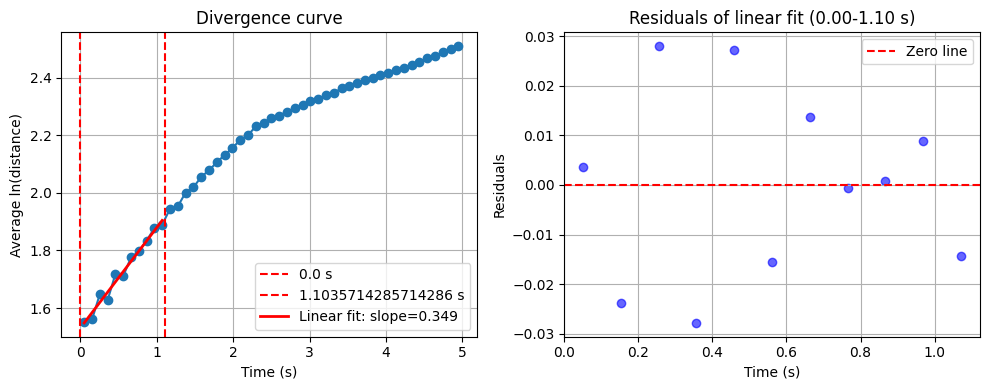

Lyapunov exponent (λ*) for axis z: 0.3485 1/s
          subject axis  average stride duration  measuring time (s)     PBT  \
0   Cereneo_SR_13    x                 1.551562               99.30  Before   
1   Cereneo_SR_13    z                 1.551562               99.30  Before   
2   Cereneo_SR_13    x                 1.520206              147.46   After   
3   Cereneo_SR_13    z                 1.520206              147.46   After   
4   Cereneo_SR_14    x                 1.230750               98.46  Before   
5   Cereneo_SR_14    z                 1.230750               98.46  Before   
6   Cereneo_SR_14    x                 1.217340              114.43   After   
7   Cereneo_SR_14    z                 1.217340              114.43   After   
8   Cereneo_SR_15    x                 1.094222               98.48  Before   
9   Cereneo_SR_15    z                 1.094222               98.48  Before   
10  Cereneo_SR_15    x                 1.096200              109.62   After   
11  Ce

In [107]:
ds_Y20P = xr.open_dataset(file_path_Y20)
da_Y20P = ds_Y20P["markers"] if "markers" in ds_Y20P else ds_Y20P
com_Y20P = da_Y20.sel(channel="COM")
time = com_Y20P.coords["time"].values  
da_Y20P = ds_Y20P["markers"] if "markers" in ds_Y20P else ds_Y20P 
fstrike_time_Y20P = get_foot_strike(events_path_Y20, foot='Right', start_time=130.0, end_time=time[-1]-5.0)
start_time_Y20P = fstrike_time_Y20P['first_strike']
end_time_Y20P = fstrike_time_Y20P['last_strike']
com_Y20P = com_Y20P.sel(time=slice(start_time_Y20P, end_time_Y20P))  
print("Selected COM shape:", start_time_Y20P, end_time_Y20P, com_Y20P.shape)
average_stride_Y20P = get_average_stride_duration(events_path_Y20, foot='Right', start_time=130.0, end_time=time[-1]-5.0)
print("Average stride duration:", average_stride_Y20P['mean_duration'], "±", average_stride_Y20P['std_duration'], "s")

max_lag_Y20 = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim_Y20 = 20        # Search FNN% up to 20 dimensions
rtol = 0.15
fnn_threshold = 0.80
fs = 100.0
max_time_Y20 = 10.0     # Max evolution time for divergence (s)

# ts_raw is your raw (detrended but unfiltered) COM_x array
# ts = com.sel(axis='x').values.ravel()
# ts = preprocess_signal(ts,fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Preprocess the signal
# for tau in [10, 20,40,50,100]:  # try a few small lags
#     x1 = ts_raw[:-tau]   # x(t)
#     x2 = ts_raw[tau:]    # x(t + tau)

#     plt.figure(figsize=(5,5))
#     plt.scatter(x1, x2, s=2, alpha=0.3)
#     plt.xlabel(f'x(t)')
#     plt.ylabel(f'x(t+{tau})')
#     plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
#     plt.grid(True)
#     plt.show()


for axis in ["x", "z"]:
    print(f"\n--- Axis: {axis} ---")
    # ts_x_Y13= com_Y13.sel(axis='x').values.ravel()
    # ts_x_Y13=preprocess_signal(ts_x_Y13, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)  # Detrend + bandpass + z-score
    ts_Y20P = com_Y20P.sel(axis=axis).values.ravel()
    ts_Y20P = preprocess_signal(ts_Y20P, fs, poly_order=1, hp_cutoff=0.1, lp_cutoff=30.0)

    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y20P, bins=50, density=True, edgecolor='k', alpha=0.6)
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title('Histogram of COM')
    plt.grid(True)
    plt.show()

  

    kde = gaussian_kde(ts_Y20P)            
    xs_Y20P = np.linspace(ts_Y20P.min(), ts_Y20P.max(), 500)
    plt.figure(figsize=(6, 4))
    plt.hist(ts_Y20P, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
    plt.plot(xs_Y20P, kde(xs_Y20P), 'r-', lw=2, label='KDE')
    plt.xlabel(f'COM {axis} value')
    plt.ylabel('Probability density')
    plt.title(f'Histogram + KDE of COM {axis} (raw)')
    plt.legend()
    plt.grid(True)
    plt.show()


    # 2) Find axis-specific optimal lag via AMI
    lag_Y20P = optimal_lag(ts_Y20P, max_lag=max_lag_Y20, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Y20P} samples ({lag_Y20P/fs:.3f} s)")

    # 3) Compute FNN% up to max_dim
    dims_Y20P, fnn_perc_Y20P = compute_fnn_percentage(ts_Y20P, lag_Y20P, max_dim=max_dim_Y20, rtol=rtol)

    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Y20P, fnn_perc_Y20P, "-o", label=f"Axis {axis}")
    plt.axhline(fnn_threshold, linestyle="--", color="k", label="80% Threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Y20P})")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 5) Find axis-specific embedding dimension
    dim_Y20P = optimal_embedding_dimension(
        ts_Y20P, lag_Y20P, max_dim=max_dim_Y20, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Y20P}")

    # 6) Compute Lyapunov exponent for this axis
    lyap_Y20P = compute_lyapunov_exponent(
        ts_Y20P, emb_dim=dim_Y20P, lag=lag_Y20P, fs=fs,
        max_time=5.0, fit_start=0.0, fit_end=average_stride_Y20P['mean_duration'], plot_residuals=True)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Y20P:.4f} 1/s")

    results_df.loc[len(results_df)] = {
    'subject': 'Cereneo_SR_20',
    'axis': axis,
    'average stride duration': average_stride_Y20P['mean_duration'],
    'measuring time (s)': end_time_Y20P - start_time_Y20P,
    'PBT': 'After',
    'lag': lag_Y20P,
    'embedding_dimension': dim_Y20P,
    'fnn_threshold': fnn_threshold,
    'lyapunov_exponent': lyap_Y20P}
    print (results_df)



In [ ]:
results_df.to_excel(cwd.parent/".." / "results"/ "PBT_Young_results.xlsx", index=False)